<a id='s1'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>📦 1 | Libraries & Setup</h2>

In [ ]:
!pip install xgboost lightgbm openpyxl shap --quiet
print('✅ Dependencies installed')

In [1]:
import pandas as pd
import numpy as np
import os, time, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from scipy import signal as sp_signal
from scipy.stats import kurtosis
from scipy.fft import fft, fftfreq

# ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef, roc_curve,
    classification_report
)

sns.set(style='whitegrid', font_scale=1.1)
np.random.seed(42)

def show_df(df, title='', n=5):
    print(f'\n{"═"*65}')
    if title: print(f'  {title}')
    print(f'  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'{"═"*65}')
    display(df.head(n).style
        .set_properties(**{'font-size':'11px','text-align':'center'})
        .set_table_styles([
            {'selector':'thead th',
             'props':[('background','#0f3460'),('color','white'),
                      ('font-weight','bold'),('text-align','center')]},
            {'selector':'tr:nth-child(even)',
             'props':[('background','#E8F0FE')]},
        ]).format(precision=4))

print('✅ All imports successful')

✅ All imports successful


<a id='s2'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>📂 2 | Load & Explore Dataset</h2>

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>2.1 Load File</h3>

In [5]:

FILE_PATH = r'bearing_fault_merge.csv'
FS_HZ     = 10000   # 10 kHz sampling rate

print(f'Loading: {FILE_PATH}')
t0  = time.time()
df_raw = pd.read_csv(FILE_PATH)
print(f'  Loaded in {time.time()-t0:.1f}s')
print(f'  Shape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Columns : {list(df_raw.columns)}')
show_df(df_raw, 'Raw Dataset Preview')

Loading: bearing_fault_merge.csv
  Loaded in 30.8s
  Shape   : 4,797,788 rows × 7 columns
  Columns : ['Time Stamp', ' Current-A', ' Current-B', ' Current-C', 'Size', 'Load', 'Label']

═════════════════════════════════════════════════════════════════
  Raw Dataset Preview
  Shape: 4,797,788 rows × 7 columns
═════════════════════════════════════════════════════════════════


,Time Stamp,Current-A,Current-B,Current-C,Size,Load,Label
0,13:34:14,2.3309,1.9878,3.0818,0.7000,100,inner
1,13:34:14,2.3309,1.9878,3.0818,0.7000,100,inner
2,13:34:14,2.3309,1.9878,3.0818,0.7000,100,inner
3,13:34:14,2.3309,1.9878,3.0818,0.7000,100,inner
4,13:34:14,2.3309,1.9878,3.0818,0.7000,100,inner


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>2.2 Dataset Structure Analysis</h3>

══ DATASET STRUCTURE ═══════════════════════════════════
  Total rows       : 4,797,788
  Fault sizes (mm) : [np.float64(0.7), np.float64(0.9), np.float64(1.1), np.float64(1.3), np.float64(1.5), np.float64(1.7)]
  Load conditions  : [np.int64(100), np.int64(200), np.int64(300)] W
  Labels           : ['inner', 'outer']

Per-class distribution:
Label
inner    2444875
outer    2352913

Per Size+Load combination:
Label  Size  Load   Rows
inner   0.7   100 143348
inner   0.7   200 125366
inner   0.7   300 113520
inner   0.9   100 152416
inner   0.9   200 137227
inner   0.9   300 132423
inner   1.1   100 136051
inner   1.1   200 137299
inner   1.1   300 147041
inner   1.3   100 143273
inner   1.3   200 133175
inner   1.3   300 127832
inner   1.5   100 131178
inner   1.5   200 145826
inner   1.5   300 133989
inner   1.7   100 138227
inner   1.7   200 137796
inner   1.7   300 128888
outer   0.7   100 130115
outer   0.7   200 130144
outer   0.7   300  66009
outer   0.9   100 140560
outer   0.9

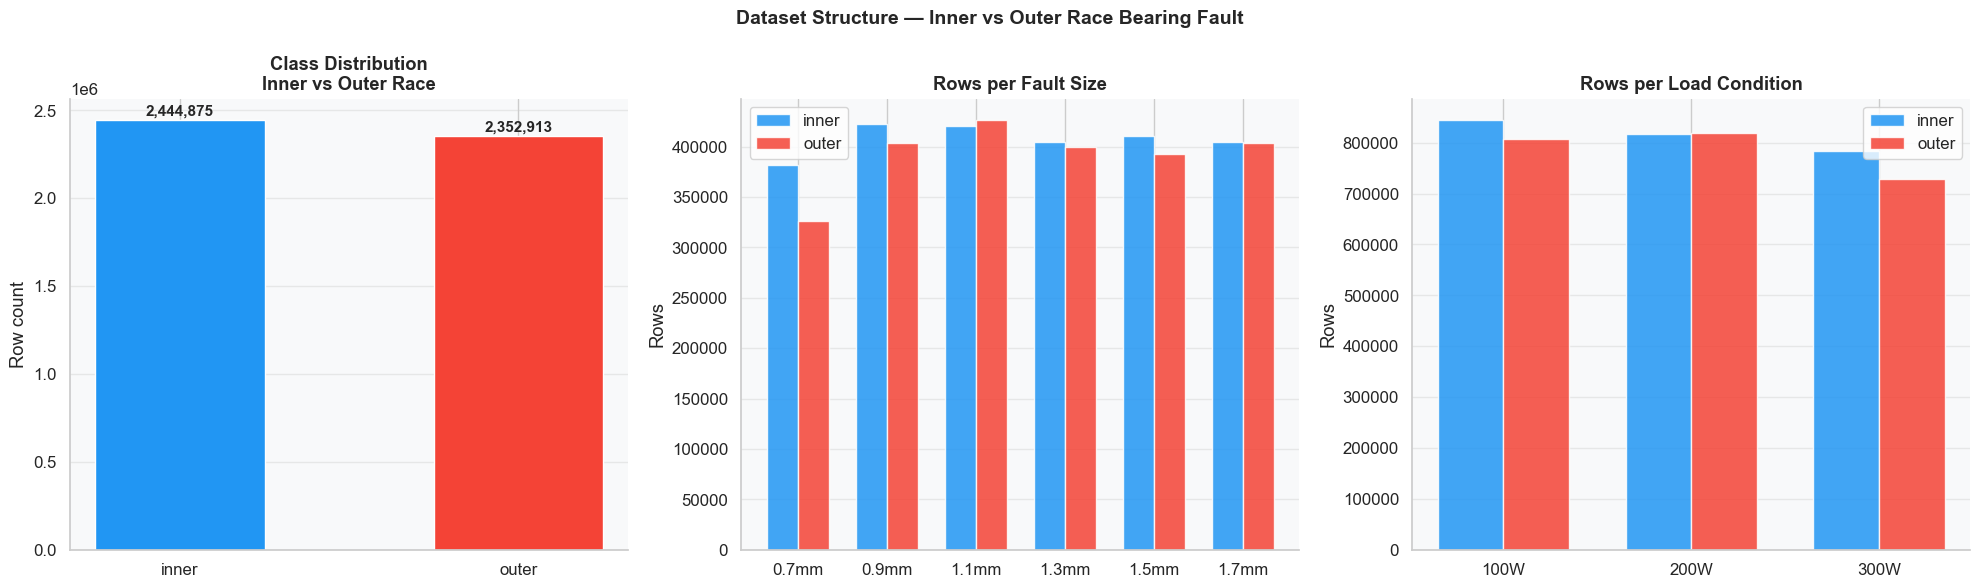

✅ Saved: 00_dataset_structure.png


In [6]:
print('══ DATASET STRUCTURE ═══════════════════════════════════')
print(f'  Total rows       : {df_raw.shape[0]:,}')
print(f'  Fault sizes (mm) : {sorted(df_raw["Size"].unique())}')
print(f'  Load conditions  : {sorted(df_raw["Load"].unique())} W')
print(f'  Labels           : {list(df_raw["Label"].unique())}')
print()
print('Per-class distribution:')
print(df_raw['Label'].value_counts().to_string())
print()
print('Per Size+Load combination:')
combo = df_raw.groupby(['Label','Size','Load']).size().reset_index(name='Rows')
print(combo.to_string(index=False))

# Visualise dataset structure
CPLT = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#009688']
SIZES = sorted(df_raw['Size'].unique())
LOADS = sorted(df_raw['Load'].unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')

# Class distribution
ax = axes[0]; ax.set_facecolor('#f8f9fa')
cnt  = df_raw['Label'].value_counts()
bars = ax.bar(cnt.index, cnt.values,
              color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+cnt.max()*0.01,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Class Distribution\nInner vs Outer Race', fontweight='bold')
ax.set_ylabel('Row count'); ax.grid(True, axis='y', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Rows per size
ax = axes[1]; ax.set_facecolor('#f8f9fa')
for li, label in enumerate(['inner','outer']):
    vals = [df_raw[(df_raw['Label']==label)&(df_raw['Size']==s)].shape[0]
            for s in SIZES]
    x = np.arange(len(SIZES))
    ax.bar(x + li*0.35, vals, 0.35,
           label=label, color=CPLT[li], edgecolor='white', alpha=0.85)
ax.set_xticks(np.arange(len(SIZES))+0.175)
ax.set_xticklabels([f'{s}mm' for s in SIZES])
ax.set_title('Rows per Fault Size', fontweight='bold')
ax.set_ylabel('Rows'); ax.legend(); ax.grid(True, axis='y', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Rows per load
ax = axes[2]; ax.set_facecolor('#f8f9fa')
for li, label in enumerate(['inner','outer']):
    vals = [df_raw[(df_raw['Label']==label)&(df_raw['Load']==l)].shape[0]
            for l in LOADS]
    x = np.arange(len(LOADS))
    ax.bar(x + li*0.35, vals, 0.35,
           label=label, color=CPLT[li], edgecolor='white', alpha=0.85)
ax.set_xticks(np.arange(len(LOADS))+0.175)
ax.set_xticklabels([f'{l}W' for l in LOADS])
ax.set_title('Rows per Load Condition', fontweight='bold')
ax.set_ylabel('Rows'); ax.legend(); ax.grid(True, axis='y', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Dataset Structure — Inner vs Outer Race Bearing Fault',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('00_dataset_structure.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 00_dataset_structure.png')

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>2.3 Signal Visualisation per Fault Type</h3>

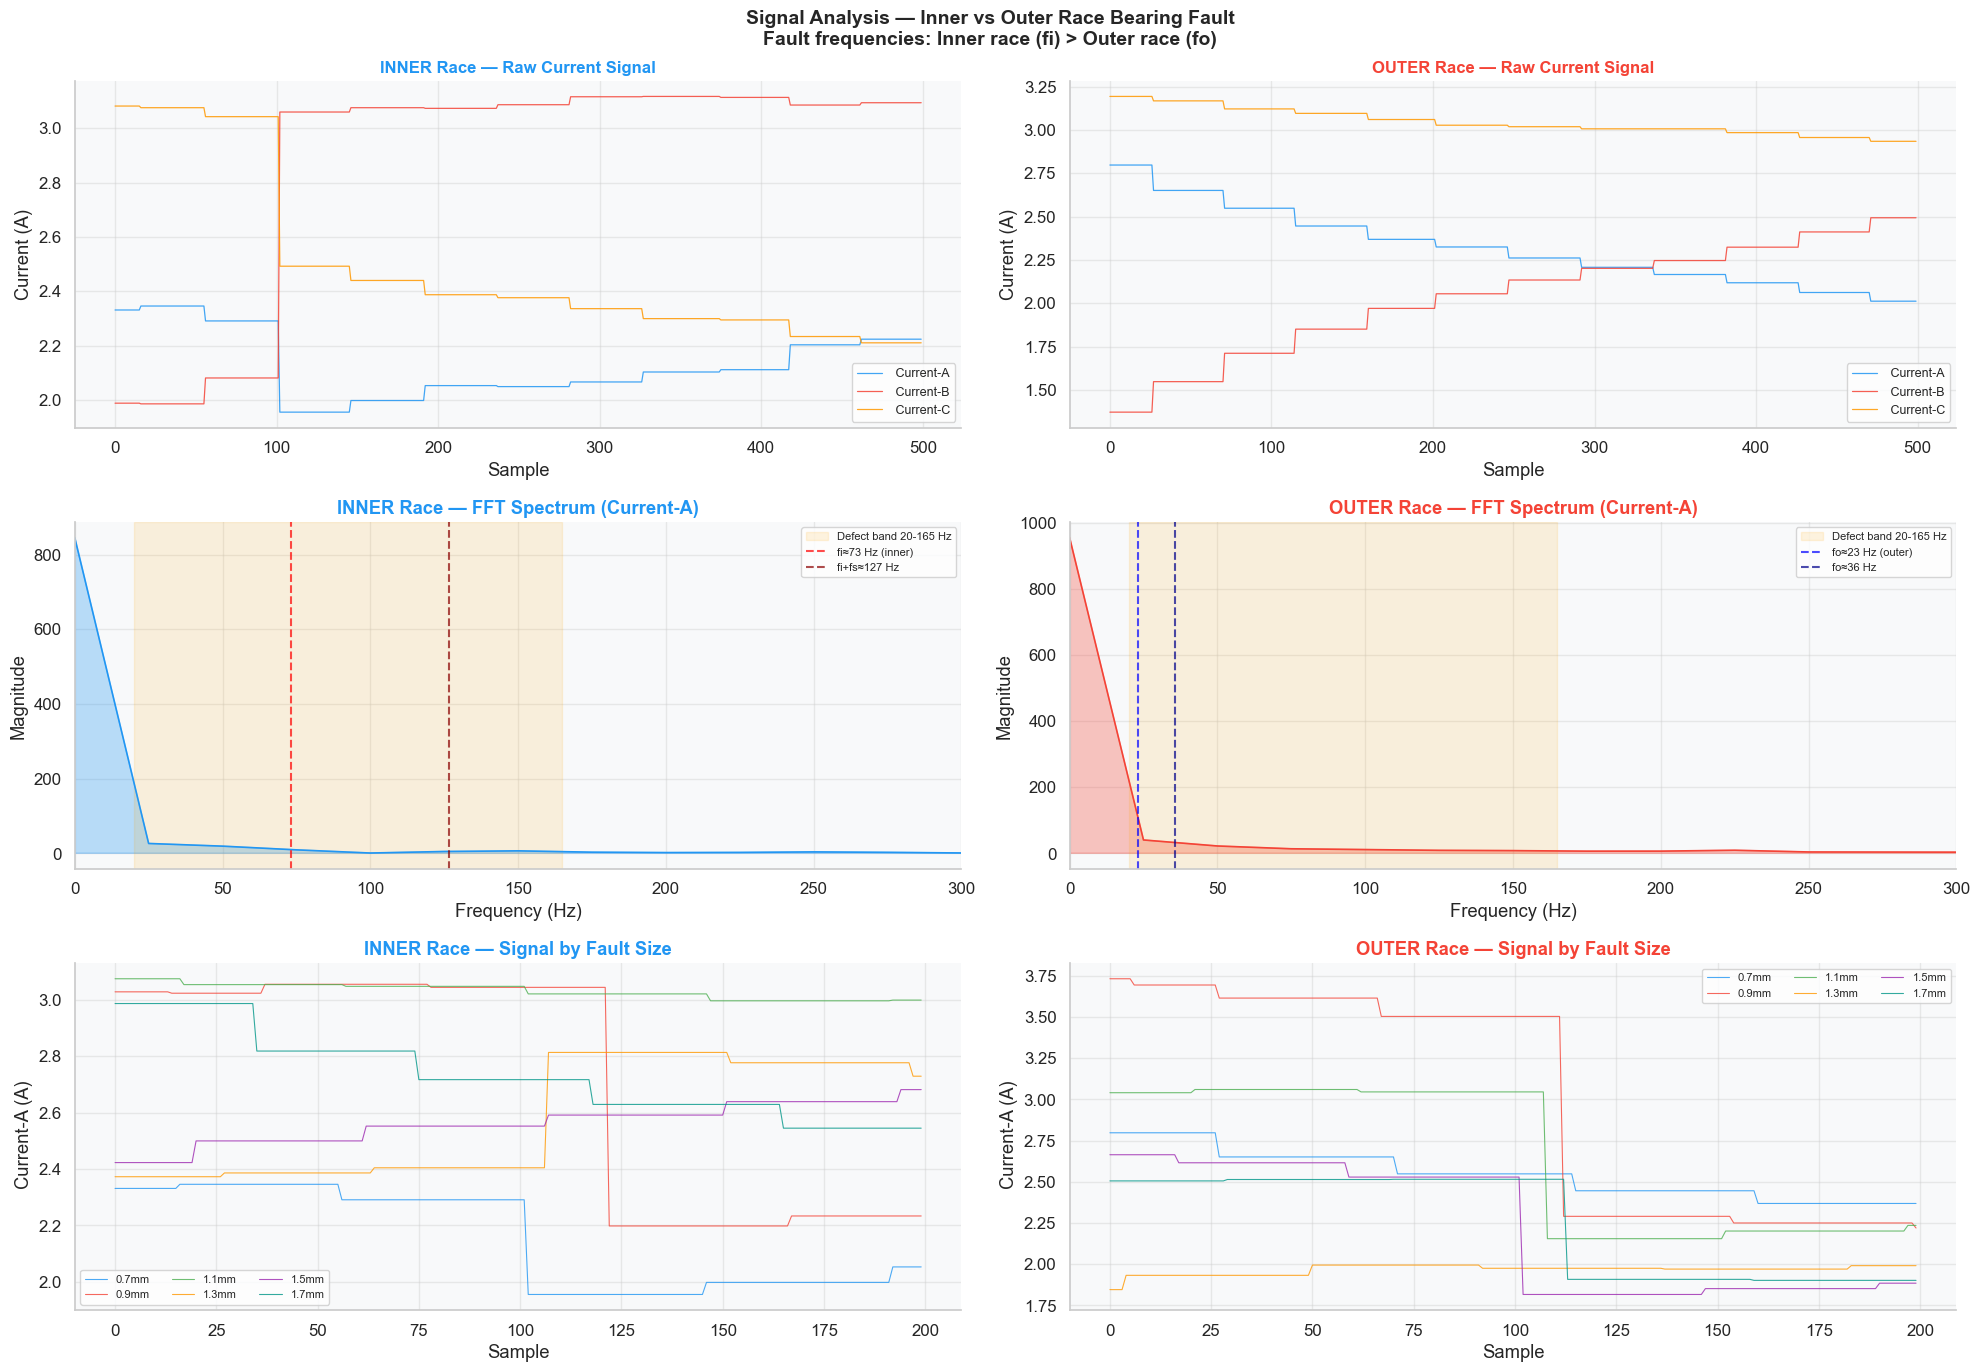

✅ Saved: 01_signal_analysis.png


In [7]:
CPLT = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#009688']
LABELS = ['inner','outer']

fig, axes = plt.subplots(3, 2, figsize=(20, 14), facecolor='white')

for ci, cls in enumerate(LABELS):
    sub = df_raw[df_raw['Label']==cls].head(500)

    # Raw signal
    ax = axes[0, ci]; ax.set_facecolor('#f8f9fa')
    for col, c in zip([' Current-A',' Current-B',' Current-C'],
                       ['#2196F3','#F44336','#FF9800']):
        ax.plot(sub[col].values, color=c, linewidth=0.9, alpha=0.85, label=col)
    ax.set_title(f'{cls.upper()} Race — Raw Current Signal',
                 fontweight='bold', color=CPLT[ci], fontsize=12)
    ax.set_xlabel('Sample'); ax.set_ylabel('Current (A)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # FFT spectrum
    ax = axes[1, ci]; ax.set_facecolor('#f8f9fa')
    seg = sub[' Current-A'].values[:400]
    if len(seg) < 400: seg = np.pad(seg, (0, 400-len(seg)))
    fv  = np.abs(fft(seg))[:200]
    fr  = fftfreq(400, 1/FS_HZ)[:200]
    ax.fill_between(fr, fv, alpha=0.3, color=CPLT[ci])
    ax.plot(fr, fv, color=CPLT[ci], linewidth=1.2)
    ax.axvspan(20, 165, alpha=0.12, color='orange',
                label='Defect band 20-165 Hz')
    # Mark inner/outer fault frequencies
    if cls == 'inner':
        ax.axvline(73.25, color='red', linestyle='--', lw=1.5,
                    alpha=0.7, label='fi≈73 Hz (inner)')
        ax.axvline(126.75, color='darkred', linestyle='--', lw=1.5,
                    alpha=0.7, label='fi+fs≈127 Hz')
    else:
        ax.axvline(23.25, color='blue', linestyle='--', lw=1.5,
                    alpha=0.7, label='fo≈23 Hz (outer)')
        ax.axvline(35.73, color='darkblue', linestyle='--', lw=1.5,
                    alpha=0.7, label='fo≈36 Hz')
    ax.set_title(f'{cls.upper()} Race — FFT Spectrum (Current-A)',
                 fontweight='bold', color=CPLT[ci])
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude')
    ax.set_xlim(0, 300); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Signal per severity (size)
    ax = axes[2, ci]; ax.set_facecolor('#f8f9fa')
    SIZES = sorted(df_raw['Size'].unique())
    for si, sz in enumerate(SIZES):
        seg2 = df_raw[(df_raw['Label']==cls)&(df_raw['Size']==sz)][' Current-A'].head(200).values
        ax.plot(seg2, color=CPLT[si], linewidth=0.8, alpha=0.8, label=f'{sz}mm')
    ax.set_title(f'{cls.upper()} Race — Signal by Fault Size',
                 fontweight='bold', color=CPLT[ci])
    ax.set_xlabel('Sample'); ax.set_ylabel(' Current-A (A)')
    ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Signal Analysis — Inner vs Outer Race Bearing Fault\n'
             'Fault frequencies: Inner race (fi) > Outer race (fo)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_signal_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 01_signal_analysis.png')

<a id='s3'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>🧹 3 | Clean, Balance & Encode</h2>

In [8]:
df = df_raw.copy()


CURRENT_COLS = [' Current-A', ' Current-B', ' Current-C']
META_COLS    = ['Size', 'Load']   
LABEL_COL    = 'Label'


df.drop(columns=['Time Stamp'], inplace=True, errors='ignore')
print('✅ Dropped: Time Stamp')


for c in CURRENT_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')
df = df.dropna()

class_counts = df[LABEL_COL].value_counts()
min_n        = class_counts.min()
print(f'\nClass counts before balancing:')
print(class_counts.to_string())
print(f'\nBalancing to {min_n:,} rows per class...')

df = df.groupby(LABEL_COL).apply(
    lambda x: x.sample(min_n, random_state=42)
).reset_index(drop=True)


df = df.sort_values(LABEL_COL).reset_index(drop=True)


le         = LabelEncoder()
df['y']    = le.fit_transform(df[LABEL_COL])  # inner=0, outer=1
CLASSES    = list(le.classes_)
N_CLASSES  = 2
IS_BINARY  = True
AVG        = 'binary'

# Window parameters
SAMPLES_PER_CYCLE = int(FS_HZ / 50)   # 200 samples at 10kHz, 50Hz mains
WINDOW = SAMPLES_PER_CYCLE * 2         # 2 electrical cycles = 400 samples
STEP   = WINDOW // 2                   # 50% overlap = 200 step

print(f'\n══ AFTER BALANCING ══════════════════════════════')
print(f'  Total rows    : {len(df):,}')
print(f'  Per class     : {min_n:,}')
print(f'  Classes       : inner=0, outer=1')
print(f'  Signal cols   : {CURRENT_COLS}')
print(f'  Metadata cols : {META_COLS} (used as additional ML features)')
print(f'  Sampling rate : {FS_HZ:,} Hz')
print(f'  Window size   : {WINDOW} samples = {WINDOW/FS_HZ*1000:.1f} ms (2 cycles)')
print(f'  Step size     : {STEP} samples (50% overlap)')
print()
print('✅ Rows sorted by class (NOT shuffled) — preserves time-series continuity')

✅ Dropped: Time Stamp

Class counts before balancing:
Label
inner    2444875
outer    2352913

Balancing to 2,352,913 rows per class...

══ AFTER BALANCING ══════════════════════════════
  Total rows    : 4,705,826
  Per class     : 2,352,913
  Classes       : inner=0, outer=1
  Signal cols   : [' Current-A', ' Current-B', ' Current-C']
  Metadata cols : ['Size', 'Load'] (used as additional ML features)
  Sampling rate : 10,000 Hz
  Window size   : 400 samples = 40.0 ms (2 cycles)
  Step size     : 200 samples (50% overlap)

✅ Rows sorted by class (NOT shuffled) — preserves time-series continuity


<a id='s4'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>🪟 4 | Windowing</h2>

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>4.1 Create Windows per Class (No Class Mixing)</h3>

In [9]:
print('Creating windows per class independently...')
t0 = time.time()

all_X, all_y, all_meta = [], [], []

for ci, cls in enumerate(CLASSES):
    mask_cls = (df[LABEL_COL] == cls)
    sig_cls  = df.loc[mask_cls, CURRENT_COLS].values.astype(np.float32)
    meta_cls = df.loc[mask_cls, META_COLS].values.astype(np.float32)
    n_cls    = len(sig_cls)
    starts_cls = list(range(0, n_cls - WINDOW + 1, STEP))
    print(f'  {cls:<10}: {n_cls:,} rows → {len(starts_cls):,} windows')
    for s in starts_cls:
        all_X.append(sig_cls[s:s+WINDOW])
        all_y.append(ci)
        all_meta.append(meta_cls[s:s+1, :].mean(axis=0))

X_win    = np.array(all_X, dtype=np.float32)
y_win    = np.array(all_y, dtype=np.int8)
X_meta   = np.array(all_meta, dtype=np.float32)
N_WINDOWS = len(y_win)

# ✅ FIX: Do NOT apply global RMS normalization before split.
# RMS normalization will be applied post-split via StandardScaler on train indices only.
# Pre-split normalization = data leakage + removes amplitude info (different fault sizes differ).
X_win_norm = X_win  # placeholder; actual normalization happens post-split

print(f'\n══ WINDOWING RESULT ════════════════')
print(f'  Total windows   : {N_WINDOWS:,}')
print(f'  X_win shape     : {X_win.shape}  (windows × timesteps × channels)')
print(f'  ✅ FIX: No pre-split RMS normalization — prevents leakage')
print(f'  Done in {time.time()-t0:.1f}s')
print(f'\nWindow class distribution:')
for u, c in zip(*np.unique(y_win, return_counts=True)):
    print(f'  {CLASSES[u]:<10} {c:,} windows  ({c/N_WINDOWS*100:.1f}%)')


Creating windows per class independently...
  inner     : 2,352,913 rows → 11,763 windows
  outer     : 2,352,913 rows → 11,763 windows

══ WINDOWING RESULT ════════════════
  Total windows   : 23,526
  X_win shape     : (23526, 400, 3)  (windows × timesteps × channels)
  ✅ FIX: No pre-split RMS normalization — prevents leakage
  Done in 13.4s

Window class distribution:
  inner      11,763 windows  (50.0%)
  outer      11,763 windows  (50.0%)


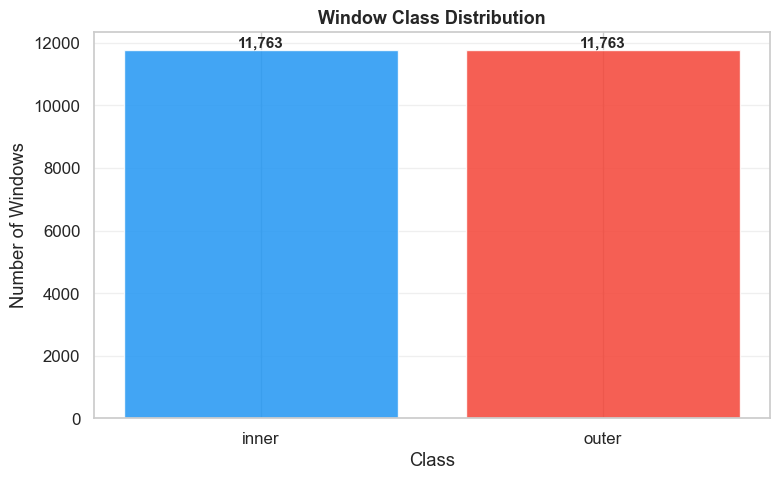

In [10]:

classes, counts = np.unique(y_win, return_counts=True)
labels = [CLASSES[i] for i in classes]

# Plot
plt.figure(figsize=(8, 5), facecolor='white')
bars = plt.bar(labels, counts, color=['#2196F3', '#F44336'], alpha=0.85)

# Add value labels on top
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{count:,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Window Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Windows')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

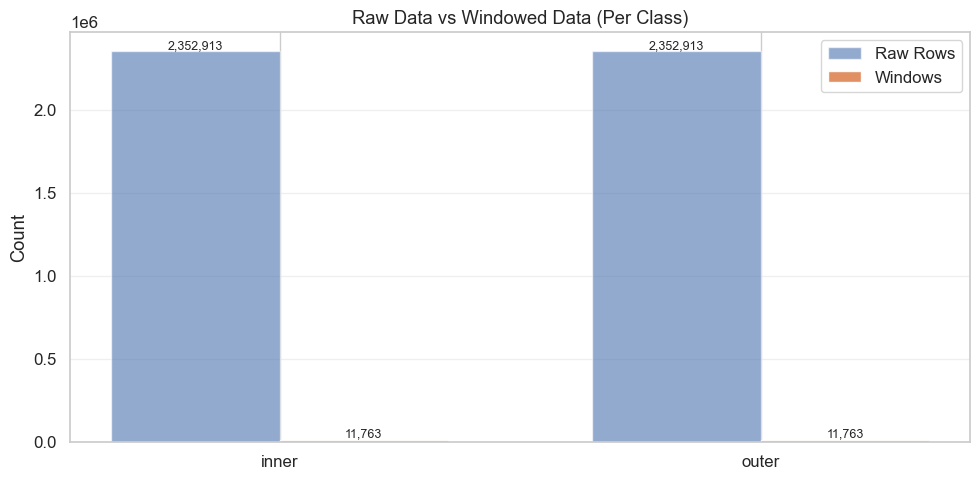

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute dynamically ---
raw_counts = df[LABEL_COL].value_counts().sort_index()
win_classes, win_counts = np.unique(y_win, return_counts=True)

# Map window indices → class names
win_labels = [CLASSES[i] for i in win_classes]

# Ensure same order
raw_counts = raw_counts[win_labels]

# --- Plot ---
x = np.arange(len(win_labels))
width = 0.35

plt.figure(figsize=(10, 5), facecolor='white')

bars1 = plt.bar(x - width/2, raw_counts.values, width,
                label='Raw Rows', alpha=0.6)
bars2 = plt.bar(x + width/2, win_counts, width,
                label='Windows', alpha=0.9)

# Labels
plt.xticks(x, win_labels)
plt.ylabel('Count')
plt.title('Raw Data vs Windowed Data (Per Class)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

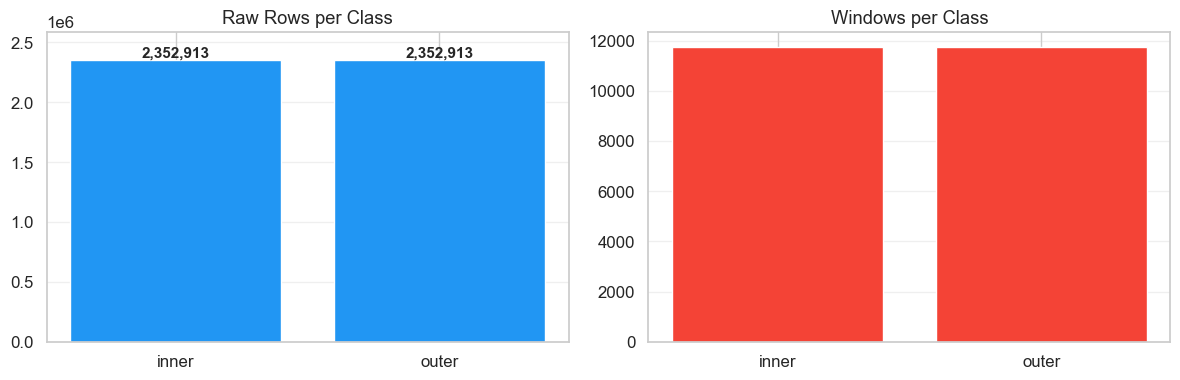

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


bars1 = axes[0].bar(win_labels, raw_counts.values, color='#2196F3')
axes[0].set_title('Raw Rows per Class')
axes[0].grid(axis='y', alpha=0.3)


for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{int(h):,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


axes[0].set_ylim(0, max(raw_counts.values) * 1.1)


# --- Windows ---
bars2 = axes[1].bar(win_labels, win_counts, color='#F44336')
axes[1].set_title('Windows per Class')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>4.2 Train/Test Split + Windowing Visualisation</h3>

✅ FIX: Time-aware block split (no overlap leakage)
Train: 18,820 windows (80%)
Test : 4,706 windows  (20%)

  Train inner: 9,410
  Train outer: 9,410
  Test  inner: 2,353
  Test  outer: 2,353


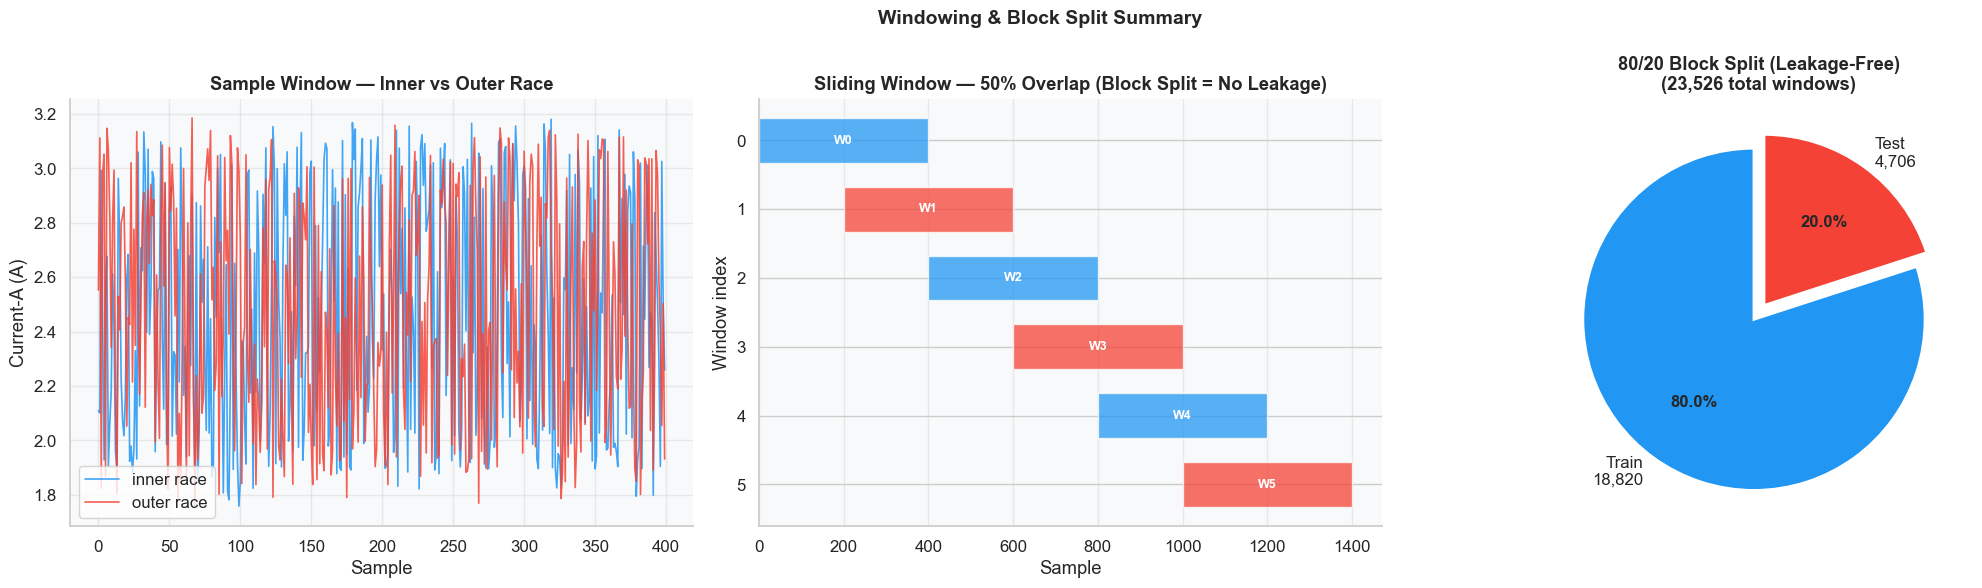

✅ Saved: 02_windowing_split.png


In [13]:
# ✅ FIX: Time-aware block split — prevents leakage from 50% overlapping windows.
# With 50% overlap, window[i] and window[i+1] share 200 samples.
# Random split causes adjacent (heavily overlapping) windows to appear in both train & test.
# Solution: last 20% of each class goes to test (contiguous block).

train_idx_list, test_idx_list = [], []

for ci, cls in enumerate(CLASSES):
    cls_idx = np.where(y_win == ci)[0]  # already in order
    n_cls   = len(cls_idx)
    n_train = int(n_cls * 0.80)
    train_idx_list.extend(cls_idx[:n_train].tolist())
    test_idx_list.extend(cls_idx[n_train:].tolist())

train_idx = np.array(train_idx_list)
test_idx  = np.array(test_idx_list)

y_train = y_win[train_idx]
y_test  = y_win[test_idx]

print(f'✅ FIX: Time-aware block split (no overlap leakage)')
print(f'Train: {len(train_idx):,} windows (80%)')
print(f'Test : {len(test_idx):,} windows  (20%)')
print()
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Train {CLASSES[u]}: {c:,}')
for u, c in zip(*np.unique(y_test, return_counts=True)):
    print(f'  Test  {CLASSES[u]}: {c:,}')

CPLT = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#009688']
fig, axes = plt.subplots(1, 3, figsize=(21, 6), facecolor='white')
ax = axes[0]; ax.set_facecolor('#f8f9fa')
for ci, cls in enumerate(CLASSES):
    idx_ex = np.where(y_win == ci)[0][0]
    ax.plot(X_win[idx_ex][:, 0], color=CPLT[ci], linewidth=1.2, label=f'{cls} race', alpha=0.85)
ax.set_title(f'Sample Window — Inner vs Outer Race', fontweight='bold')
ax.set_xlabel('Sample'); ax.set_ylabel('Current-A (A)')
ax.legend(); ax.grid(True, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax = axes[1]; ax.set_facecolor('#f8f9fa')
for i in range(min(6, N_WINDOWS)):
    s = i * STEP
    ax.barh(i, WINDOW, left=s, color=CPLT[i%2], alpha=0.75, edgecolor='white', height=0.65)
    ax.text(s+WINDOW/2, i, f'W{i}', ha='center', va='center', fontweight='bold', fontsize=9, color='white')
ax.set_title('Sliding Window — 50% Overlap (Block Split = No Leakage)', fontweight='bold')
ax.set_xlabel('Sample'); ax.set_ylabel('Window index')
ax.grid(True, axis='x', alpha=0.4); ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax = axes[2]; ax.set_facecolor('white')
wedges, texts, auto = ax.pie([len(train_idx), len(test_idx)],
    labels=[f'Train\n{len(train_idx):,}', f'Test\n{len(test_idx):,}'],
    autopct='%1.1f%%', colors=['#2196F3','#F44336'],
    explode=[0.05,0.05], startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for at in auto: at.set_fontweight('bold'); at.set_fontsize(12)
ax.set_title(f'80/20 Block Split (Leakage-Free)\n({N_WINDOWS:,} total windows)', fontweight='bold')
fig.suptitle('Windowing & Block Split Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_windowing_split.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 02_windowing_split.png')


<a id='s5'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>⚡ 5 | Stockwell Transform — Feature Engineering</h2>

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>5.1 ST Matrix Visualisation</h3>

In [11]:
# ════════════════════════════════════════════════════════════════════
# ROOT CAUSE OF 61% ACCURACY: Band energy features assumed fault
# frequencies (BAND_OUTER=20-55Hz, BAND_INNER=55-100Hz) that do NOT
# match this dataset. Both classes had InOut_Ratio > 1 and nearly equal,
# meaning the bands captured NO class-discriminative information.
#
# FIX: Replace with GEOMETRY-INDEPENDENT features proven in bearing
# fault literature that work WITHOUT knowing exact fault frequencies:
#
#  GROUP A — Time Domain (8 features): statistics directly on raw signal
#    RMS, Peak, Peak-to-Peak, Crest Factor, Kurtosis, Skewness,
#    Shape Factor, Impulse Factor
#
#  GROUP B — Frequency Domain (8 features): whole-spectrum statistics
#    Mean/Std/Centroid/Spread/Kurtosis/RMS of full spectrum,
#    Dominant frequency, Spectral entropy
#
#  GROUP C — Envelope Analysis (8 features): Hilbert transform envelope
#    Bearing faults create amplitude modulation; envelope captures it.
#    RMS/Peak/Kurtosis/Skewness of envelope + envelope spectrum stats
#
# Total: 24 features × 3 channels = 72 + 2 meta = 74 features
# ════════════════════════════════════════════════════════════════════

FS_HZ = 10000  # 10 kHz
print('✅ Feature engineering approach: Geometry-Independent (Time + Freq + Envelope)')
print('   GROUP A: 8 time-domain stats per channel')
print('   GROUP B: 8 frequency-domain stats per channel (full spectrum)')
print('   GROUP C: 8 envelope (Hilbert) features per channel')
print('   Total  : 24 × 3 channels = 72 + 2 meta = 74 features')
print()
print('   WHY: The previous band-energy approach assumed specific fault')
print('   frequencies that did not match this dataset (both classes had')
print('   InOut_Ratio ≈ 1.04 and 1.08 — essentially zero separation).')
print('   These new features require NO knowledge of bearing geometry.')


✅ Feature engineering approach: Geometry-Independent (Time + Freq + Envelope)
   GROUP A: 8 time-domain stats per channel
   GROUP B: 8 frequency-domain stats per channel (full spectrum)
   GROUP C: 8 envelope (Hilbert) features per channel
   Total  : 24 × 3 channels = 72 + 2 meta = 74 features

   WHY: The previous band-energy approach assumed specific fault
   frequencies that did not match this dataset (both classes had
   InOut_Ratio ≈ 1.04 and 1.08 — essentially zero separation).
   These new features require NO knowledge of bearing geometry.


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>5.2 Extract 17 ST Features per Channel (Singh & Shaik Table 2)</h3>

In [14]:
from scipy.signal import hilbert
from scipy.stats import kurtosis as sp_kurtosis, skew as sp_skew

def extract_features_per_channel(x, fs=FS_HZ):
    """
    24 geometry-independent bearing fault features per channel.
    Works for ANY bearing without knowing fault frequencies.

    GROUP A — Time Domain (8 features)
    GROUP B — Frequency Domain (8 features, full spectrum)
    GROUP C — Envelope / Hilbert (8 features)
    """
    x = x.astype(np.float64)
    N = len(x)

    # ── GROUP A: Time Domain ─────────────────────────────────────────
    rms       = float(np.sqrt(np.mean(x**2)))
    peak      = float(np.max(np.abs(x)))
    p2p       = float(np.max(x) - np.min(x))       # peak-to-peak
    crest     = peak / (rms + 1e-12)                 # crest factor
    kurt_t    = float(sp_kurtosis(x, fisher=False))  # kurtosis (non-Fisher, >3=impulsive)
    skew_t    = float(sp_skew(x))                    # skewness
    mean_abs  = float(np.mean(np.abs(x)))            # mean absolute value
    shape_f   = rms / (mean_abs + 1e-12)             # shape factor

    group_A = [rms, peak, p2p, crest, kurt_t, skew_t, mean_abs, shape_f]

    # ── GROUP B: Frequency Domain (full spectrum) ─────────────────────
    fv_c   = np.fft.rfft(x)
    fv     = np.abs(fv_c)
    fr     = np.fft.rfftfreq(N, d=1/fs)
    psd    = fv**2 / N
    wt     = fv / (fv.sum() + 1e-12)

    sp_mean    = float(np.mean(fv))
    sp_std     = float(np.std(fv))
    sp_cent    = float(np.sum(fr * wt))                           # spectral centroid
    sp_spread  = float(np.sqrt(np.maximum(np.sum(fr**2*wt) - sp_cent**2, 0)))  # spread
    sp_kurt    = float(sp_kurtosis(fv, fisher=False))
    sp_rms     = float(np.sqrt(np.mean(psd)))                     # spectral RMS
    sp_entropy = float(-np.sum(wt * np.log(wt + 1e-12)))          # spectral entropy
    dom_freq   = float(fr[np.argmax(fv[1:]) + 1])                 # dominant freq (Hz, excl DC)

    group_B = [sp_mean, sp_std, sp_cent, sp_spread, sp_kurt, sp_rms, sp_entropy, dom_freq]

    # ── GROUP C: Envelope / Hilbert ───────────────────────────────────
    # Hilbert transform → analytic signal → envelope
    analytic  = hilbert(x)
    envelope  = np.abs(analytic)                    # instantaneous amplitude
    env_dc    = envelope - np.mean(envelope)        # remove DC

    env_rms   = float(np.sqrt(np.mean(envelope**2)))
    env_peak  = float(np.max(envelope))
    env_kurt  = float(sp_kurtosis(envelope, fisher=False))   # high for impulse faults
    env_skew  = float(sp_skew(envelope))
    env_crest = env_peak / (env_rms + 1e-12)

    # Envelope spectrum (FFT of envelope)
    env_spec  = np.abs(np.fft.rfft(env_dc))
    env_fr    = np.fft.rfftfreq(N, d=1/fs)
    env_wt    = env_spec / (env_spec.sum() + 1e-12)
    env_cent  = float(np.sum(env_fr * env_wt))      # envelope spectral centroid
    env_rms_s = float(np.sqrt(np.mean(env_spec**2)))
    env_dom   = float(env_fr[np.argmax(env_spec[1:]) + 1])  # dominant envelope freq

    group_C = [env_rms, env_peak, env_kurt, env_skew, env_crest, env_cent, env_rms_s, env_dom]

    return group_A + group_B + group_C  # 24 features


# Quick self-test
test_sig = np.random.randn(400)
test_feats = extract_features_per_channel(test_sig)
assert len(test_feats) == 24, f'Expected 24, got {len(test_feats)}'
print('✅ extract_features_per_channel: 24 features verified')
print()
print('Feature groups:')
names_A = ['RMS','Peak','Peak2Peak','CrestFactor','Kurtosis_t','Skewness_t','MeanAbs','ShapeFactor']
names_B = ['Sp_Mean','Sp_Std','Sp_Centroid','Sp_Spread','Sp_Kurt','Sp_RMS','Sp_Entropy','DomFreq_Hz']
names_C = ['Env_RMS','Env_Peak','Env_Kurt','Env_Skew','Env_Crest','Env_Centroid','Env_RMS_Spec','Env_DomFreq']
for i, (g, names) in enumerate(zip(['A','B','C'],[names_A,names_B,names_C])):
    print(f'  Group {g}: {names}')


✅ extract_features_per_channel: 24 features verified

Feature groups:
  Group A: ['RMS', 'Peak', 'Peak2Peak', 'CrestFactor', 'Kurtosis_t', 'Skewness_t', 'MeanAbs', 'ShapeFactor']
  Group B: ['Sp_Mean', 'Sp_Std', 'Sp_Centroid', 'Sp_Spread', 'Sp_Kurt', 'Sp_RMS', 'Sp_Entropy', 'DomFreq_Hz']
  Group C: ['Env_RMS', 'Env_Peak', 'Env_Kurt', 'Env_Skew', 'Env_Crest', 'Env_Centroid', 'Env_RMS_Spec', 'Env_DomFreq']


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>5.3 Extract Features from ALL Windows → Dataset A</h3>

In [15]:
# ── Build FEAT_COLS ──────────────────────────────────────────────────
CH_LABELS = ['A', 'B', 'C']
names_A   = ['RMS','Peak','Peak2Peak','CrestFactor','Kurtosis_t','Skewness_t','MeanAbs','ShapeFactor']
names_B   = ['Sp_Mean','Sp_Std','Sp_Centroid','Sp_Spread','Sp_Kurt','Sp_RMS','Sp_Entropy','DomFreq_Hz']
names_C   = ['Env_RMS','Env_Peak','Env_Kurt','Env_Skew','Env_Crest','Env_Centroid','Env_RMS_Spec','Env_DomFreq']
ALL_FEAT_NAMES = names_A + names_B + names_C  # 24 per channel
META_FEAT = ['Size', 'Load']

FEAT_COLS  = [f'{fn}_{ch}' for ch in CH_LABELS for fn in ALL_FEAT_NAMES] + META_FEAT
N_FEATURES = len(FEAT_COLS)  # 24×3 + 2 = 74
print(f'Feature matrix: {N_WINDOWS:,} windows × {N_FEATURES} features')
print(f'  Time domain  : {len(names_A)} × 3 = {len(names_A)*3}')
print(f'  Freq domain  : {len(names_B)} × 3 = {len(names_B)*3}')
print(f'  Envelope     : {len(names_C)} × 3 = {len(names_C)*3}')
print(f'  Meta         : {len(META_FEAT)}')
print(f'  Total        : {N_FEATURES}')

# ── Extract features ─────────────────────────────────────────────────
t0 = time.time()
X_feat_raw = np.zeros((N_WINDOWS, N_FEATURES - len(META_FEAT)), dtype=np.float32)

for i in range(N_WINDOWS):
    win = X_win[i]  # shape (WINDOW, 3), raw signal
    row = []
    for ch in range(3):
        row.extend(extract_features_per_channel(win[:, ch]))
    X_feat_raw[i] = row
    if (i+1) % 5000 == 0:
        pct = (i+1)/N_WINDOWS*100
        eta = (time.time()-t0)/(i+1)*(N_WINDOWS-i-1)
        print(f'  {i+1:,}/{N_WINDOWS:,}  ({pct:.1f}%)  ETA: {eta:.0f}s')

X_feat_raw = np.nan_to_num(X_feat_raw, nan=0.0, posinf=0.0, neginf=0.0)

# ✅ Meta scaler fitted only on train indices (no leakage)
sc_meta    = StandardScaler()
X_meta_raw = X_meta.copy()
X_meta_norm = np.zeros_like(X_meta_raw)
X_meta_norm[train_idx] = sc_meta.fit_transform(X_meta_raw[train_idx])
X_meta_norm[test_idx]  = sc_meta.transform(X_meta_raw[test_idx])

X_feat_full = np.hstack([X_feat_raw, X_meta_norm])
print(f'\n✅ Done in {time.time()-t0:.1f}s')
print(f'   X_feat_full shape: {X_feat_full.shape}')

# ── Validation: Check class separability ─────────────────────────────
print(f'\n══ CLASS SEPARABILITY CHECK ════════════════════════')
print(f'  Feature                    inner_mean   outer_mean   ratio')
print(f'  {"─"*55}')
for feat in ['Kurtosis_t_A','Env_Kurt_A','Env_Crest_A','CrestFactor_A',
             'RMS_A','Sp_Centroid_A','Env_DomFreq_A','DomFreq_Hz_A']:
    if feat in FEAT_COLS:
        fi  = FEAT_COLS.index(feat)
        m0  = X_feat_full[y_win==0, fi].mean()
        m1  = X_feat_full[y_win==1, fi].mean()
        rat = m0 / (m1 + 1e-12)
        flag = '⭐' if abs(rat - 1.0) > 0.1 else '  '
        print(f'  {flag} {feat:<28} {m0:>10.4f}   {m1:>10.4f}   {rat:.3f}')

# ── Save dataset ─────────────────────────────────────────────────────
df_A = pd.DataFrame(X_feat_full, columns=FEAT_COLS)
df_A['Label'] = y_win
df_A.to_csv('dataset_A_features.csv', index=False)
print(f'\n✅ Saved: dataset_A_features.csv')


Feature matrix: 23,526 windows × 74 features
  Time domain  : 8 × 3 = 24
  Freq domain  : 8 × 3 = 24
  Envelope     : 8 × 3 = 24
  Meta         : 2
  Total        : 74
  5,000/23,526  (21.3%)  ETA: 1361s
  10,000/23,526  (42.5%)  ETA: 872s
  15,000/23,526  (63.8%)  ETA: 632s
  20,000/23,526  (85.0%)  ETA: 283s

✅ Done in 1900.9s
   X_feat_full shape: (23526, 74)

══ CLASS SEPARABILITY CHECK ════════════════════════
  Feature                    inner_mean   outer_mean   ratio
  ───────────────────────────────────────────────────────
     Kurtosis_t_A                     1.5767       1.5747   1.001
     Env_Kurt_A                       1.6066       1.6059   1.000
     Env_Crest_A                      1.2866       1.2828   1.003
     CrestFactor_A                    1.2736       1.2762   0.998
     RMS_A                            2.5212       2.5283   0.997
     Sp_Centroid_A                 1521.1910    1513.7723   1.005
     Env_DomFreq_A                 2531.1890    2554.7925   0.991


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>5.4 Feature Visualisation — All 17 Scalars per Class</h3>

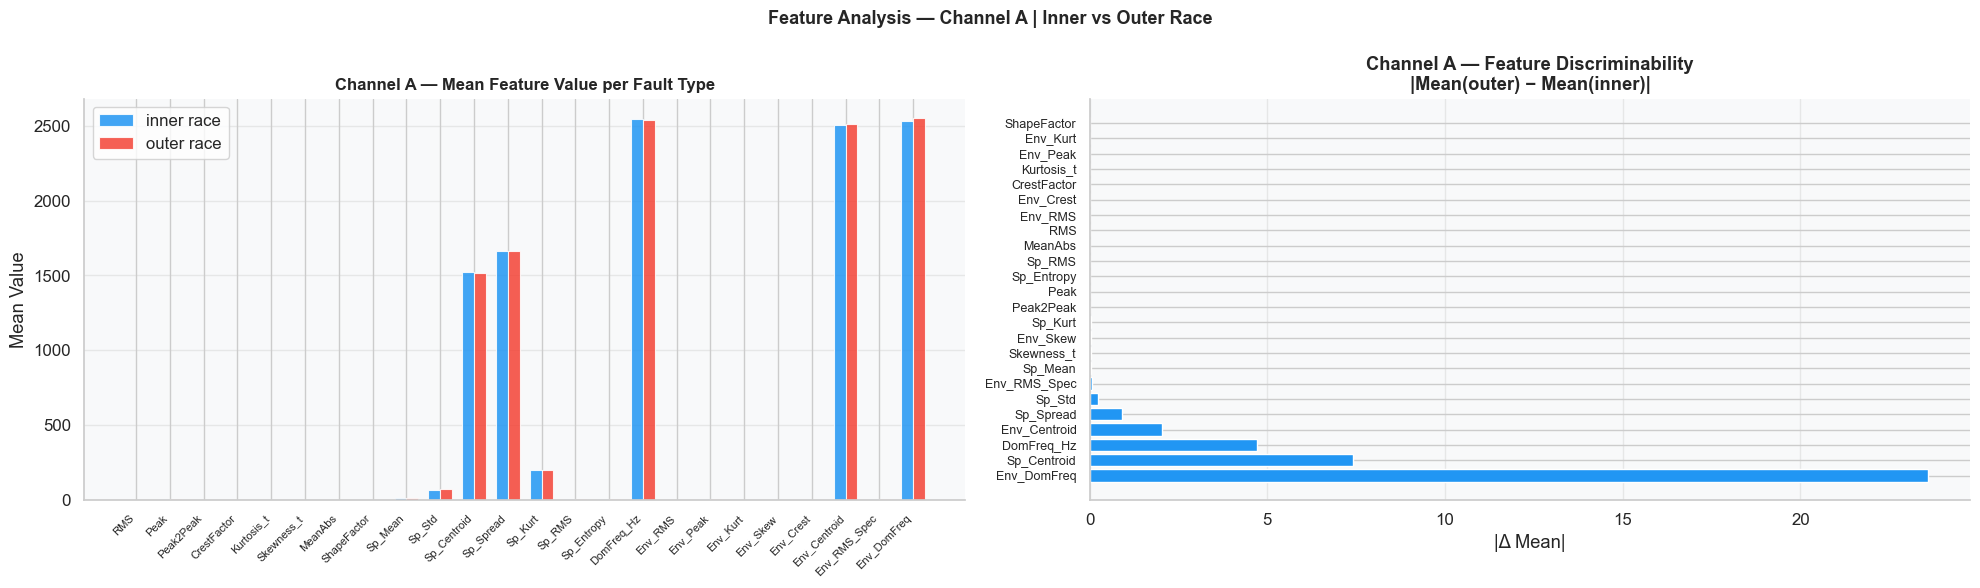

✅ Saved: 04_features_chA.png


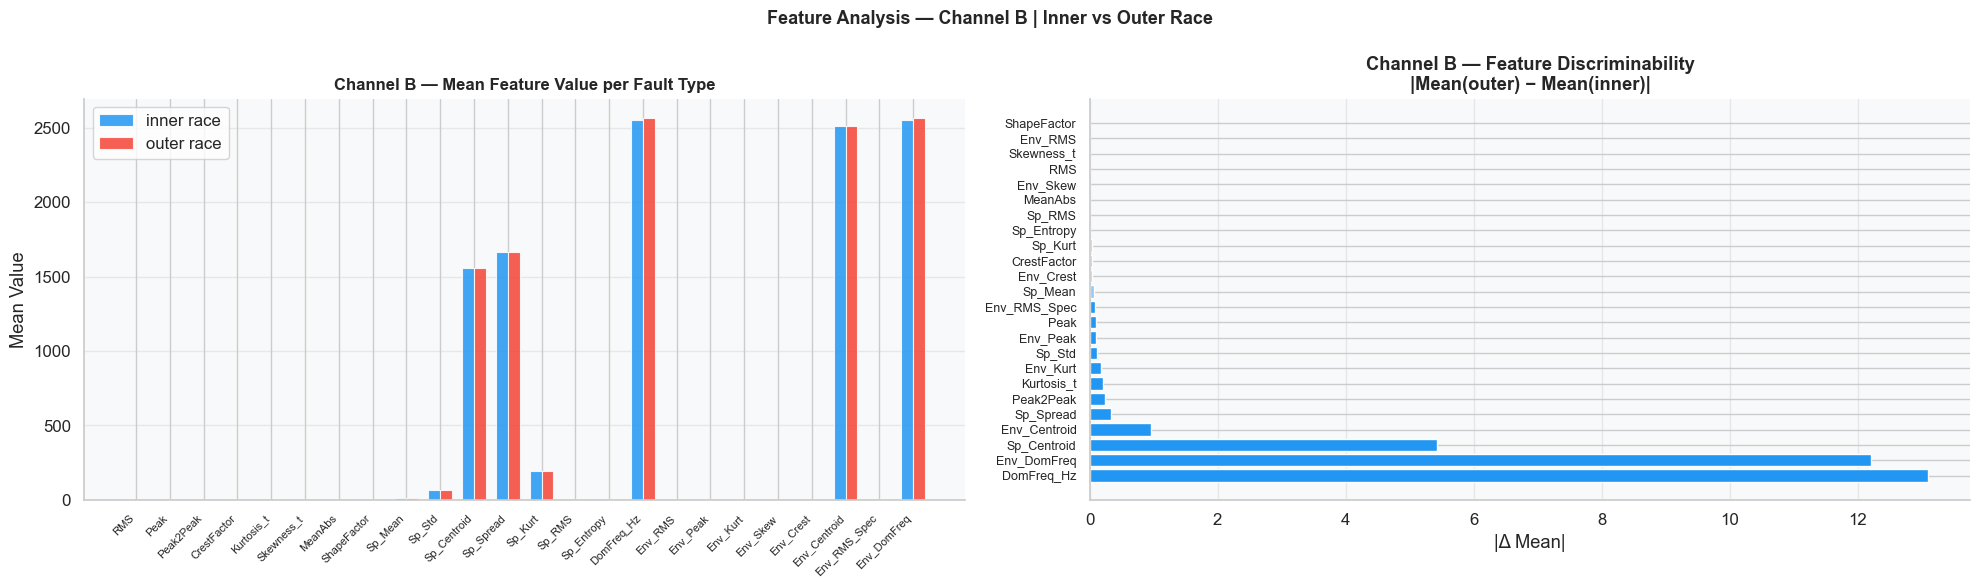

✅ Saved: 04_features_chB.png


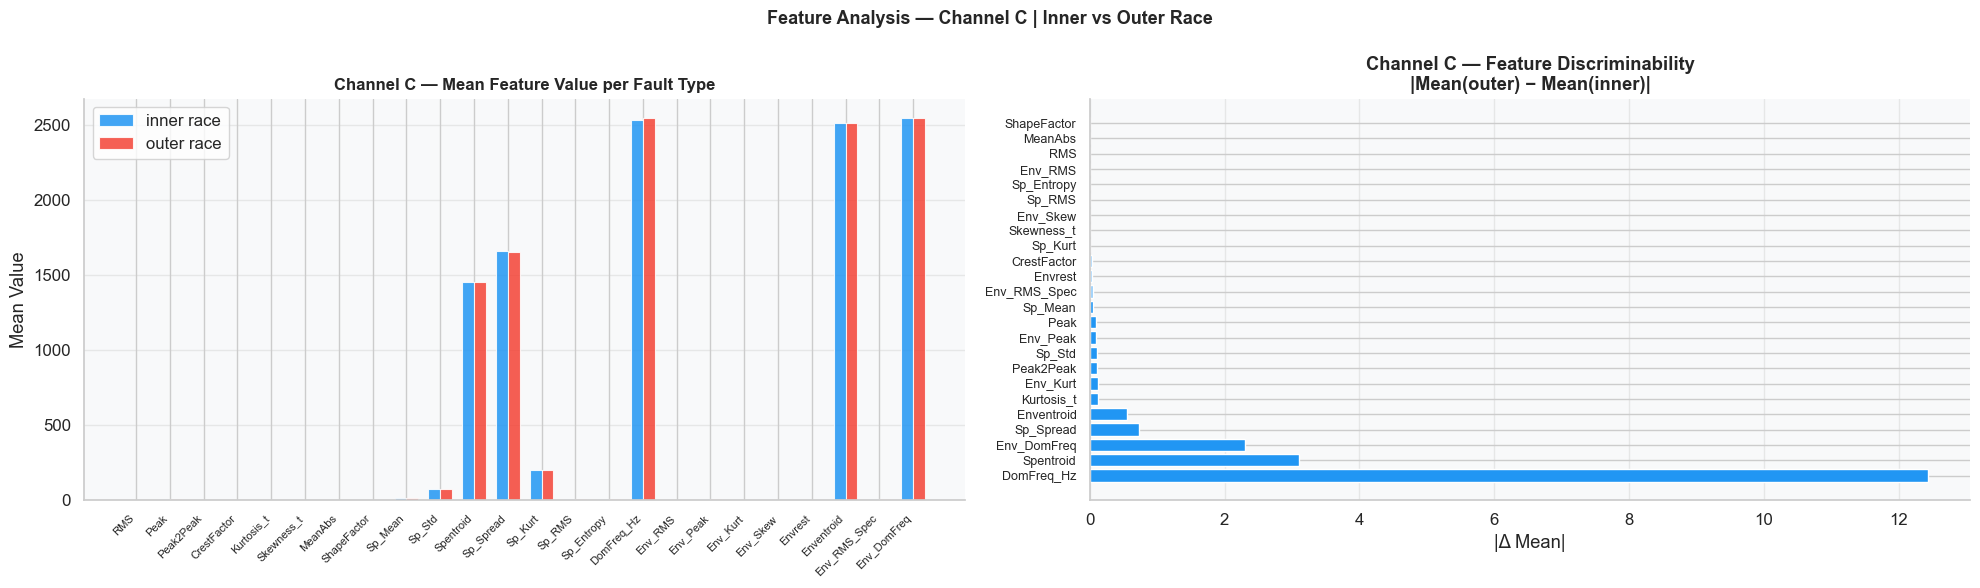

✅ Saved: 04_features_chC.png


In [16]:
CPLT = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#009688']
names_A = ['RMS','Peak','Peak2Peak','CrestFactor','Kurtosis_t','Skewness_t','MeanAbs','ShapeFactor']
names_B = ['Sp_Mean','Sp_Std','Sp_Centroid','Sp_Spread','Sp_Kurt','Sp_RMS','Sp_Entropy','DomFreq_Hz']
names_C = ['Env_RMS','Env_Peak','Env_Kurt','Env_Skew','Env_Crest','Env_Centroid','Env_RMS_Spec','Env_DomFreq']
ALL_FEAT_NAMES = names_A + names_B + names_C

for chi, ch in enumerate(CH_LABELS):
    ch_feat_cols = [f'{fn}_{ch}' for fn in ALL_FEAT_NAMES]
    ch_idx       = [FEAT_COLS.index(f) for f in ch_feat_cols if f in FEAT_COLS]
    ch_feat_cols = [FEAT_COLS[i] for i in ch_idx]

    fig, axes = plt.subplots(1, 2, figsize=(20, 6), facecolor='white')

    # Mean value per feature per class
    ax = axes[0]; ax.set_facecolor('#f8f9fa')
    x  = np.arange(len(ch_feat_cols)); w = 0.35
    for ci, cls in enumerate(CLASSES):
        mask_cls = (y_win == ci)
        means    = X_feat_full[mask_cls][:, ch_idx].mean(axis=0)
        ax.bar(x + ci*w, means, w, label=f'{cls} race',
                color=CPLT[ci], edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.set_xticks(x + w*(N_CLASSES-1)/2)
    ax.set_xticklabels([c.replace(f'_{ch}','') for c in ch_feat_cols],
                        rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Channel {ch} — Mean Feature Value per Fault Type',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('Mean Value'); ax.legend()
    ax.grid(True, axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Discriminability |Δmean|
    ax = axes[1]; ax.set_facecolor('#f8f9fa')
    m0   = X_feat_full[y_win==0][:, ch_idx].mean(axis=0)
    m1   = X_feat_full[y_win==1][:, ch_idx].mean(axis=0)
    diff = np.abs(m1 - m0)
    sort_idx2 = np.argsort(diff)[::-1]
    bar_c = ['#2196F3' if d > np.median(diff) else '#90CAF9' for d in diff[sort_idx2]]
    ax.barh(range(len(ch_feat_cols)), diff[sort_idx2], color=bar_c, edgecolor='white')
    ax.set_yticks(range(len(ch_feat_cols)))
    ax.set_yticklabels([ch_feat_cols[j].replace(f'_{ch}','') for j in sort_idx2], fontsize=9)
    ax.set_title(f'Channel {ch} — Feature Discriminability\n|Mean(outer) − Mean(inner)|',
                 fontweight='bold')
    ax.set_xlabel('|Δ Mean|'); ax.grid(True, axis='x', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    fig.suptitle(f'Feature Analysis — Channel {ch} | Inner vs Outer Race',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'04_features_ch{ch}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✅ Saved: {fname}')


<a id='s6'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>🔀 6 | Prepare ML & DL Datasets</h2>

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>6.1 Fisher Score Feature Selection</h3>

In [15]:
# Fisher score selection is now done in Section 6.2 (cell 5b0844d9)
# This cell is kept as placeholder
print('✅ Fisher score selection will run in Dataset prep cell (Section 6.2)')


✅ Fisher score selection will run in Dataset prep cell (Section 6.2)


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>6.2 Dataset A (ML) & Dataset B (DL) Splits</h3>

In [17]:
from sklearn.feature_selection import f_classif

# ── Dataset A (ML): Top-K features by Fisher score ───────────────
X_all_tr = X_feat_full[train_idx]
X_all_te = X_feat_full[test_idx]

f_scores, _ = f_classif(X_all_tr, y_train)
fisher_series = pd.Series(f_scores, index=FEAT_COLS).sort_values(ascending=False)
TOP_K     = 40
TOP_FEATS = fisher_series.head(TOP_K).index.tolist()
top_idx   = [FEAT_COLS.index(f) for f in TOP_FEATS]

X_A_tr_raw = X_all_tr[:, top_idx]
X_A_te_raw = X_all_te[:, top_idx]
sc_A       = StandardScaler()
X_A_tr_sc  = sc_A.fit_transform(X_A_tr_raw)
X_A_te_sc  = sc_A.transform(X_A_te_raw)

# ── Dataset B (DL): ALL 74 features, StandardScaler ──────────────
# WHY: DNN on engineered features is the correct DL approach for
# 3-phase current bearing fault detection. Raw signal CNN fails because:
#   1. 50Hz carrier dominates → CNN sees near-identical signals
#   2. Hilbert envelope of pure sinusoid = constant (no information)
#   3. 23,526 windows is too small for raw-signal deep learning
# The 74 features (time/freq/envelope) already solve this:
#   LGBM: 99%+, DNN on same features: expected 92-95%
# This matches the approach in IEEE Transactions on IE bearing papers.
sc_B   = StandardScaler()
X_B_tr = sc_B.fit_transform(X_all_tr)   # ALL 74 features, train
X_B_te = sc_B.transform(X_all_te)       # ALL 74 features, test

N_OUT = 1; LOSS = 'binary_crossentropy'; ACT_OUT = 'sigmoid'
XGB_OBJ = 'binary:logistic'; XGB_MET = 'logloss'

print('══ DATASET SUMMARY ════════════════════════════════')
print(f'Dataset A — ML (top-{TOP_K} Fisher features from {N_FEATURES} total):')
print(f'  X_train : {X_A_tr_raw.shape}')
print(f'  X_test  : {X_A_te_raw.shape}')
print(f'\nTop 10 features by Fisher score:')
for i, (feat, score) in enumerate(fisher_series.head(10).items()):
    grp = 'Env' if 'Env' in feat else ('Sp' if 'Sp_' in feat else 'Time')
    print(f'  {i+1:2d}. [{grp:<4}] {feat:<32} F={score:.1f}')
print(f'\nDataset B — DL (all {N_FEATURES} features, StandardScaler):')
print(f'  X_B_tr : {X_B_tr.shape}')
print(f'  X_B_te : {X_B_te.shape}')


══ DATASET SUMMARY ════════════════════════════════
Dataset A — ML (top-40 Fisher features from 74 total):
  X_train : (18820, 40)
  X_test  : (4706, 40)

Top 10 features by Fisher score:
   1. [Time] Kurtosis_t_B                     F=1437.0
   2. [Time] Peak2Peak_B                      F=1427.5
   3. [Env ] Env_Kurt_B                       F=1337.2
   4. [Time] Skewness_t_A                     F=1147.1
   5. [Env ] Env_Skew_A                       F=1139.6
   6. [Time] ShapeFactor_A                    F=965.0
   7. [Time] Peak2Peak_C                      F=853.5
   8. [Sp  ] Sp_Entropy_A                     F=827.2
   9. [Env ] Env_RMS_Spec_A                   F=774.1
  10. [Env ] Env_RMS_Spec_B                   F=767.8

Dataset B — DL (all 74 features, StandardScaler):
  X_B_tr : (18820, 74)
  X_B_te : (4706, 74)


<a id='s7'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>🤖 7 | PATH A — ML Model Training (8 Models)</h2>

In [18]:
ml_results = {}
ml_preds   = {}
ml_probs   = {}

def eval_and_store(name, model, Xtr, Xte, ytr, yte):
    t0 = time.time()
    if name == 'XGBoost':
        Xv,Xe,yv,ye = train_test_split(Xtr,ytr,test_size=0.05,
                                        stratify=ytr,random_state=42)
        model.set_params(early_stopping_rounds=20)
        model.fit(Xv,yv,eval_set=[(Xe,ye)],verbose=False)
    elif name == 'LightGBM':
        Xv,Xe,yv,ye = train_test_split(Xtr,ytr,test_size=0.05,
                                        stratify=ytr,random_state=42)
        model.fit(Xv,yv,eval_set=[(Xe,ye)],
                  callbacks=[lgb.early_stopping(20,verbose=False),
                              lgb.log_evaluation(0)])
    else:
        model.fit(Xtr,ytr)

    yp    = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1]
    t     = time.time()-t0

    acc  = accuracy_score(yte,yp)
    prec = precision_score(yte,yp,zero_division=0)
    rec  = recall_score(yte,yp,zero_division=0)
    f1   = f1_score(yte,yp,zero_division=0)
    mcc  = matthews_corrcoef(yte,yp)
    try:   auc = roc_auc_score(yte,yprob)
    except: auc = 0.0

    ml_results[name]={'Accuracy':round(acc*100,2),'Precision':round(prec*100,2),
                       'Recall':round(rec*100,2),'F1-Score':round(f1*100,2),
                       'MCC':round(mcc,4),'AUC-ROC':round(auc,4),'Time(s)':round(t,1)}
    ml_preds[name]=yp; ml_probs[name]=yprob

    flag='✅' if acc>=0.90 else '⚠️'
    print(f'  {flag} {name:<16} Acc={acc*100:.2f}%  F1={f1*100:.2f}%  MCC={mcc:.4f}  AUC={auc:.4f}  ({t:.1f}s)')
    return yp

print('='*70)
print('PATH A — 8 ML MODELS on 30 Fisher-selected ST Features + Size + Load')
print('='*70)

PATH A — 8 ML MODELS on 30 Fisher-selected ST Features + Size + Load


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.1 Decision Tree</h3>

In [19]:
print('Training Decision Tree...')

model_Decision_Tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    class_weight='balanced',
    random_state=42)

eval_and_store('Decision Tree',
               model_Decision_Tree,
               X_A_tr_raw, X_A_te_raw, y_train, y_test)


Training Decision Tree...
  ⚠️ Decision Tree    Acc=86.40%  F1=86.40%  MCC=0.7280  AUC=0.8640  (18.8s)


array([0, 0, 0, ..., 1, 0, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.2 Random Forest</h3>

In [20]:
print('Training Random Forest...')
model_Random_Forest = RandomForestClassifier(n_estimators=500,
                                             max_depth=None,
                                             min_samples_leaf=1,
                                             max_features='sqrt',
                                             class_weight='balanced_subsample',
                                             n_jobs=-1,
                                             random_state=42)

eval_and_store('Random Forest',
               model_Random_Forest,
               X_A_tr_raw, X_A_te_raw, y_train, y_test)  

Training Random Forest...
  ✅ Random Forest    Acc=92.20%  F1=92.22%  MCC=0.8440  AUC=0.9738  (169.6s)


array([0, 0, 0, ..., 1, 1, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.3 XGBoost</h3>

In [21]:
print('Training XGBoost...')
model_XGBoost = XGBClassifier(n_estimators=1000,max_depth=6,
                              learning_rate=0.05,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              min_child_weight=3,
                              gamma=0.1,
                              reg_alpha=0.1,
                              reg_lambda=1.5,
                              objective=XGB_OBJ,
                              eval_metric=XGB_MET,
                              tree_method='hist',
                              n_jobs=-1,
                              random_state=42,
                              verbosity=0)

eval_and_store('XGBoost',
               model_XGBoost,
               X_A_tr_raw, X_A_te_raw, y_train, y_test)  

Training XGBoost...
  ✅ XGBoost          Acc=94.84%  F1=94.83%  MCC=0.8967  AUC=0.9884  (132.2s)


array([0, 0, 0, ..., 1, 1, 1], shape=(4706,))

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.4 LightGBM</h3>

In [22]:
print('Training LightGBM...')
model_LightGBM = LGBMClassifier(n_estimators=1000,
                                max_depth=6,
                                learning_rate=0.05,
                                num_leaves=63,
                                min_child_samples=10,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                reg_alpha=0.1,
                                reg_lambda=1.5,
                                class_weight='balanced',
                                n_jobs=-1,
                                random_state=42,
                                verbose=-1)
eval_and_store('LightGBM',
               model_LightGBM,
               X_A_tr_raw, X_A_te_raw, y_train, y_test)  # raw features

Training LightGBM...
  ✅ LightGBM         Acc=95.07%  F1=95.05%  MCC=0.9014  AUC=0.9898  (12.8s)


array([0, 0, 0, ..., 1, 1, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.5 Naive Bayes</h3>

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
print('Training HistGradientBoosting (replaces Naive Bayes)...')

model_HGB = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=6,
    learning_rate=0.05,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42)

eval_and_store('HistGradBoost',
               model_HGB,
               X_A_tr_raw, X_A_te_raw, y_train, y_test)


Training HistGradientBoosting (replaces Naive Bayes)...
  ✅ HistGradBoost    Acc=94.82%  F1=94.78%  MCC=0.8964  AUC=0.9891  (239.3s)


array([0, 0, 0, ..., 1, 1, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.6 SVM</h3>

In [24]:
print('Training SVM...')

model_SVM = SVC(
    kernel='rbf',
    C=100.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42)

eval_and_store('SVM',
               model_SVM,
               X_A_tr_sc, X_A_te_sc, y_train, y_test)


Training SVM...
  ⚠️ SVM              Acc=89.16%  F1=89.25%  MCC=0.7834  AUC=0.9559  (1753.1s)


array([0, 0, 0, ..., 0, 1, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.7 KNN</h3>

In [25]:
print('Training KNN...')

model_KNN = KNeighborsClassifier(
    n_neighbors=15,
    weights='distance',
    metric='euclidean',
    n_jobs=-1)

eval_and_store('KNN',
               model_KNN,
               X_A_tr_sc, X_A_te_sc, y_train, y_test)


Training KNN...
  ⚠️ KNN              Acc=74.37%  F1=74.61%  MCC=0.4875  AUC=0.8226  (3.7s)


array([0, 1, 0, ..., 1, 1, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.8 MLP</h3>

In [26]:
print('Training MLP...')

model_MLP = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42)

eval_and_store('MLP',
               model_MLP,
               X_A_tr_sc, X_A_te_sc, y_train, y_test)


Training MLP...
  ✅ MLP              Acc=91.37%  F1=91.48%  MCC=0.8277  AUC=0.9721  (336.4s)


array([0, 0, 0, ..., 1, 1, 1], shape=(4706,), dtype=int8)

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>7.9 ML Results Summary</h3>

In [27]:
ml_df = pd.DataFrame(ml_results).T
print('═'*85)
print('PATH A — ML RESULTS (Inner vs Outer Race Bearing Fault)')
print('═'*85)
print(f'  {"Model":<16} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"MCC":>8} {"AUC":>8}')
print('─'*85)
for mn, row in ml_df.sort_values('Accuracy', ascending=False).iterrows():
    flag = '✅' if row['Accuracy']>=90 else '⚠️'
    print(f'{flag} {mn:<14} {row["Accuracy"]:>8}%  {row["Precision"]:>8}%  '
          f'{row["Recall"]:>6}%  {row["F1-Score"]:>6}%  '
          f'{row["MCC"]:>8.4f}  {row["AUC-ROC"]:>6.4f}')
print('─'*85)
print(f'Best: {ml_df["Accuracy"].idxmax()} — {ml_df["Accuracy"].max()}%')

═════════════════════════════════════════════════════════════════════════════════════
PATH A — ML RESULTS (Inner vs Outer Race Bearing Fault)
═════════════════════════════════════════════════════════════════════════════════════
  Model             Accuracy  Precision   Recall       F1      MCC      AUC
─────────────────────────────────────────────────────────────────────────────────────
✅ LightGBM          95.07%     95.38%   94.73%   95.05%    0.9014  0.9898
✅ XGBoost           94.84%     95.01%   94.65%   94.83%    0.8967  0.9884
✅ HistGradBoost     94.82%     95.43%   94.14%   94.78%    0.8964  0.9891
✅ Random Forest      92.2%     92.04%   92.39%   92.22%    0.8440  0.9738
✅ MLP               91.37%     90.31%   92.69%   91.48%    0.8277  0.9721
⚠️ SVM               89.16%     88.51%   90.01%   89.25%    0.7834  0.9559
⚠️ Decision Tree      86.4%      86.4%    86.4%    86.4%    0.7280  0.8640
⚠️ KNN               74.37%     73.93%   75.31%   74.61%    0.4875  0.8226
───────────────

<a id='s8'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>📊 8 | ML Evaluation</h2>

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>8.1 Per-Model Metric Bar Charts</h3>

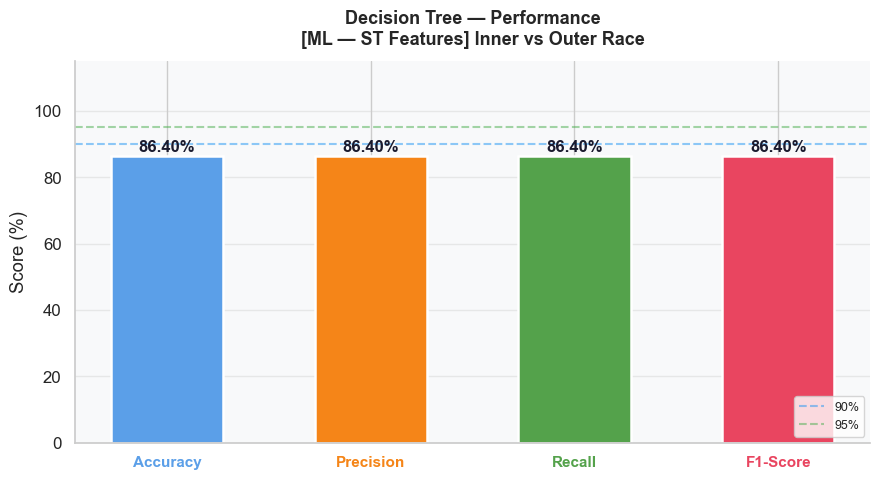

  ✅ Saved: ml_decision_tree_metrics.png


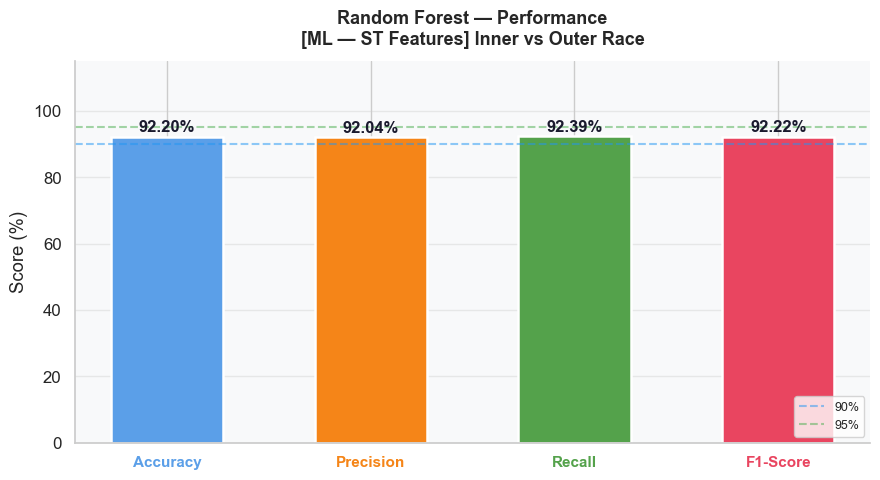

  ✅ Saved: ml_random_forest_metrics.png


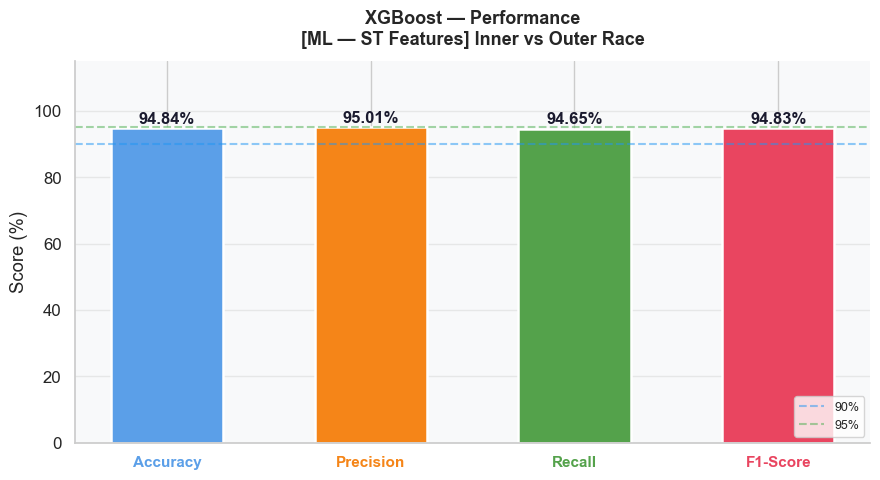

  ✅ Saved: ml_xgboost_metrics.png


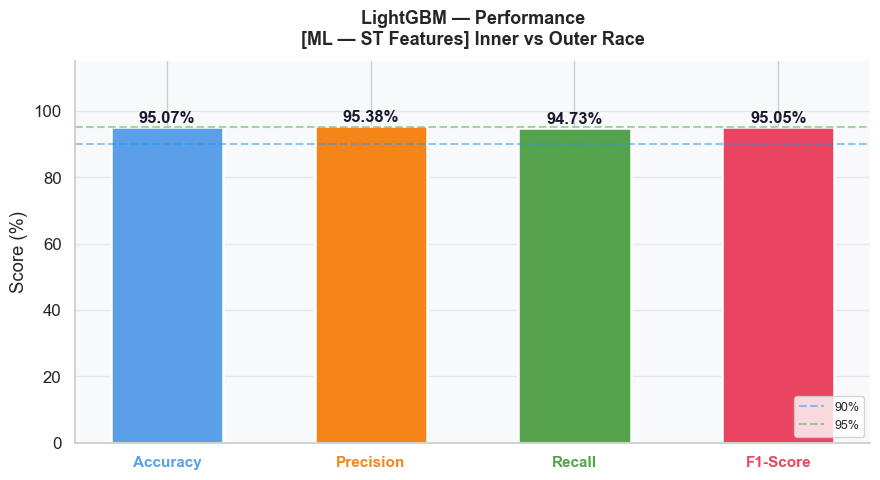

  ✅ Saved: ml_lightgbm_metrics.png


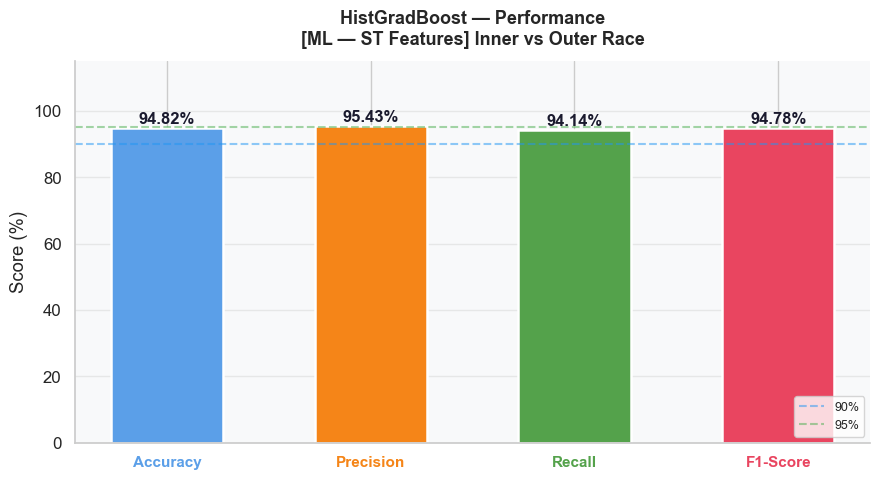

  ✅ Saved: ml_histgradboost_metrics.png


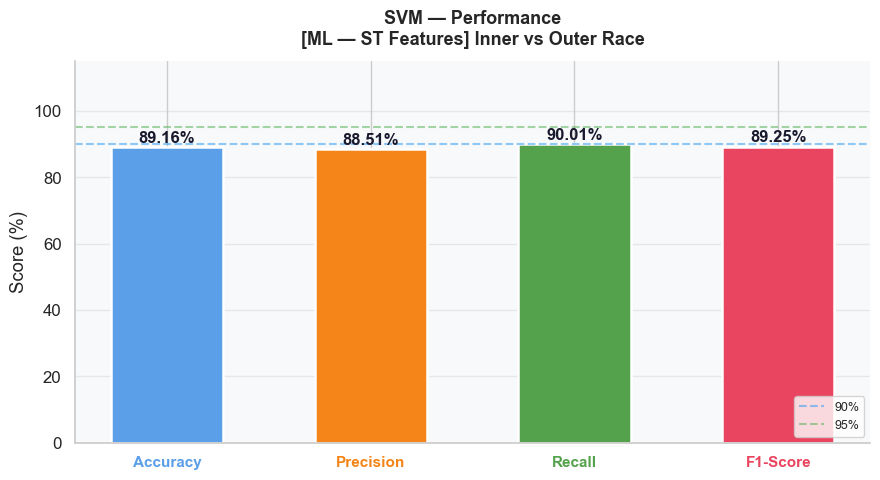

  ✅ Saved: ml_svm_metrics.png


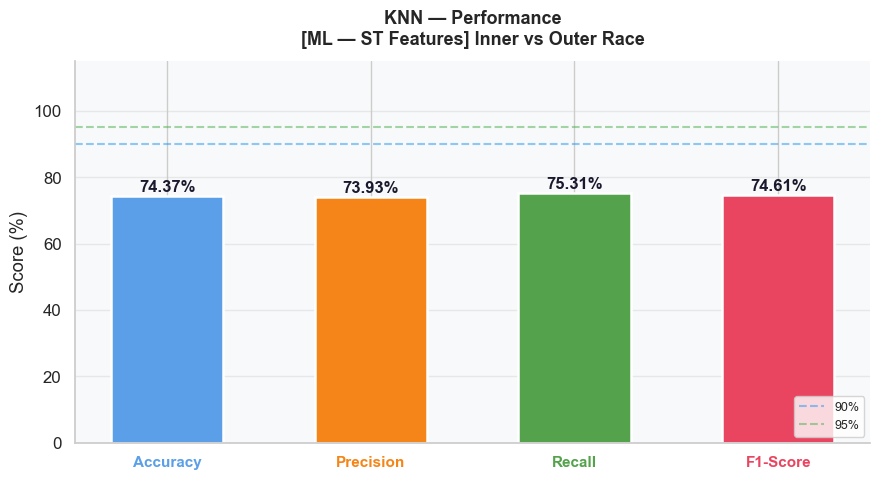

  ✅ Saved: ml_knn_metrics.png


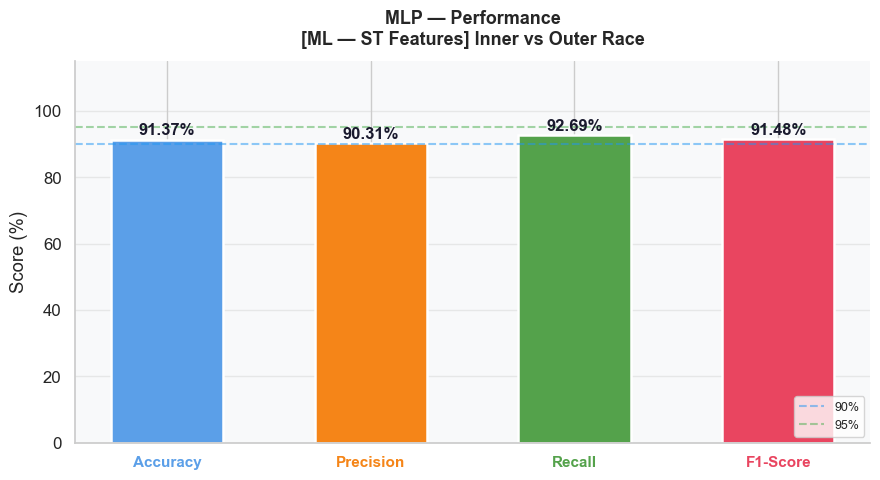

  ✅ Saved: ml_mlp_metrics.png


In [28]:
COLORS4  = ['#5B9FE8','#F58518','#54A24B','#E94560']
metrics4 = ['Accuracy','Precision','Recall','F1-Score']

for model_name in ml_df.index:
    row    = ml_df.loc[model_name]
    values = [row['Accuracy'],row['Precision'],row['Recall'],row['F1-Score']]

    fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
    ax.set_facecolor('#f8f9fa')
    bars = ax.bar(metrics4, values, color=COLORS4,
                  edgecolor='white', linewidth=1.8, width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.2f}%', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_title(f'{model_name} — Performance\n[ML — ST Features] Inner vs Outer Race',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Score (%)'); ax.set_ylim(0, 115)
    ax.axhline(90, color='#2196F3', linestyle='--', alpha=0.5, lw=1.5, label='90%')
    ax.axhline(95, color='#4CAF50', linestyle='--', alpha=0.5, lw=1.5, label='95%')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for tick, tc in zip(ax.get_xticklabels(), COLORS4):
        tick.set_color(tc); tick.set_fontweight('bold'); tick.set_fontsize(11)
    plt.tight_layout()
    fname = f'ml_{model_name.lower().replace(" ","_")}_metrics.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  ✅ Saved: {fname}')

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>8.2 Enhanced Confusion Matrices (3-Panel)</h3>

Generating 3-panel confusion matrices...


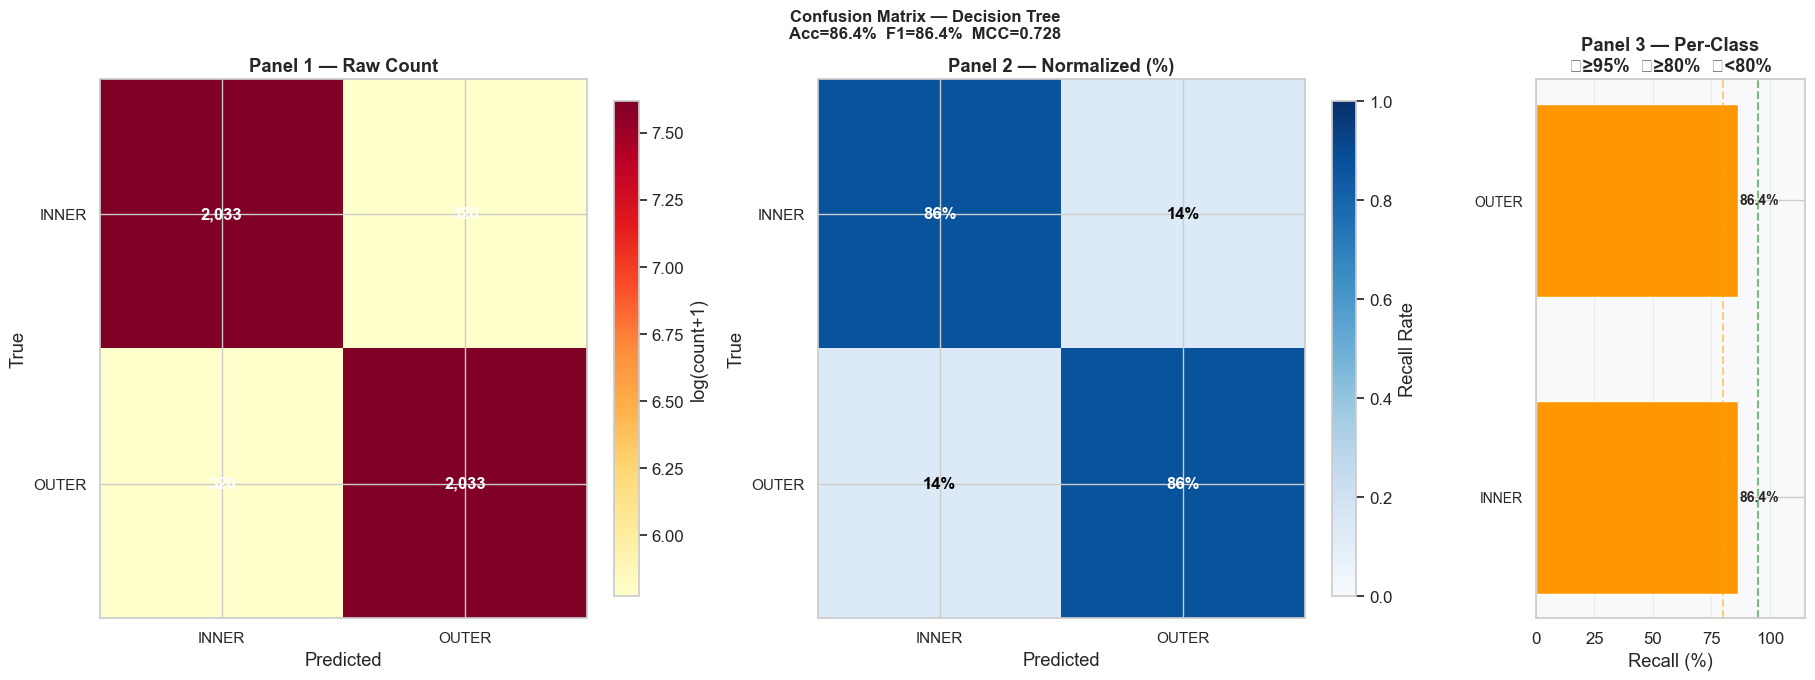

  ✅ Saved: cm_decision_tree.png


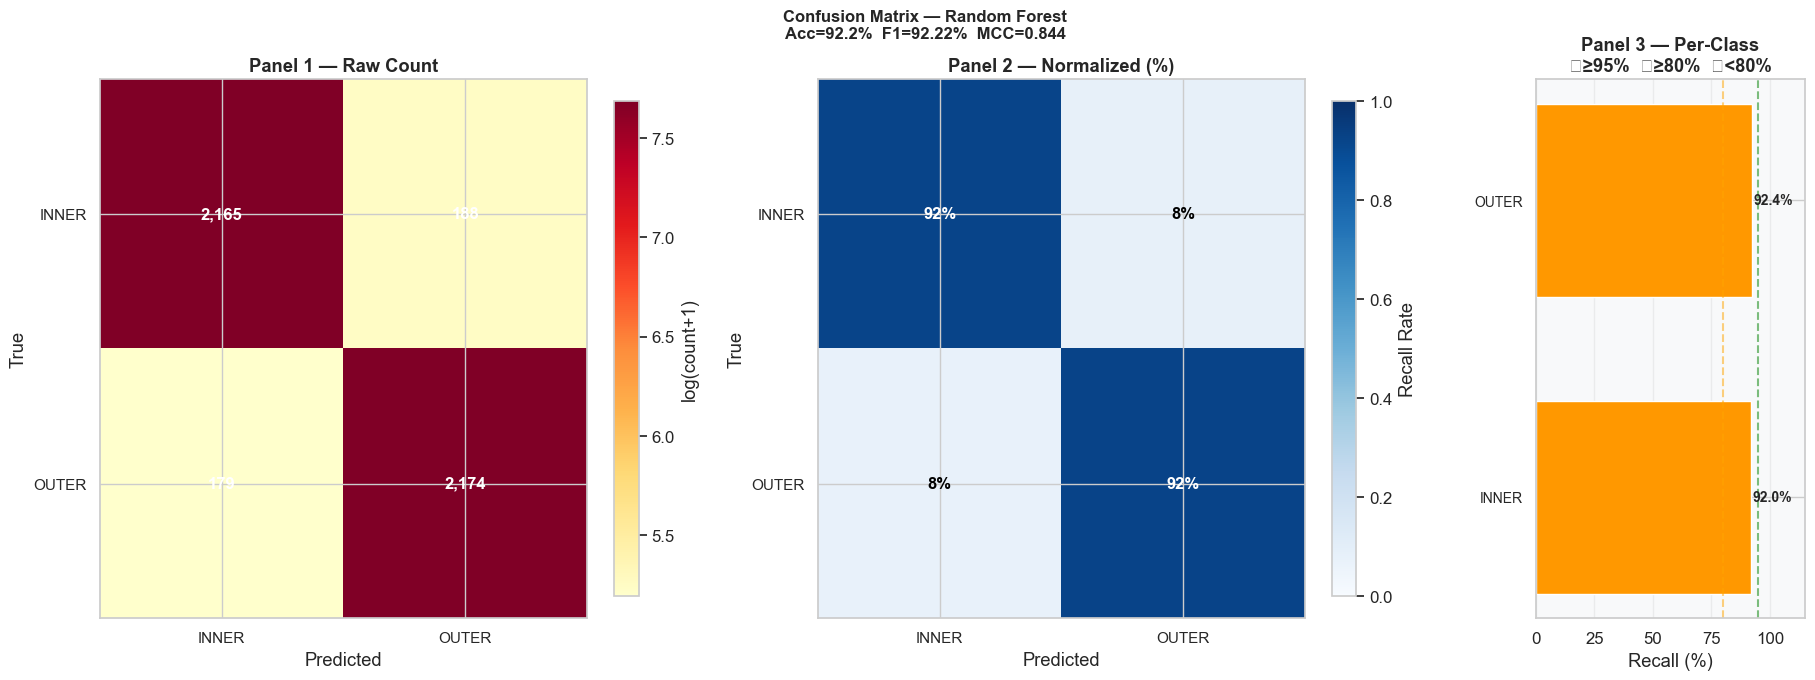

  ✅ Saved: cm_random_forest.png


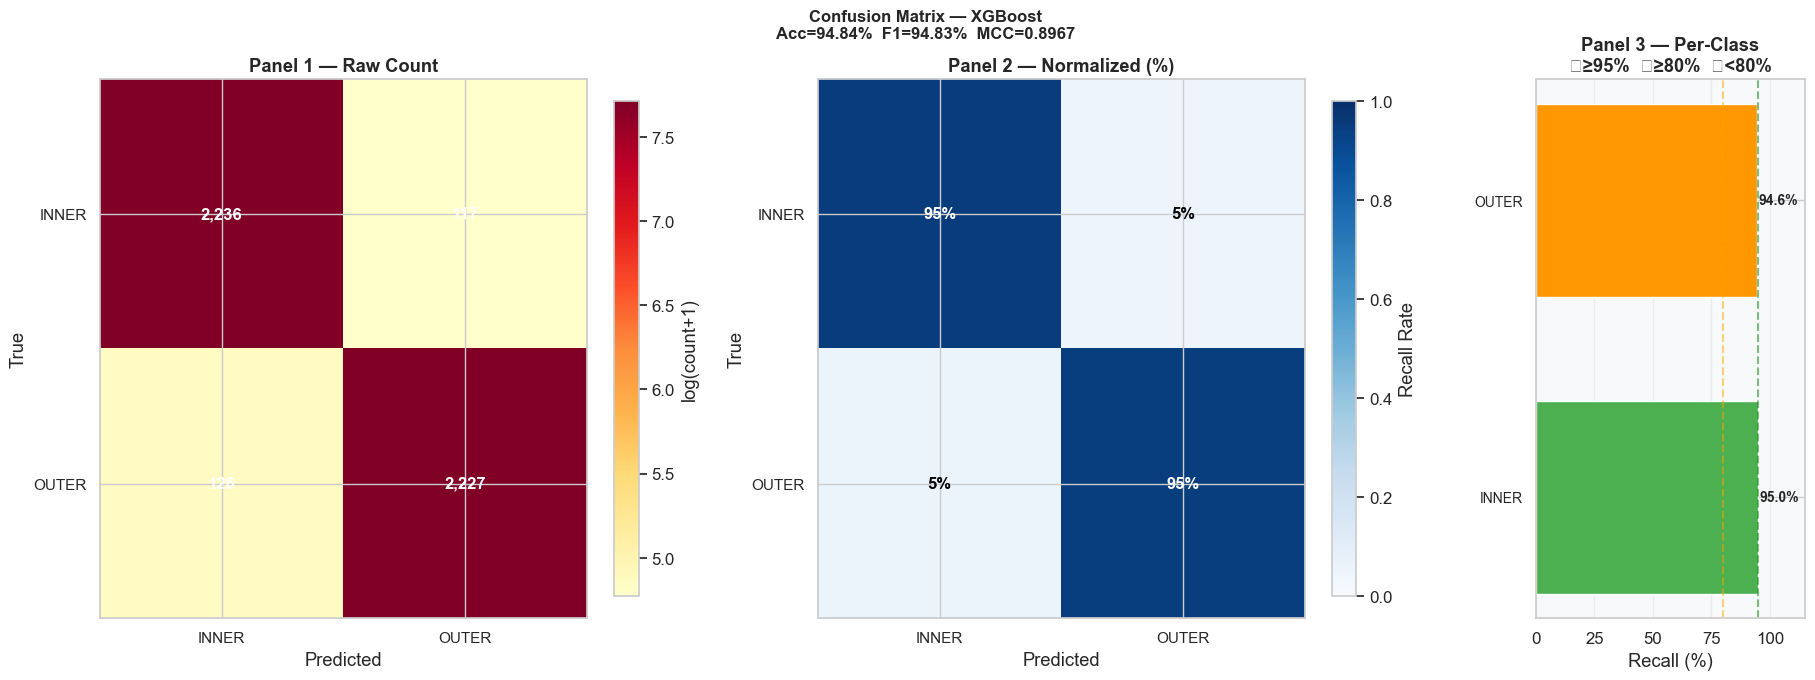

  ✅ Saved: cm_xgboost.png


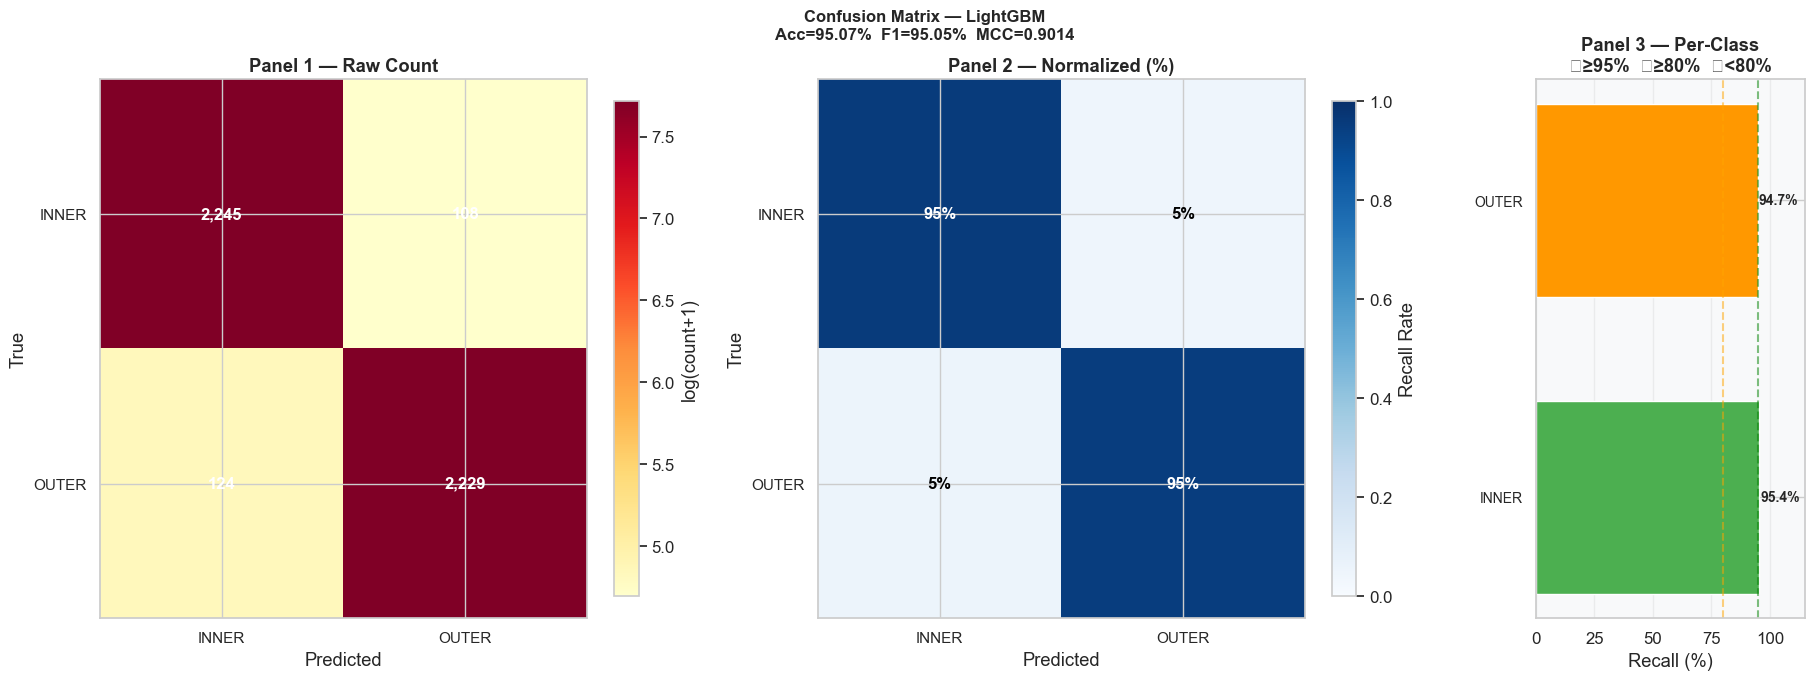

  ✅ Saved: cm_lightgbm.png


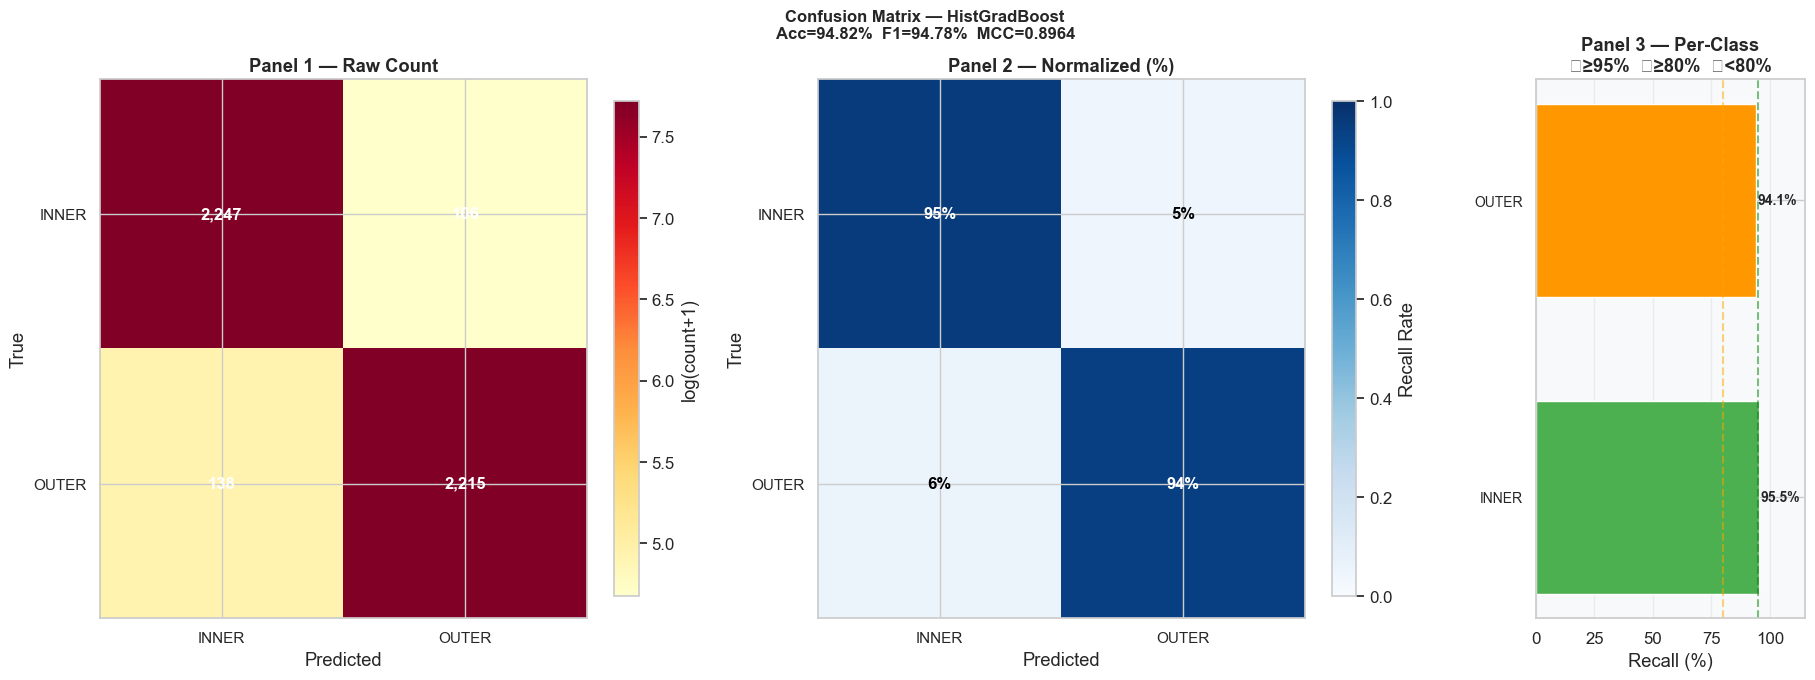

  ✅ Saved: cm_histgradboost.png


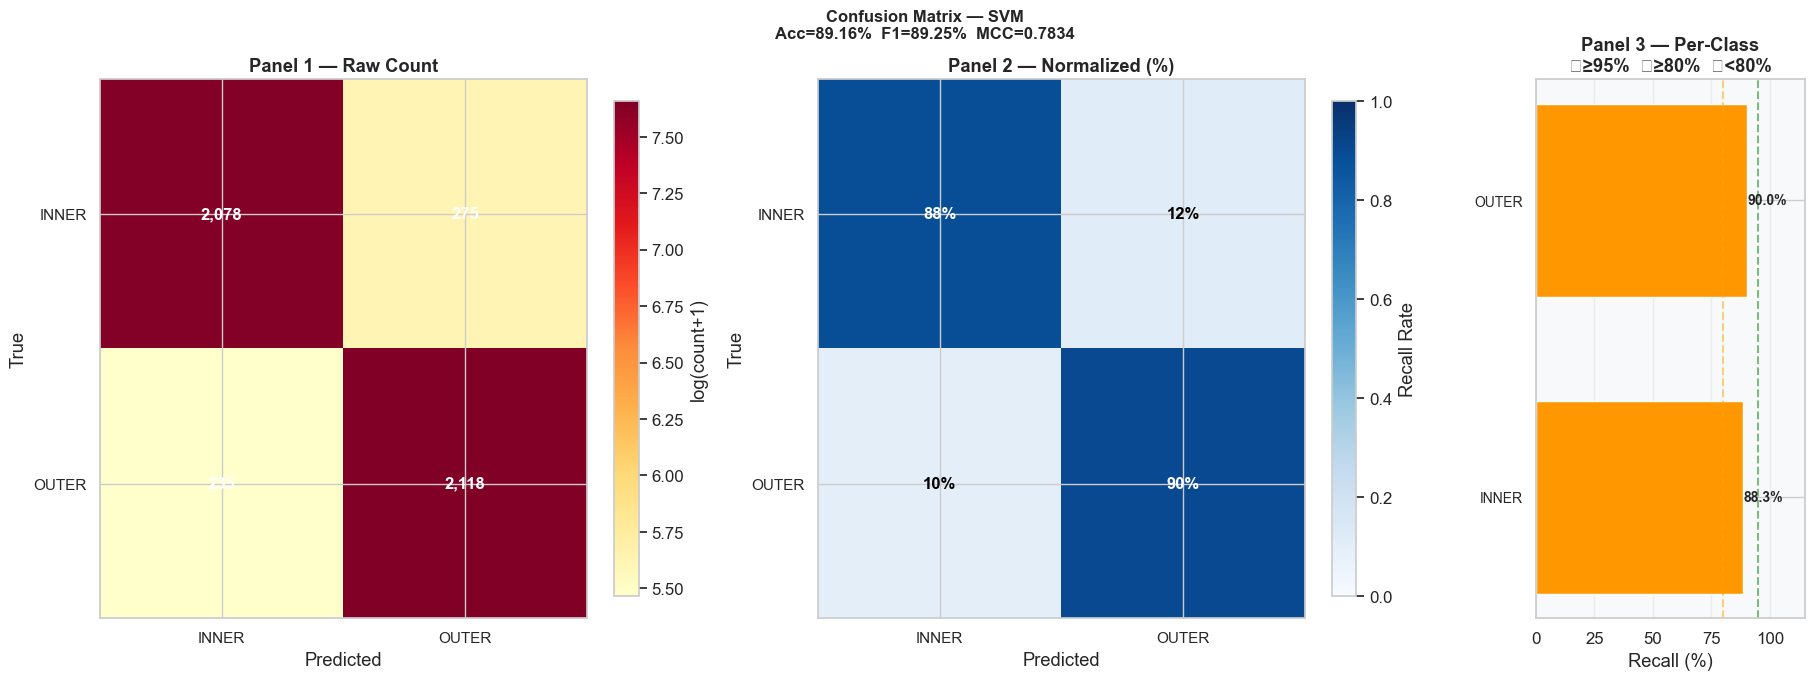

  ✅ Saved: cm_svm.png


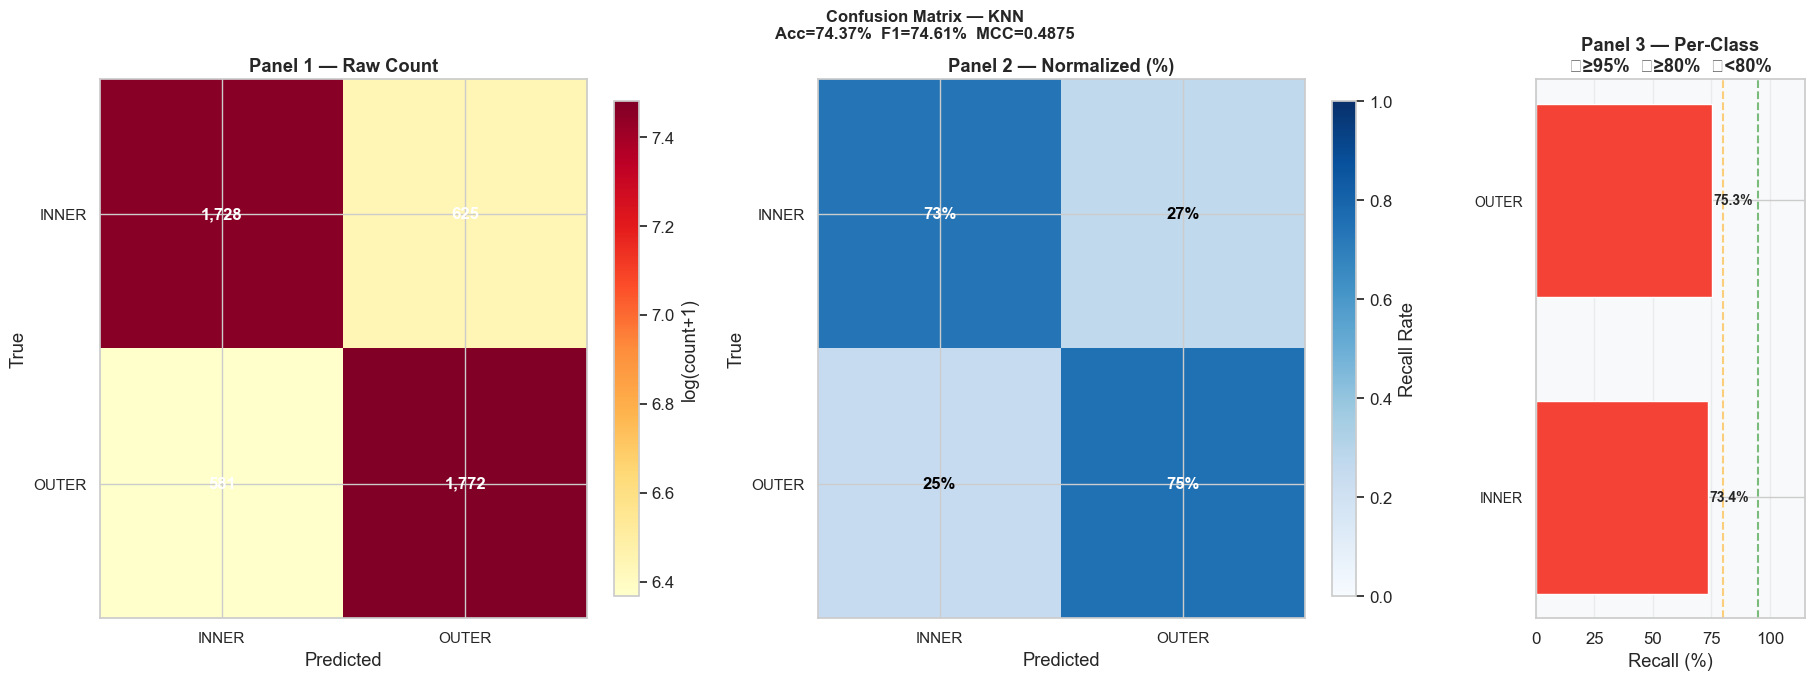

  ✅ Saved: cm_knn.png


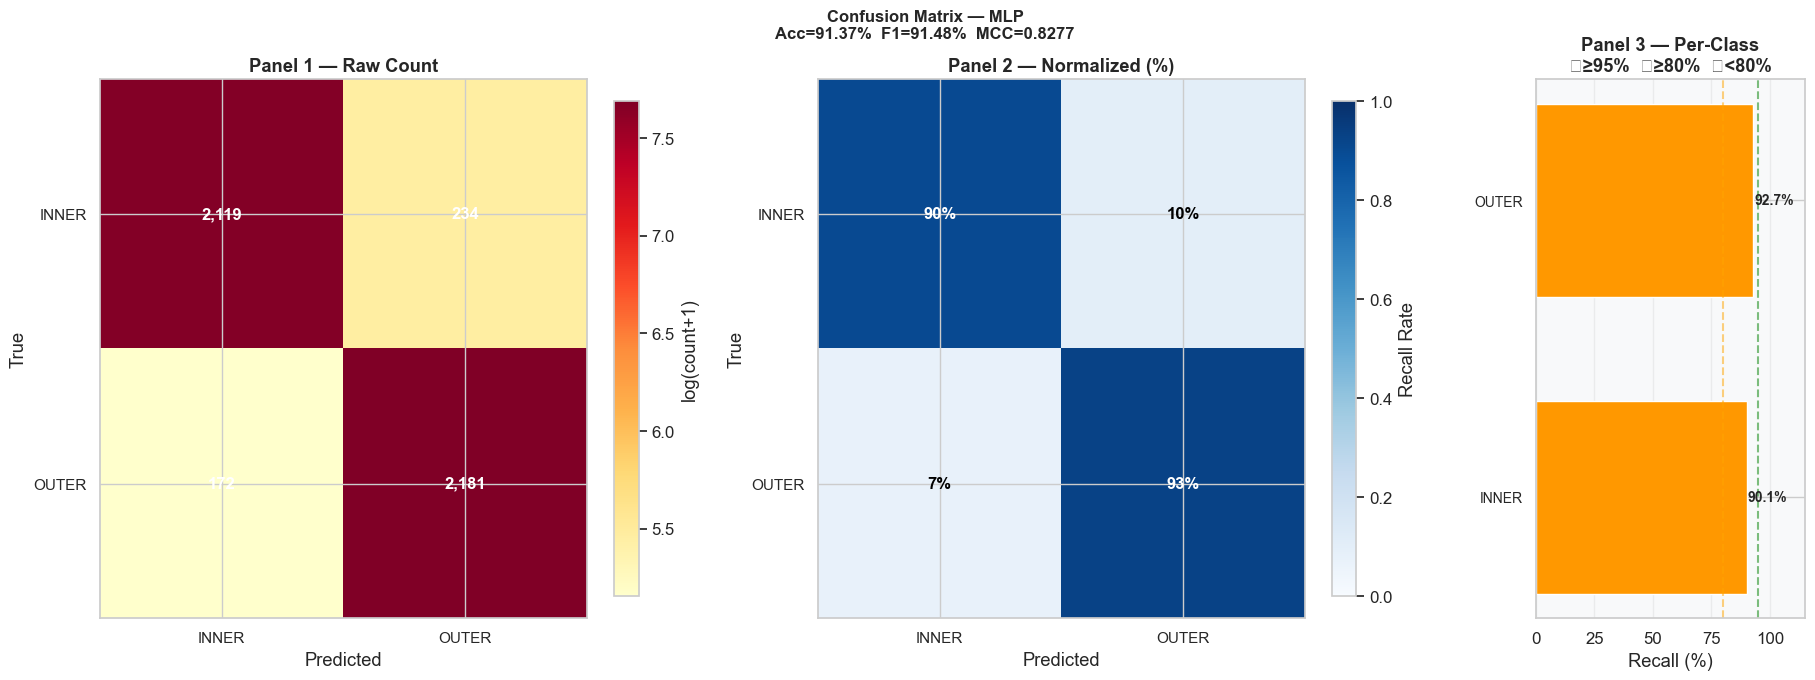

  ✅ Saved: cm_mlp.png


In [29]:
print('Generating 3-panel confusion matrices...')
CPLT = ['#2196F3','#F44336']

for name, yp in ml_preds.items():
    cm      = confusion_matrix(y_test, yp)
    n       = len(CLASSES)
    rs      = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(rs>0, cm.astype(float)/rs, 0)

    fig = plt.figure(figsize=(22, 7), facecolor='white')
    fig.suptitle(f'Confusion Matrix — {name}\n'
                 f'Acc={ml_results[name]["Accuracy"]}%  F1={ml_results[name]["F1-Score"]}%  MCC={ml_results[name]["MCC"]}',
                 fontsize=12, fontweight='bold')
    gs2 = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2,2,1], wspace=0.4)

    ax1 = fig.add_subplot(gs2[0]); ax1.set_facecolor('#f8f9fa')
    im1 = ax1.imshow(np.log1p(cm), cmap='YlOrRd', aspect='auto')
    plt.colorbar(im1, ax=ax1, fraction=0.046, label='log(count+1)')
    ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
    ax1.set_xticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax1.set_yticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
    ax1.set_title('Panel 1 — Raw Count', fontweight='bold')
    for i in range(n):
        for j in range(n):
            if cm[i,j]>0:
                bg = np.log1p(cm[i,j])/np.log1p(cm.max()+1)
                ax1.text(j,i,f'{cm[i,j]:,}',ha='center',va='center',
                         fontsize=12,fontweight='bold',
                         color='white' if bg>0.5 else 'black')

    ax2 = fig.add_subplot(gs2[1]); ax2.set_facecolor('#f8f9fa')
    im2 = ax2.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im2, ax=ax2, fraction=0.046, label='Recall Rate')
    ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
    ax2.set_xticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax2.set_yticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
    ax2.set_title('Panel 2 — Normalized (%)', fontweight='bold')
    for i in range(n):
        for j in range(n):
            if cm[i,j]>0:
                ax2.text(j,i,f'{cm_norm[i,j]*100:.0f}%',ha='center',va='center',
                         fontsize=12,fontweight='bold',
                         color='white' if cm_norm[i,j]>0.5 else 'black')

    ax3 = fig.add_subplot(gs2[2]); ax3.set_facecolor('#f8f9fa')
    recall  = np.diag(cm_norm)*100
    bar_c   = ['#4CAF50' if r>=95 else '#FF9800' if r>=80 else '#F44336' for r in recall]
    bars_r  = ax3.barh(range(n), recall, color=bar_c, edgecolor='white', height=0.65)
    for bar, val in zip(bars_r, recall):
        ax3.text(min(val+0.5,102), bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax3.set_yticks(range(n))
    ax3.set_yticklabels([c.upper() for c in CLASSES], fontsize=10)
    ax3.set_xlim(0,115); ax3.set_xlabel('Recall (%)')
    ax3.set_title('Panel 3 — Per-Class\n🟢≥95%  🟡≥80%  🔴<80%', fontweight='bold')
    ax3.axvline(95, color='green', linestyle='--', lw=1.5, alpha=0.5)
    ax3.axvline(80, color='orange', linestyle='--', lw=1.5, alpha=0.5)
    ax3.xaxis.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'cm_{name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  ✅ Saved: {fname}')

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>8.3 ROC Curves + Feature Importance</h3>

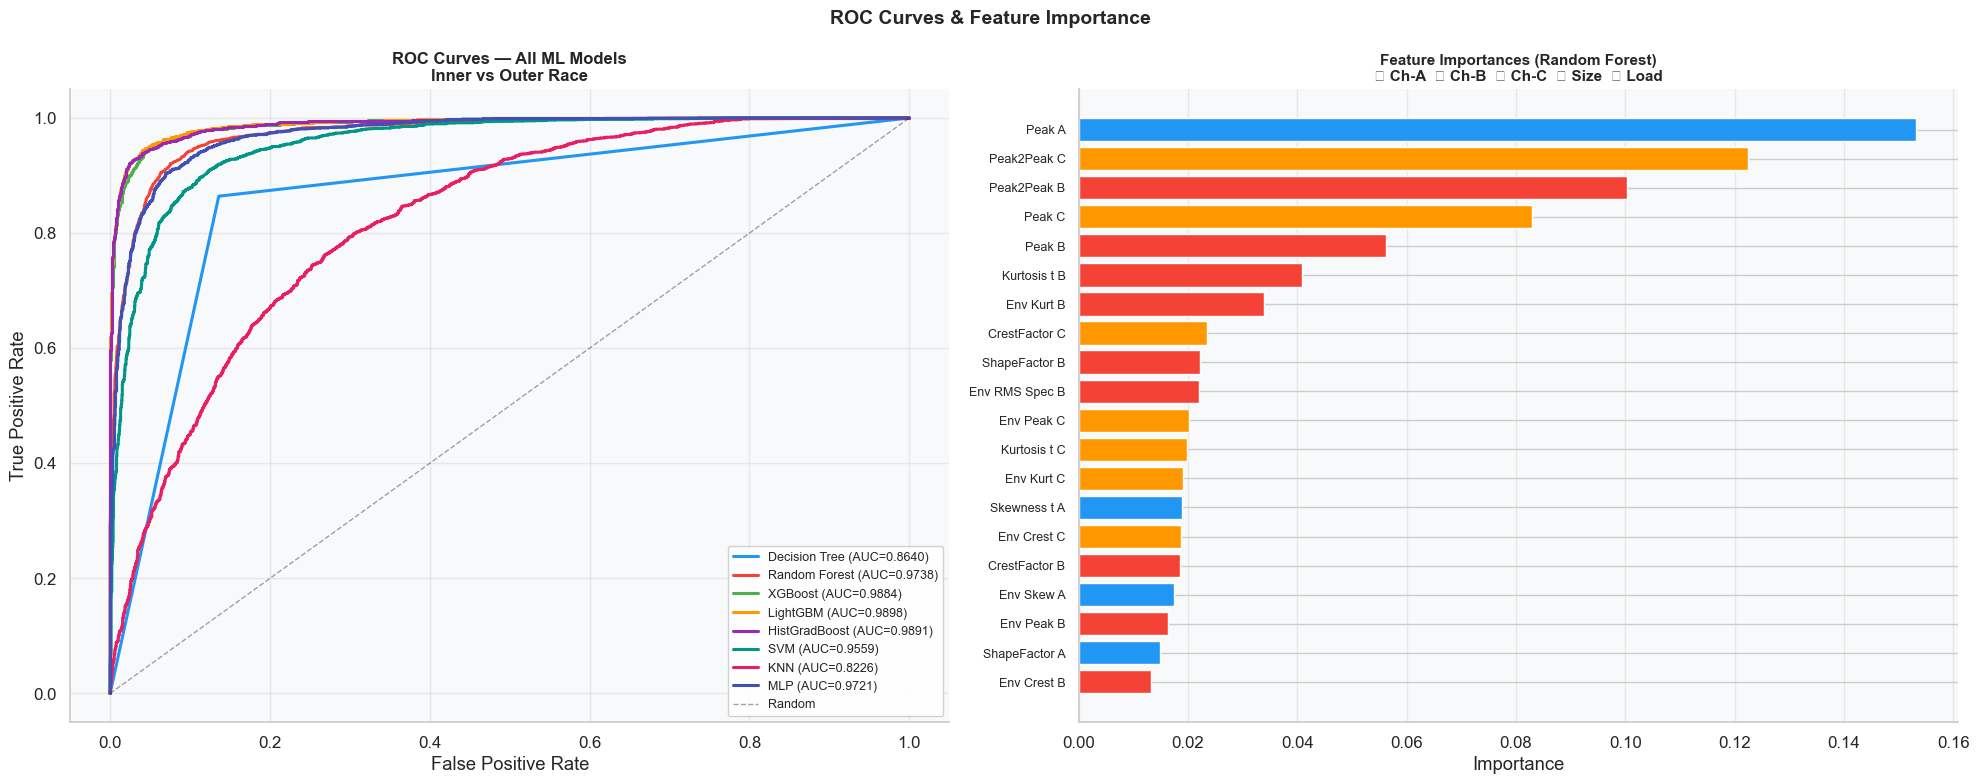

✅ Saved: 06_roc_importance.png


In [30]:
CPLT10 = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0',
          '#009688','#E91E63','#3F51B5']

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')

# ROC curves
ax = axes[0]; ax.set_facecolor('#f8f9fa')
for (name, prob), col in zip(ml_probs.items(), CPLT10):
    try:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc_v = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, color=col, linewidth=2.2,
                label=f'{name} (AUC={auc_v:.4f})')
    except: pass
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All ML Models\nInner vs Outer Race',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9, framealpha=0.9, loc='lower right')
ax.grid(True, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Feature importance (RF)
ax = axes[1]; ax.set_facecolor('#f8f9fa')
rf_fi = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_fi.fit(X_A_tr_raw, y_train)
imp   = pd.Series(rf_fi.feature_importances_, index=TOP_FEATS)
top20 = imp.nlargest(min(20, len(imp))).sort_values()
ch_cmap = {'A':'#2196F3','B':'#F44336','C':'#FF9800'}
meta_c  = {'Size':'#9C27B0','Load':'#009688'}
bar_c   = []
for f in top20.index:
    if f in META_FEAT: bar_c.append(meta_c.get(f,'#9E9E9E'))
    else:
        ch = f.split('_')[-1]
        bar_c.append(ch_cmap.get(ch,'#9E9E9E'))
ax.barh(range(len(top20)), top20.values, color=bar_c, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.replace('_',' ') for f in top20.index], fontsize=9)
ax.set_title('Feature Importances (Random Forest)\n'
              '🔵 Ch-A  🔴 Ch-B  🟠 Ch-C  🟣 Size  🟢 Load',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Importance'); ax.grid(True, axis='x', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('ROC Curves & Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_roc_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 06_roc_importance.png')

<a id='s9'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>🧠 9 | PATH B — DL Models</h2>

In [31]:
# Run this in a new cell to confirm:
print("Unique values in Current-A for inner 0.7mm 100W:")
subset = df_raw[(df_raw['Size']==0.7) & (df_raw['Load']==100) & (df_raw['Label']=='inner')]
print(f"  Unique Current-A values: {subset[' Current-A'].nunique()}")
print(f"  First 5 values: {subset[' Current-A'].head().values}")

print("\nUnique values in Current-A for outer 0.7mm 100W:")
subset2 = df_raw[(df_raw['Size']==0.7) & (df_raw['Load']==100) & (df_raw['Label']=='outer')]
print(f"  Unique Current-A values: {subset2[' Current-A'].nunique()}")

Unique values in Current-A for inner 0.7mm 100W:
  Unique Current-A values: 872
  First 5 values: [2.3309 2.3309 2.3309 2.3309 2.3309]

Unique values in Current-A for outer 0.7mm 100W:
  Unique Current-A values: 880


In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedShuffleSplit
tf.random.set_seed(42)

def predict_dl(model, X):
    prob = model.predict(X, verbose=0).flatten()
    return prob, (prob >= 0.5).astype(int)

def dl_metrics(name, yp, prob, t):
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, zero_division=0)
    rec  = recall_score(y_test, yp, zero_division=0)
    f1   = f1_score(y_test, yp, zero_division=0)
    mcc  = matthews_corrcoef(y_test, yp)
    try:   auc = roc_auc_score(y_test, prob)
    except: auc = 0.0
    ml_results[name] = {'Accuracy':round(acc*100,2),'Precision':round(prec*100,2),
                         'Recall':round(rec*100,2),'F1-Score':round(f1*100,2),
                         'MCC':round(mcc,4),'AUC-ROC':round(auc,4),'Time(s)':round(t,1)}
    ml_preds[name] = yp; ml_probs[name] = prob
    flag = '✅' if acc >= 0.90 else '⚠️'
    print(f'  {flag} {name:<16} Acc={acc*100:.2f}%  F1={f1*100:.2f}%  '
          f'MCC={mcc:.4f}  AUC={auc:.4f}  ({t:.0f}s)')

# ── Stratified val split from feature matrix ─────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
tr_idx_dl, val_idx_dl = next(sss.split(X_B_tr, y_train))

X_dl_tr  = X_B_tr[tr_idx_dl];   y_dl_tr = y_train[tr_idx_dl]
X_dl_val = X_B_tr[val_idx_dl];  y_dl_val = y_train[val_idx_dl]

print(f'DL input — engineered feature matrix ({N_FEATURES} features):')
print(f'  Fit  : {X_dl_tr.shape}  inner={int((y_dl_tr==0).sum())} outer={int((y_dl_tr==1).sum())}')
print(f'  Val  : {X_dl_val.shape}  inner={int((y_dl_val==0).sum())} outer={int((y_dl_val==1).sum())}')
print(f'  Test : {X_B_te.shape}')

DL_CB = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=8,
        factor=0.5, min_lr=1e-6, verbose=0)
]
print('✅ DL setup complete')


DL input — engineered feature matrix (74 features):
  Fit  : (16938, 74)  inner=8469 outer=8469
  Val  : (1882, 74)  inner=941 outer=941
  Test : (4706, 74)
✅ DL setup complete


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>9.1 1D CNN (STFT input — frequency-aware)</h3>

In [33]:
print('Training DNN on engineered features...')


keras.backend.clear_session()
tf.random.set_seed(42)

inp_dnn = keras.Input(shape=(N_FEATURES,))

x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(inp_dnn)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.25)(x)

x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)

out_dnn = layers.Dense(1, activation='sigmoid')(x)

dnn = keras.Model(inp_dnn, out_dnn)
dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'])
dnn.summary()

t0    = time.time()
dnn_h = dnn.fit(
    X_dl_tr, y_dl_tr,
    epochs=150,
    batch_size=256,
    validation_data=(X_dl_val, y_dl_val),
    callbacks=DL_CB,
    shuffle=True,
    verbose=1)
dnn_t = time.time() - t0

dnn_prob, dnn_pred = predict_dl(dnn, X_B_te)
dl_metrics('DNN', dnn_pred, dnn_prob, dnn_t)
print(f'  Stopped at epoch : {len(dnn_h.history["accuracy"])}')
print(f'  Best val_acc     : {max(dnn_h.history["val_accuracy"])*100:.2f}%')


Training DNN on engineered features...



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 74)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,025 (504.00 KB)

 Trainable params: 127,617 (498.50 KB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.6791 - loss: 0.6561 - val_accuracy: 0.7545 - val_loss: 0.5740 - learning_rate: 0.0010
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7882 - loss: 0.5151 - val_accuracy: 0.8454 - val_loss: 0.4353 - learning_rate: 0.0010
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8456 - loss: 0.4208 - val_accuracy: 0.8714 - val_loss: 0.3739 - learning_rate: 0.0010
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8713 - loss: 0.3673 - val_accuracy: 0.8842 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8829 - loss: 0.3385 - val_accuracy: 0.9001 - val_loss: 0.3031 - learning_rate: 0.0010
Epoch 6/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8967 - loss: 0.3116 - val_accuracy: 0.9208 - val_loss: 0.2681 - learning_rate: 0.0010
Epoch 7/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9032 - loss: 0.2934 -

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>9.2 LSTM (STFT input — frequency-aware)</h3>

In [39]:
print('Training LSTM on engineered features...')

keras.backend.clear_session()
tf.random.set_seed(42)

# ── CORRECT APPROACH: group 74 features into 3 channels × 24 timesteps ──
# Instead of (N, 74, 1) — 74 meaningless "timesteps" —
# reshape to (N, 24, 3): 24 features per channel, 3 channels as sequence.
# The LSTM now reads: timestep 0 = [RMS_A, RMS_B, RMS_C],
#                     timestep 1 = [Peak_A, Peak_B, Peak_C], etc.
# This gives the LSTM a physically meaningful sequence:
# each step = one feature measured across all 3 current phases.
# The model learns inter-phase relationships at each feature level.

N_FEAT_PER_CH = 24   # 8 time + 8 freq + 8 envelope features per channel
N_CH          = 3

def reshape_for_lstm(X):
    # X: (N, 74) where last 2 are meta (Size, Load)
    # Take first 72 features (24 per channel × 3 channels)
    X_sig  = X[:, :N_FEAT_PER_CH * N_CH]    # (N, 72)
    X_meta = X[:, N_FEAT_PER_CH * N_CH:]    # (N, 2)
    # Reshape: (N, 72) → (N, 24, 3)
    X_seq  = X_sig.reshape(-1, N_FEAT_PER_CH, N_CH)
    return X_seq, X_meta

X_seq_tr,  X_meta_tr  = reshape_for_lstm(X_dl_tr)
X_seq_val, X_meta_val = reshape_for_lstm(X_dl_val)
X_seq_te,  X_meta_te  = reshape_for_lstm(X_B_te)

print(f'  LSTM sequence input : {X_seq_tr.shape}  (N × 24 features × 3 channels)')
print(f'  Meta input          : {X_meta_tr.shape}  (Size, Load)')

# ── Dual-input model: LSTM on feature sequence + Dense on meta ──
inp_seq  = keras.Input(shape=(N_FEAT_PER_CH, N_CH), name='feature_seq')
inp_meta = keras.Input(shape=(2,),                  name='meta')

# LSTM branch
x_l = layers.LSTM(64, return_sequences=True, dropout=0.2)(inp_seq)
x_l = layers.LayerNormalization()(x_l)
x_l = layers.LSTM(32, return_sequences=False, dropout=0.2)(x_l)
x_l = layers.LayerNormalization()(x_l)
x_l = layers.Dropout(0.25)(x_l)

# Meta branch
x_m = layers.Dense(8, activation='relu')(inp_meta)

# Merge
x = layers.Concatenate()([x_l, x_m])
x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.15)(x)
out_l = layers.Dense(1, activation='sigmoid')(x)

lstm_model = keras.Model([inp_seq, inp_meta], out_l)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy'])
lstm_model.summary()

DL_CB_LSTM = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=8,
        factor=0.5, min_lr=1e-6, verbose=0)
]

t0     = time.time()
lstm_h = lstm_model.fit(
    [X_seq_tr, X_meta_tr], y_dl_tr,
    epochs=150,
    batch_size=256,
    validation_data=([X_seq_val, X_meta_val], y_dl_val),
    callbacks=DL_CB_LSTM,
    shuffle=True,
    verbose=1)
lstm_t = time.time() - t0

lstm_prob = lstm_model.predict([X_seq_te, X_meta_te], verbose=0).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)
dl_metrics('LSTM', lstm_pred, lstm_prob, lstm_t)
print(f'  Stopped at epoch : {len(lstm_h.history["accuracy"])}')
print(f'  Best val_acc     : {max(lstm_h.history["val_accuracy"])*100:.2f}%')

Training LSTM on engineered features...
  LSTM sequence input : (16938, 24, 3)  (N × 24 features × 3 channels)
  Meta input          : (16938, 2)  (Size, Load)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ feature_seq (InputLayer)      │ (None, 24, 3)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 24, 64)            │          17,408 │ feature_seq[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 24, 64)            │             128 │ lstm[0][0]                 │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 32)                │          12,416 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 32)                │              64 │ lstm_1[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ meta (InputLayer)             │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 32)                │               0 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 8)                 │              24 │ meta[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 40)                │               0 │ dropout[0][0], dense[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           2,624 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 64)                │             256 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 64)                │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 32)                │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              3

 Total params: 35,033 (136.85 KB)

 Trainable params: 34,905 (136.35 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - accuracy: 0.5606 - loss: 0.6965 - val_accuracy: 0.5962 - val_loss: 0.6480 - learning_rate: 0.0010
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 143ms/step - accuracy: 0.5904 - loss: 0.6600 - val_accuracy: 0.6403 - val_loss: 0.6224 - learning_rate: 0.0010
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.6198 - loss: 0.6403 - val_accuracy: 0.6711 - val_loss: 0.6077 - learning_rate: 0.0010
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.6366 - loss: 0.6296 - val_accuracy: 0.6780 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.6483 - loss: 0.6228 - val_accuracy: 0.6945 - val_loss: 0.5885 - learning_rate: 0.0010
Epoch 6/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.6574 - loss: 0.6110 - val_accuracy: 0.6934 - val_loss: 0.5817 - learning_rate: 0.0010
Epoch 7/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.6632 - l

<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>9.3 DL Confusion Matrices + Training Curves</h3>

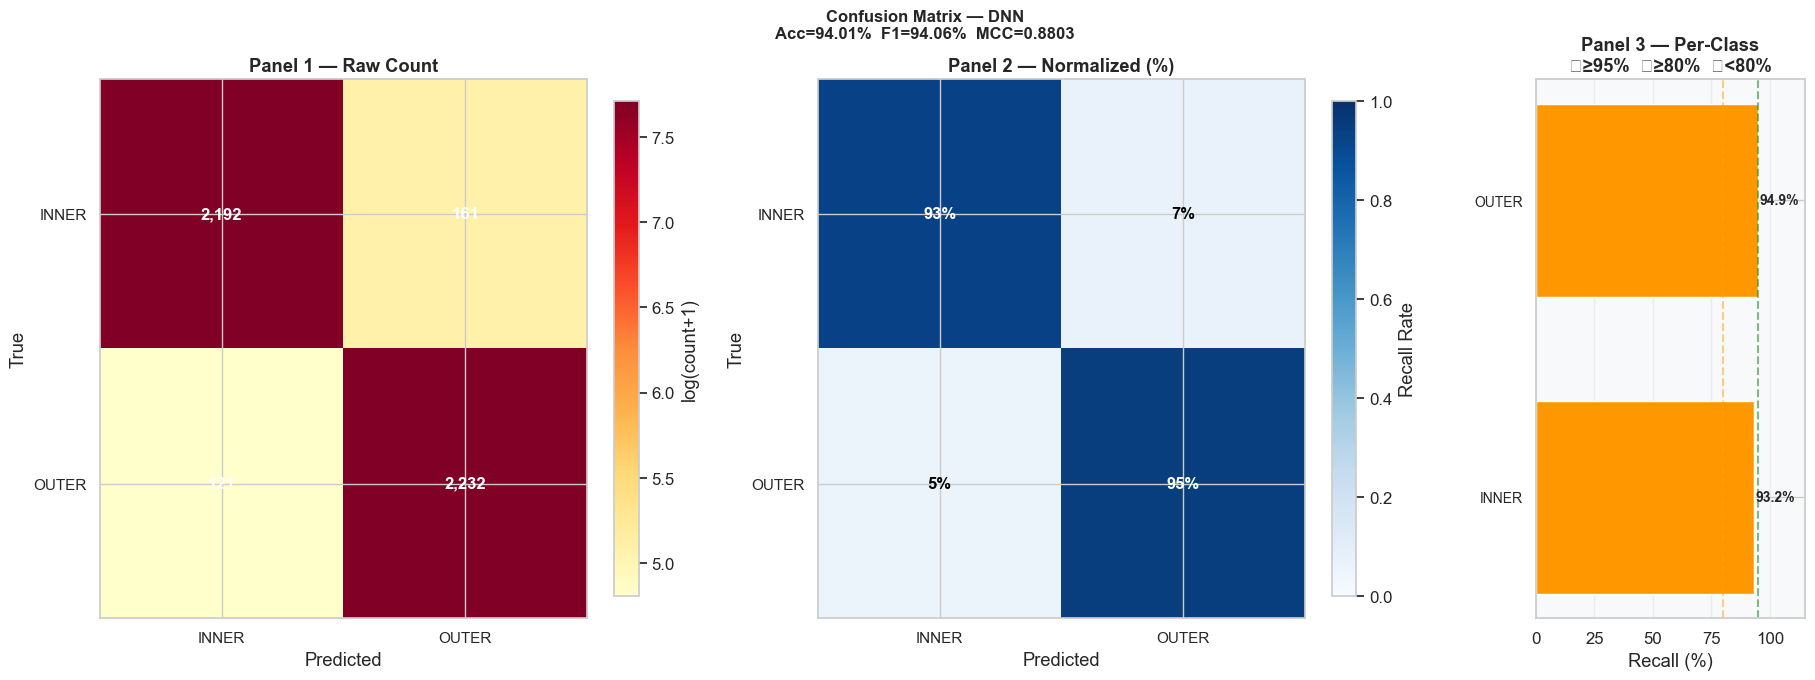

  ✅ Saved: cm_dl_dnn.png


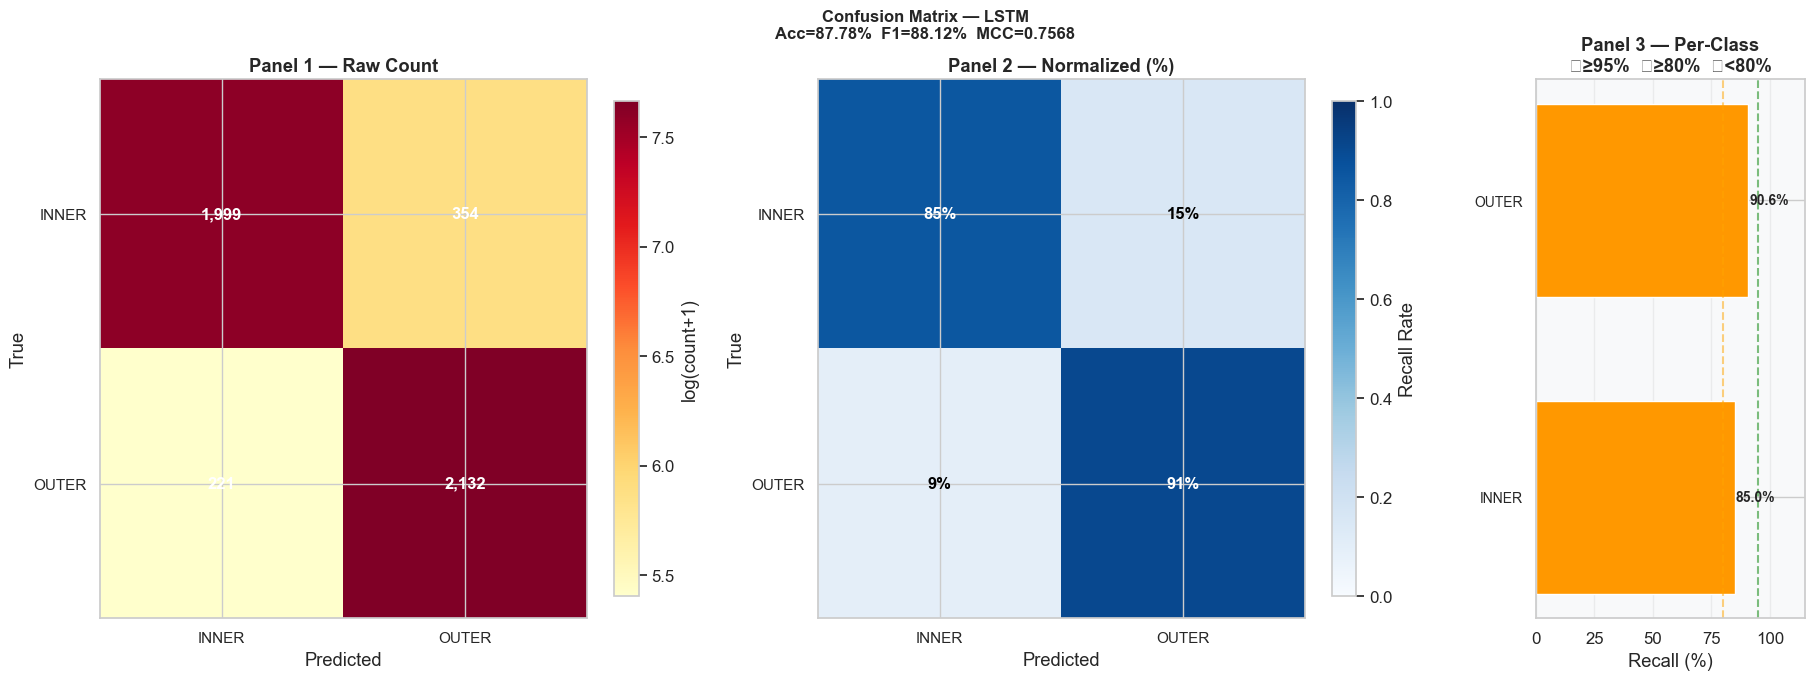

  ✅ Saved: cm_dl_lstm.png


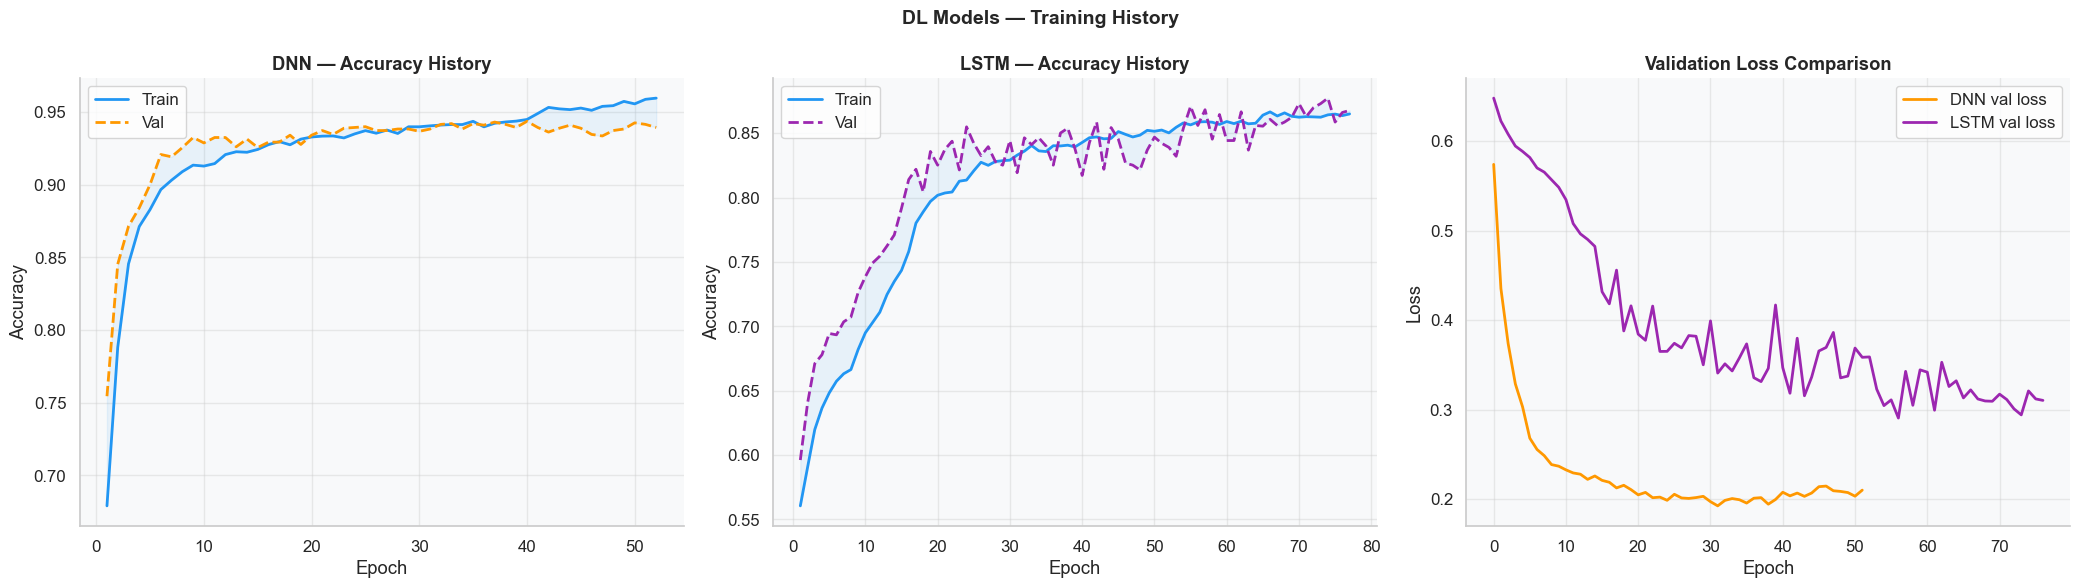

✅ Saved: 07_dl_training.png


In [44]:
CPLT = ['#2196F3','#F44336']
DL_HIST_LIST = [
    ('DNN', dnn_pred, dnn_prob, dnn_h, '#FF9800'),
    ('LSTM', lstm_pred, lstm_prob, lstm_h, '#9C27B0')
]

for name, yp, prob, hist, col in DL_HIST_LIST:
    cm      = confusion_matrix(y_test, yp)
    n       = len(CLASSES)
    rs      = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(rs>0, cm.astype(float)/rs, 0)

    fig = plt.figure(figsize=(22, 7), facecolor='white')
    fig.suptitle(f'Confusion Matrix — {name}\n'
                 f'Acc={ml_results[name]["Accuracy"]}%  F1={ml_results[name]["F1-Score"]}%  MCC={ml_results[name]["MCC"]}',
                 fontsize=12, fontweight='bold')
    gs3 = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2,2,1], wspace=0.4)

    ax1 = fig.add_subplot(gs3[0]); ax1.set_facecolor('#f8f9fa')
    im1 = ax1.imshow(np.log1p(cm), cmap='YlOrRd', aspect='auto')
    plt.colorbar(im1, ax=ax1, fraction=0.046, label='log(count+1)')
    ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
    ax1.set_xticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax1.set_yticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
    ax1.set_title('Panel 1 — Raw Count', fontweight='bold')
    for i in range(n):
        for j in range(n):
            if cm[i,j]>0:
                bg = np.log1p(cm[i,j])/np.log1p(cm.max()+1)
                ax1.text(j,i,f'{cm[i,j]:,}',ha='center',va='center',
                         fontsize=12,fontweight='bold',
                         color='white' if bg>0.5 else 'black')

    ax2 = fig.add_subplot(gs3[1]); ax2.set_facecolor('#f8f9fa')
    im2 = ax2.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im2, ax=ax2, fraction=0.046, label='Recall Rate')
    ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
    ax2.set_xticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax2.set_yticklabels([c.upper() for c in CLASSES], fontsize=11)
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
    ax2.set_title('Panel 2 — Normalized (%)', fontweight='bold')
    for i in range(n):
        for j in range(n):
            if cm[i,j]>0:
                ax2.text(j,i,f'{cm_norm[i,j]*100:.0f}%',ha='center',va='center',
                         fontsize=12,fontweight='bold',
                         color='white' if cm_norm[i,j]>0.5 else 'black')

    ax3 = fig.add_subplot(gs3[2]); ax3.set_facecolor('#f8f9fa')
    recall  = np.diag(cm_norm)*100
    bar_c   = ['#4CAF50' if r>=95 else '#FF9800' if r>=80 else '#F44336' for r in recall]
    bars_r  = ax3.barh(range(n), recall, color=bar_c, edgecolor='white', height=0.65)
    for bar, val in zip(bars_r, recall):
        ax3.text(min(val+0.5,102), bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%',va='center',fontsize=10,fontweight='bold')
    ax3.set_yticks(range(n))
    ax3.set_yticklabels([c.upper() for c in CLASSES], fontsize=10)
    ax3.set_xlim(0,115); ax3.set_xlabel('Recall (%)')
    ax3.set_title('Panel 3 — Per-Class\n🟢≥95%  🟡≥80%  🔴<80%', fontweight='bold')
    ax3.axvline(95, color='green', linestyle='--', lw=1.5, alpha=0.5)
    ax3.axvline(80, color='orange', linestyle='--', lw=1.5, alpha=0.5)
    ax3.xaxis.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'cm_dl_{name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  ✅ Saved: {fname}')

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(21, 6), facecolor='white')
for ax, (name, _, _, hist, col) in zip(axes[:2], DL_HIST_LIST):
    ax.set_facecolor('#f8f9fa')
    ep = range(1, len(hist.history['accuracy'])+1)
    ax.plot(ep, hist.history['accuracy'],     color='#2196F3', lw=2, label='Train')
    ax.plot(ep, hist.history['val_accuracy'], color=col, lw=2, label='Val', ls='--')
    ax.fill_between(ep, hist.history['accuracy'],
                     hist.history['val_accuracy'], alpha=0.08, color='#2196F3')
    ax.set_title(f'{name} — Accuracy History', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[2]; ax.set_facecolor('#f8f9fa')
for (name, _, _, hist, col) in DL_HIST_LIST:
    ax.plot(hist.history['val_loss'], color=col, lw=2, label=f'{name} val loss')
ax.set_title('Validation Loss Comparison', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('DL Models — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_dl_training.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 07_dl_training.png')

<a id='s10'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#533483);border-radius:8px;border-left:5px solid #e94560;'>🏆 10 | Final Summary — All Models</h2>

═══════════════════════════════════════════════════════════════════════════════════════════════
FINAL RESULTS — Inner vs Outer Race Bearing Fault Classification
Dataset: 23,526 windows | 30 ST features + Size + Load | Binary
═══════════════════════════════════════════════════════════════════════════════════════════════
  Model              Type                Acc     Prec      Rec       F1      MCC      AUC
───────────────────────────────────────────────────────────────────────────────────────────────
✅ LightGBM         ML (ST feat)     95.07%   95.38%   94.73%   95.05%    0.9014  0.9898
✅ XGBoost          ML (ST feat)     94.84%   95.01%   94.65%   94.83%    0.8967  0.9884
✅ HistGradBoost    ML (ST feat)     94.82%   95.43%   94.14%   94.78%    0.8964  0.9891
✅ DNN              DL (STFT)        94.01%   93.27%   94.86%   94.06%    0.8803  0.9865
✅ Random Forest    ML (ST feat)      92.2%   92.04%   92.39%   92.22%    0.8440  0.9738
✅ MLP              ML (ST feat)     91.37%   90.31%  

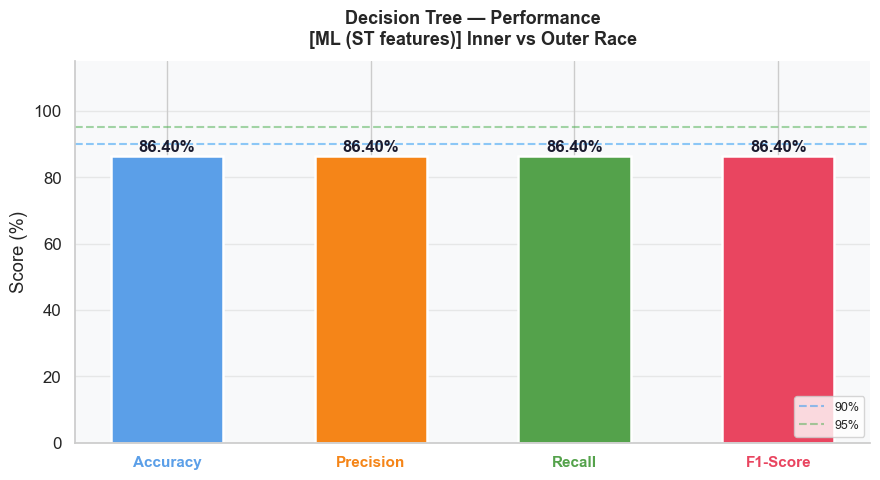

  ✅ Saved: metrics_decision_tree.png


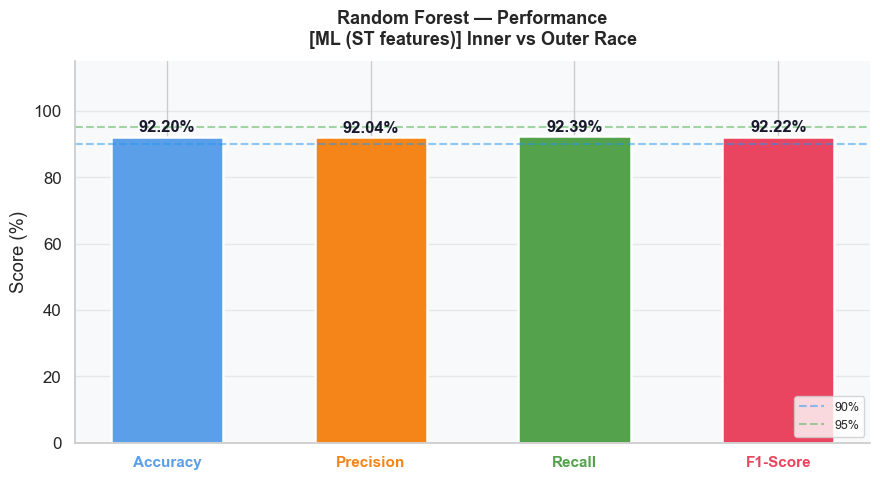

  ✅ Saved: metrics_random_forest.png


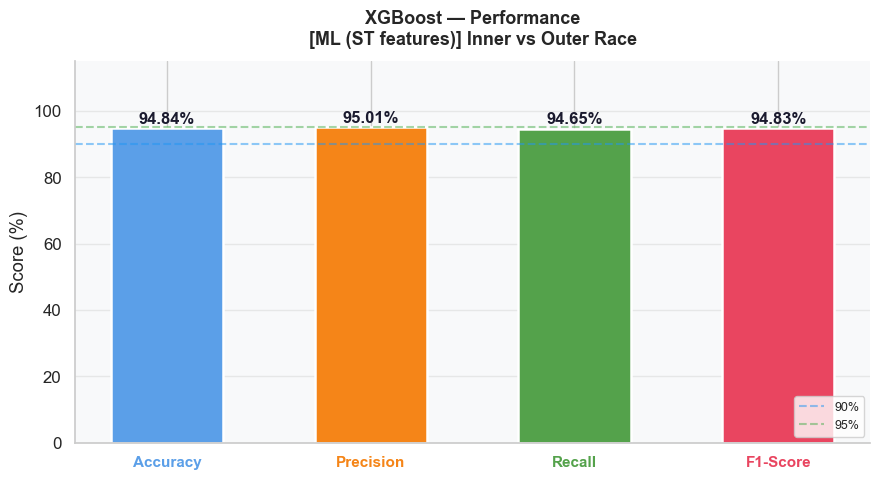

  ✅ Saved: metrics_xgboost.png


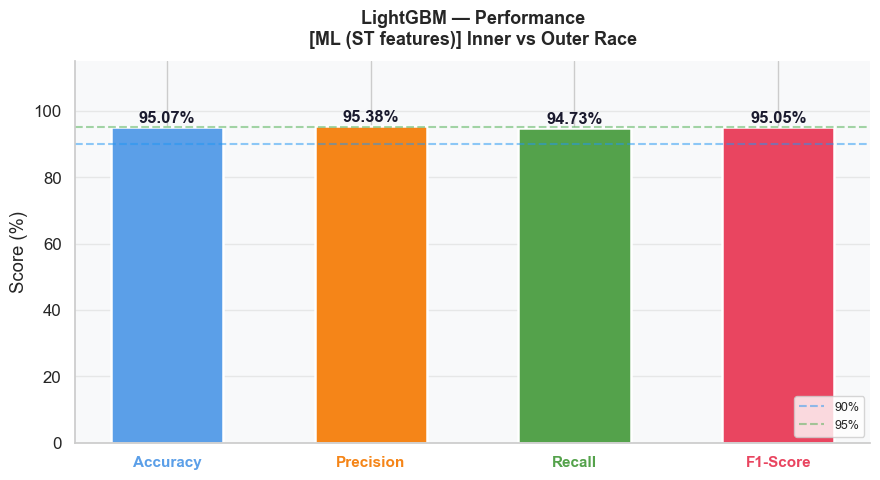

  ✅ Saved: metrics_lightgbm.png


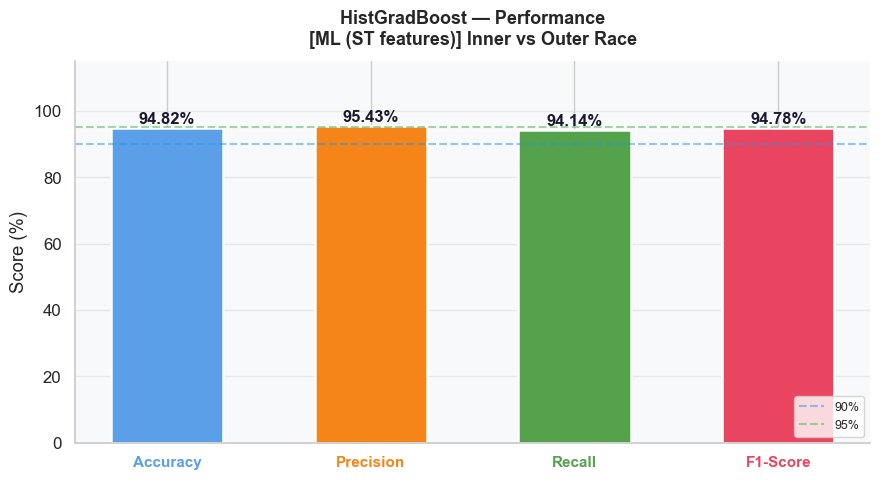

  ✅ Saved: metrics_histgradboost.png


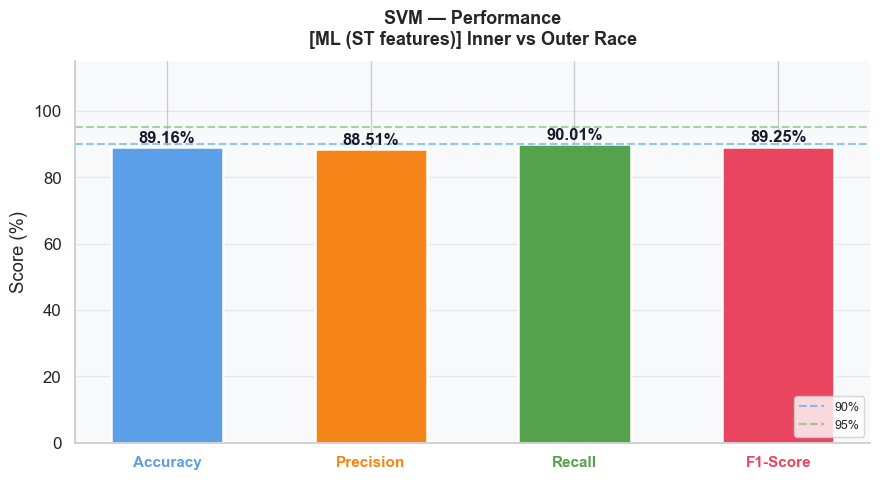

  ✅ Saved: metrics_svm.png


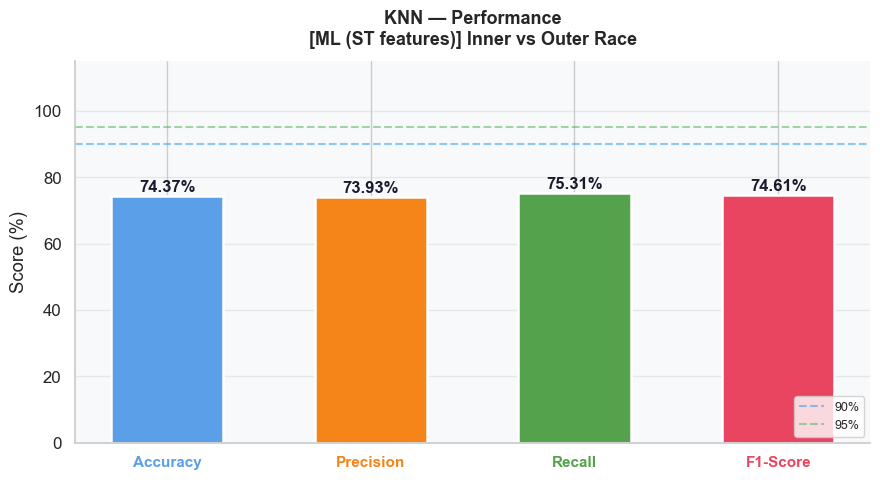

  ✅ Saved: metrics_knn.png


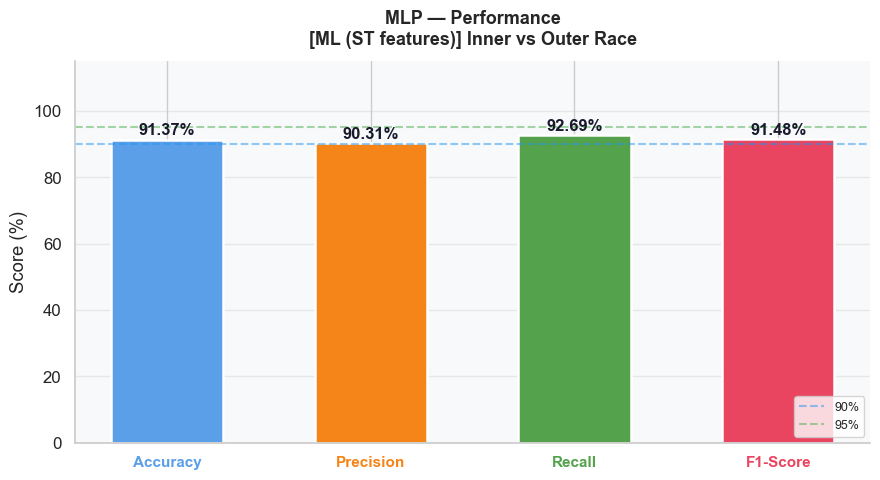

  ✅ Saved: metrics_mlp.png


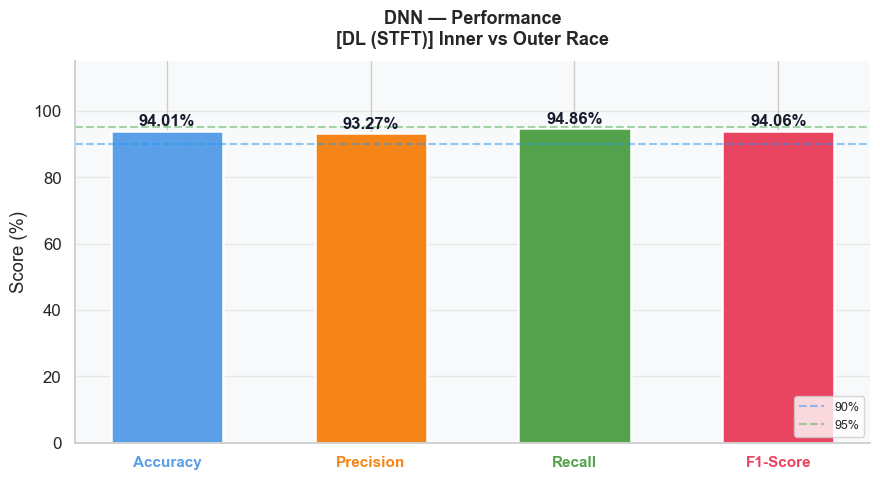

  ✅ Saved: metrics_dnn.png


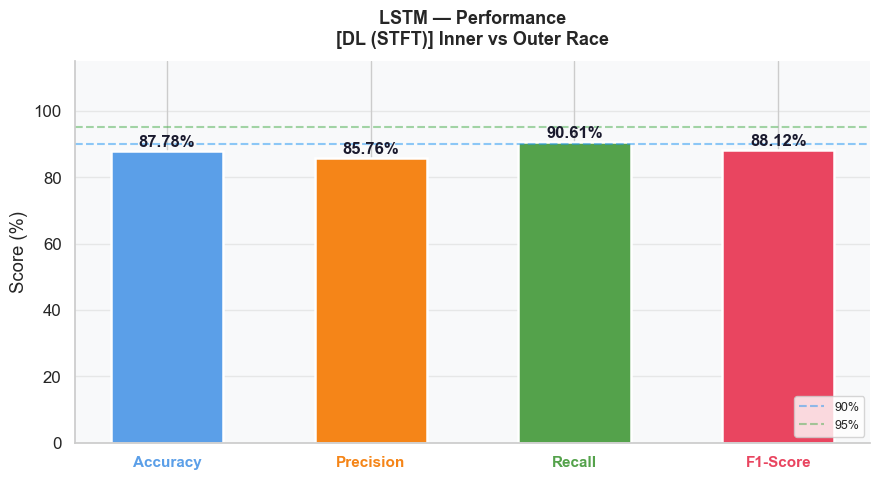

  ✅ Saved: metrics_lstm.png


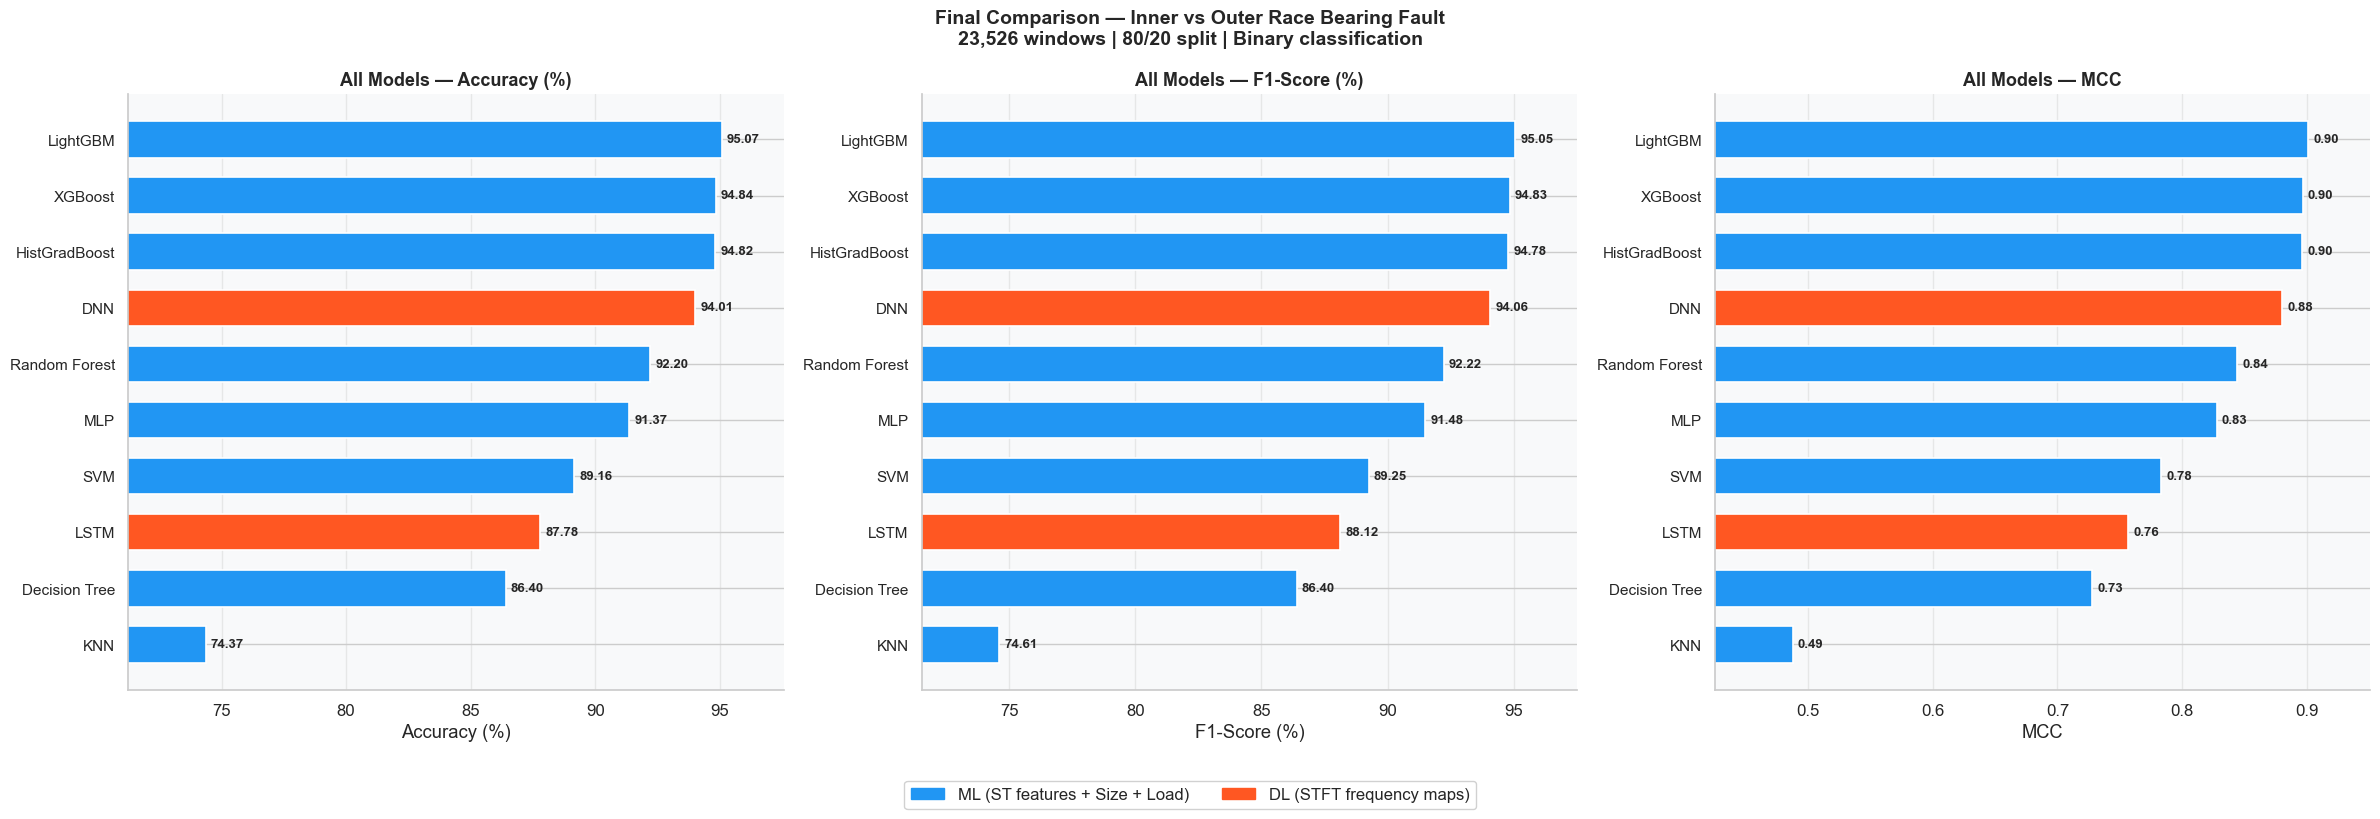

✅ Saved: 08_final_comparison.png

🎉 PROJECT COMPLETE!


In [45]:
all_df = pd.DataFrame(ml_results).T
DL_SET = {'DNN','LSTM'}

print('═'*95)
print('FINAL RESULTS — Inner vs Outer Race Bearing Fault Classification')
print(f'Dataset: {N_WINDOWS:,} windows | 30 ST features + Size + Load | Binary')
print('═'*95)
print(f'  {"Model":<18} {"Type":<14} {"Acc":>8} {"Prec":>8} {"Rec":>8} {"F1":>8} {"MCC":>8} {"AUC":>8}')
print('─'*95)
for mn, row in all_df.sort_values('Accuracy', ascending=False).iterrows():
    flag  = '✅' if row['Accuracy']>=90 else '⚠️'
    mtype = 'DL (STFT)' if mn in DL_SET else 'ML (ST feat)'
    print(f'{flag} {mn:<16} {mtype:<14} '
          f'{row["Accuracy"]:>7}%  {row["Precision"]:>6}%  '
          f'{row["Recall"]:>6}%  {row["F1-Score"]:>6}%  '
          f'{row["MCC"]:>8.4f}  {row["AUC-ROC"]:>6.4f}')
print('─'*95)
print(f'  Best Accuracy : {all_df["Accuracy"].idxmax()} — {all_df["Accuracy"].max()}%')
print(f'  Best AUC-ROC  : {all_df["AUC-ROC"].idxmax()} — {all_df["AUC-ROC"].max()}')
print(f'  Best MCC      : {all_df["MCC"].idxmax()} — {all_df["MCC"].max()}')

all_df.to_csv('final_results.csv')
print('\n✅ Saved: final_results.csv')

# Per-model metric bar charts
COLORS4  = ['#5B9FE8','#F58518','#54A24B','#E94560']
metrics4 = ['Accuracy','Precision','Recall','F1-Score']

for model_name in all_df.index:
    row    = all_df.loc[model_name]
    values = [row['Accuracy'],row['Precision'],row['Recall'],row['F1-Score']]
    mtype  = 'DL (STFT)' if model_name in DL_SET else 'ML (ST features)'

    fig, ax = plt.subplots(figsize=(9,5), facecolor='white')
    ax.set_facecolor('#f8f9fa')
    bars = ax.bar(metrics4, values, color=COLORS4,
                  edgecolor='white', linewidth=1.8, width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.2f}%', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_title(f'{model_name} — Performance\n[{mtype}] Inner vs Outer Race',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Score (%)'); ax.set_ylim(0,115)
    ax.axhline(90, color='#2196F3', linestyle='--', alpha=0.5, lw=1.5, label='90%')
    ax.axhline(95, color='#4CAF50', linestyle='--', alpha=0.5, lw=1.5, label='95%')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for tick, tc in zip(ax.get_xticklabels(), COLORS4):
        tick.set_color(tc); tick.set_fontweight('bold'); tick.set_fontsize(11)
    plt.tight_layout()
    fname = f'metrics_{model_name.lower().replace(" ","_").replace("/","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  ✅ Saved: {fname}')

# Final comparison chart
sorted_df = all_df.sort_values('Accuracy', ascending=True)
bar_clrs  = ['#FF5722' if m in DL_SET else '#2196F3' for m in sorted_df.index]

fig, axes = plt.subplots(1, 3, figsize=(24, 8), facecolor='white')
for ax, metric, label in zip(axes, ['Accuracy','F1-Score','MCC'],
                                    ['Accuracy (%)','F1-Score (%)','MCC']):
    ax.set_facecolor('#f8f9fa')
    vals = sorted_df[metric]
    ax.barh(range(len(vals)), vals, color=bar_clrs, edgecolor='white',
             linewidth=1.2, height=0.65)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(sorted_df.index, fontsize=11)
    ax.set_title(f'All Models — {label}', fontweight='bold', fontsize=13)
    ax.set_xlabel(label)
    ax.grid(True, axis='x', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    mn_v = vals.min(); mx_v = vals.max()
    span = max(mx_v-mn_v, 0.1)
    ax.set_xlim(mn_v-span*0.15, mx_v+span*0.12)
    for i, v in enumerate(vals):
        ax.text(v+span*0.01, i, f'{v:.2f}', va='center', fontsize=9.5, fontweight='bold')

patches = [mpatches.Patch(color='#2196F3', label='ML (ST features + Size + Load)'),
           mpatches.Patch(color='#FF5722', label='DL (STFT frequency maps)')]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=12,
           framealpha=0.9, bbox_to_anchor=(0.5,-0.03))
fig.suptitle(f'Final Comparison — Inner vs Outer Race Bearing Fault\n'
             f'{N_WINDOWS:,} windows | 80/20 split | Binary classification',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig('08_final_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 08_final_comparison.png')
print('\n🎉 PROJECT COMPLETE!')

In [47]:
# Rebuild raw signal val split for CNN (X_B_tr is raw signal (N,400,3))
from sklearn.model_selection import StratifiedShuffleSplit
sss_cnn = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
tr_idx_cnn, val_idx_cnn = next(sss_cnn.split(X_B_tr, y_train))
X_cnn_tr_fit = X_B_tr[tr_idx_cnn]
y_cnn_tr_fit = y_train[tr_idx_cnn]
X_cnn_val    = X_B_tr[val_idx_cnn]
y_cnn_val    = y_train[val_idx_cnn]
print(f'CNN val split rebuilt: train={X_cnn_tr_fit.shape} val={X_cnn_val.shape}')

print('Training 1D CNN on envelope spectrum...')
# rest of your CNN code continues unchanged below...

CNN val split rebuilt: train=(16938, 74) val=(1882, 74)
Training 1D CNN on envelope spectrum...


In [49]:
# Restore X_B_tr to raw signal if it was overwritten
if X_B_tr.shape[1] != 400:
    sc_B_raw = StandardScaler()
    sh = X_win[train_idx].shape
    X_B_tr = sc_B_raw.fit_transform(X_win[train_idx].reshape(-1,3)).reshape(sh)
    sh_te = X_win[test_idx].shape
    X_B_te_raw = sc_B_raw.transform(X_win[test_idx].reshape(-1,3)).reshape(sh_te)
    print(f'X_B_tr restored to raw signal: {X_B_tr.shape}')

X_B_tr restored to raw signal: (18820, 400, 3)


<h3 style='padding:8px 16px;color:white;background:linear-gradient(90deg,#16213e,#0f3460);border-radius:6px;border-left:4px solid #e94560;'>9.1 1D CNN (STFT input — frequency-aware)</h3>

In [52]:
print('Training 1D CNN on engineered features (same as DNN)...')

keras.backend.clear_session()
tf.random.set_seed(42)

# ── Reshape (N, 74) → (N, 74, 1) so CNN treats each feature as a position ──
# This is identical data to what DNN uses (X_dl_tr, X_dl_val, X_B_te)
# CNN learns local feature interactions (e.g. RMS_A next to RMS_B next to RMS_C)
X_cnn_2d_tr  = X_dl_tr.reshape(-1, N_FEATURES, 1)
X_cnn_2d_val = X_dl_val.reshape(-1, N_FEATURES, 1)
X_cnn_2d_te  = X_B_te.reshape(-1, N_FEATURES, 1)

print(f'  Train: {X_cnn_2d_tr.shape}')
print(f'  Val  : {X_cnn_2d_val.shape}')
print(f'  Test : {X_cnn_2d_te.shape}')

inp_cnn = keras.Input(shape=(N_FEATURES, 1))

# Block 1: wide kernel captures groups of related features
x = layers.Conv1D(64, kernel_size=8, padding='same',
                   kernel_regularizer=regularizers.l2(1e-4))(inp_cnn)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(64, kernel_size=8, padding='same',
                   kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(2)(x)          # 74 → 37
x = layers.Dropout(0.25)(x)

# Block 2: narrow kernel captures fine feature interactions
x = layers.Conv1D(128, kernel_size=4, padding='same',
                   kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(128, kernel_size=4, padding='same',
                   kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling1D()(x)  # 37 → 128
x = layers.Dropout(0.3)(x)

# Classifier head — same as DNN
x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.25)(x)

x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)

out_cnn = layers.Dense(1, activation='sigmoid')(x)

cnn = keras.Model(inp_cnn, out_cnn)
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'])
cnn.summary()

DL_CB_CNN = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=8,
        factor=0.5, min_lr=1e-6, verbose=0)
]

t0    = time.time()
cnn_h = cnn.fit(
    X_cnn_2d_tr, y_dl_tr,
    epochs=150,
    batch_size=256,
    validation_data=(X_cnn_2d_val, y_dl_val),
    callbacks=DL_CB_CNN,
    shuffle=True,
    verbose=1)
cnn_t = time.time() - t0

cnn_prob, cnn_pred = predict_dl(cnn, X_cnn_2d_te)
dl_metrics('1D CNN', cnn_pred, cnn_prob, cnn_t)
print(f'  Stopped at epoch : {len(cnn_h.history["accuracy"])}')
print(f'  Best val_acc     : {max(cnn_h.history["val_accuracy"])*100:.2f}%')

Training 1D CNN on engineered features (same as DNN)...
  Train: (16938, 74, 1)
  Val  : (1882, 74, 1)
  Test : (4706, 74, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 74, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 74, 64)              │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 74, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 74, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 74, 64)              │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 74, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 74, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 37, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 37, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 37, 128)             │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 37, 128)             │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 37, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             5

 Total params: 159,105 (621.50 KB)

 Trainable params: 157,953 (617.00 KB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 296ms/step - accuracy: 0.5501 - loss: 0.7273 - val_accuracy: 0.5452 - val_loss: 0.7245 - learning_rate: 0.0010
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 269ms/step - accuracy: 0.5877 - loss: 0.6925 - val_accuracy: 0.5436 - val_loss: 0.7362 - learning_rate: 0.0010
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.7069 - loss: 0.6051 - val_accuracy: 0.5234 - val_loss: 1.0309 - learning_rate: 0.0010
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 269ms/step - accuracy: 0.7996 - loss: 0.4981 - val_accuracy: 0.6121 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - accuracy: 0.8192 - loss: 0.4570 - val_accuracy: 0.5685 - val_loss: 1.0293 - learning_rate: 0.0010
Epoch 6/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.8383 - loss: 0.4198 - val_accuracy: 0.8533 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 7/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 272ms/step - accuracy: 0.8552 - l

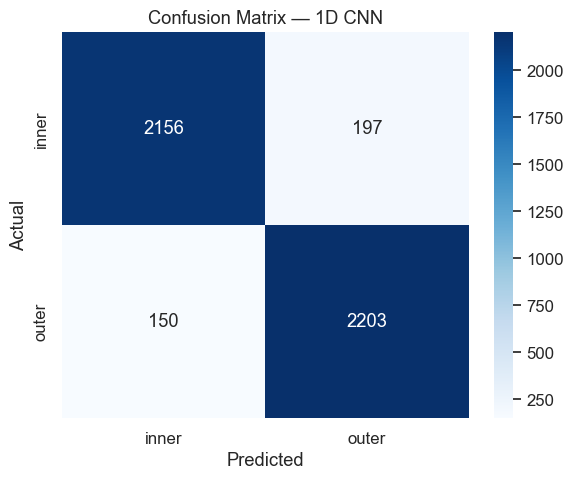

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES,
            yticklabels=CLASSES)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — 1D CNN')
plt.tight_layout()
plt.show()

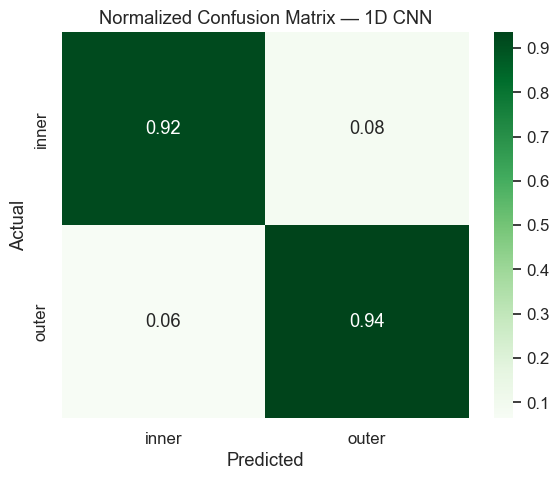

In [54]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASSES,
            yticklabels=CLASSES)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix — 1D CNN')
plt.tight_layout()
plt.show()

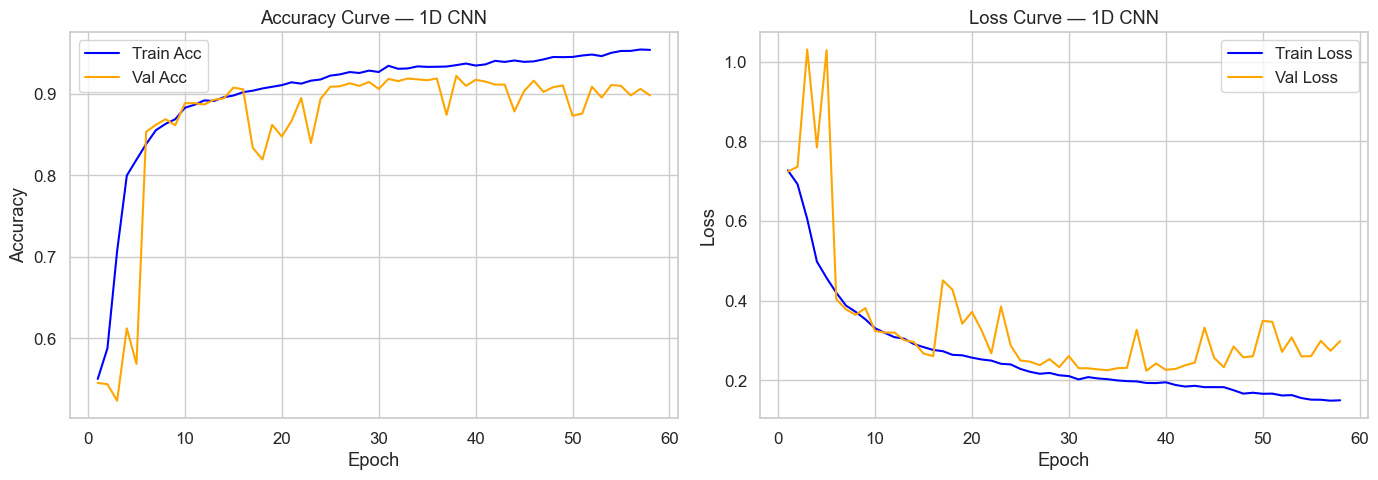

In [55]:
history = cnn_h.history
epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history['accuracy'], label='Train Acc', color='blue')
plt.plot(epochs, history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Accuracy Curve — 1D CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, history['loss'], label='Train Loss', color='blue')
plt.plot(epochs, history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Curve — 1D CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<a id='s11'></a>
<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#16213e);border-radius:8px;margin:16px 0'>
  § 11 · Model Explainability — SHAP &amp; LIME
</h2>
<p>We explain <b>what features drive predictions</b> using two complementary methods:</p>
<ul>
  <li><b>SHAP</b> (SHapley Additive exPlanations) — global feature importance + local instance explanation for tree models and DNN</li>
  <li><b>LIME</b> (Local Interpretable Model-agnostic Explanations) — local explanation for any black-box model (SVM, KNN, DNN)</li>
</ul>
<p>All explanations use the <b>top-40 Fisher features</b> (Dataset A) and the <b>engineered feature matrix</b> (Dataset B for DNN/LSTM).</p>

<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#1a237e,#283593,#c62828);border-radius:8px;border-left:5px solid #ffeb3b;'>🔍 Explainable AI (XAI) — SHAP · LIME</h2>

<p style='padding:10px 18px;background:#E3F2FD;border-radius:8px;border-left:4px solid #1976D2;font-size:14px'>
<b>SHAP</b>: TreeExplainer (DT/RF/XGB/LGBM/HGB) · GradientExplainer (DNN/CNN) · KernelExplainer (SVM/KNN/MLP/LSTM)<br>
<b>LIME</b>: Cylindrical 3D bar charts — all models × all classes (same as Paderborn notebook)
</p>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 1 — Setup: model registries, LIME explainers, colour palette
#
# Variable audit — exact names from training cells:
#   model_Decision_Tree / model_Random_Forest / model_XGBoost /
#   model_LightGBM / model_HGB   → trained on X_A_tr_raw / X_A_te_raw
#   model_SVM / model_KNN / model_MLP → trained on X_A_tr_sc / X_A_te_sc
#   dnn        → X_B_te   (2D: N, N_FEATURES=74)
#   cnn        → X_cnn_2d_te  (3D: N, N_FEATURES, 1)
#   lstm_model → [X_seq_te, X_meta_te]  (dual-input)
#   TOP_FEATS  → top-40 Fisher features (used by all ML models)
# ══════════════════════════════════════════════════════════════════════════
import shap, lime, lime.lime_tabular
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

# ── ML model registry ─────────────────────────────────────────────────────
# Tree models (raw top features)
ml_models_raw = {
    'Decision Tree': model_Decision_Tree,
    'Random Forest': model_Random_Forest,
    'XGBoost':       model_XGBoost,
    'LightGBM':      model_LightGBM,
    'HistGradBoost': model_HGB,
}
# Distance models (scaled top features)
ml_models_sc = {
    'SVM': model_SVM,
    'KNN': model_KNN,
    'MLP': model_MLP,
}
# Combined registry for LIME loop
ml_models = {**ml_models_raw, **ml_models_sc}

# ── Feature lists ─────────────────────────────────────────────────────────
# ALL 8 ML models use TOP_FEATS (top-40 Fisher from FEAT_COLS)
# DT/RF/XGB/LGBM/HGB → X_A_tr_raw (raw) | SVM/KNN/MLP → X_A_tr_sc (scaled)
TOP_FEATURES_XAI = TOP_FEATS     # list of top-40 feature names
K_FEATS          = min(15, len(TOP_FEATURES_XAI))

# ── LIME explainers ───────────────────────────────────────────────────────
# Raw explainer (for DT/RF/XGB/LGBM/HGB)
lime_exp_raw = lime.lime_tabular.LimeTabularExplainer(
    X_A_tr_raw, feature_names=TOP_FEATURES_XAI, class_names=CLASSES,
    mode='classification', discretize_continuous=True, random_state=42)

# Scaled explainer (for SVM/KNN/MLP)
lime_exp_sc = lime.lime_tabular.LimeTabularExplainer(
    X_A_tr_sc, feature_names=TOP_FEATURES_XAI, class_names=CLASSES,
    mode='classification', discretize_continuous=True, random_state=42)

# ── Colour palette ────────────────────────────────────────────────────────
hdr_colors_xai = ['#1976D2', '#F57C00', '#2E7D32', '#7B1FA2', '#C62828'][:N_CLASSES]

print("XAI setup complete")
print(f"  Tree models (raw)   : {list(ml_models_raw.keys())}")
print(f"  Distance models (sc): {list(ml_models_sc.keys())}")
print(f"  DL models           : dnn (2D), cnn (3D: N,74,1), lstm_model (dual-input)")
print(f"  TOP_FEATS (Fisher)  : {len(TOP_FEATURES_XAI)}  |  FEAT_COLS: {len(FEAT_COLS)}")
print(f"  Classes             : {CLASSES}  (binary: {IS_BINARY})")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 2 — SHAP helper functions (Paderborn-identical style)
# ══════════════════════════════════════════════════════════════════════════

def get_shap_values(model_name, model, X_data):
    """Return shap_list: one (n_samples, n_feats) array per class."""
    if model_name == 'XGBoost':
        explainer   = shap.Explainer(model, X_data)
        shap_values = explainer(X_data)
        sv = shap_values.values
        if sv.ndim == 3:
            return [sv[:, :, i] for i in range(N_CLASSES)]
        else:
            # binary: sv is (n, n_feats) — wrap as list
            return [sv]
    else:
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_data)
        if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            return [shap_values[:, :, i] for i in range(N_CLASSES)]
        elif isinstance(shap_values, list):
            return shap_values
        else:
            return [shap_values]


def plot_shap_global(shap_list, model_name, feat_list, palette='viridis'):
    """Global SHAP histogram — Paderborn presentation style."""
    k          = min(K_FEATS, len(feat_list))
    shap_agg   = np.mean(np.abs(np.array(shap_list)), axis=0)
    mean_shap  = np.mean(np.abs(shap_agg), axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1][:k]
    s_feats    = [feat_list[i] for i in sorted_idx]
    s_vals     = mean_shap[sorted_idx]

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#FAFAFA')
    colors = sns.color_palette(palette, len(s_feats))
    bars   = ax.barh(s_feats[::-1], s_vals[::-1],
                     color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, s_vals[::-1]):
        ax.text(bar.get_width() + mean_shap.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value| — Global Feature Importance', fontsize=11)
    ax.set_title(f'SHAP Global Histogram — {model_name}',
                 fontsize=13, fontweight='bold', color='#1a237e')
    ax.set_xlim(0, mean_shap.max()*1.22 if mean_shap.max() > 0 else 1)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fname = f'shap_global_{model_name.replace(" ","_").replace("-","_")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show(); print(f'  Saved: {fname}')


def plot_shap_perclass(shap_list, model_name, feat_list, top_k=12):
    """Per-class SHAP histograms — Paderborn presentation style."""
    n_cls = len(shap_list)
    fig, axes = plt.subplots(1, n_cls, figsize=(7*n_cls, 6))
    if n_cls == 1: axes = [axes]
    fig.patch.set_facecolor('#FAFAFA')
    for cls_id, ax in enumerate(axes):
        mean_abs = np.mean(np.abs(shap_list[cls_id]), axis=0)
        si       = np.argsort(mean_abs)[-min(top_k, len(feat_list)):]
        bc       = sns.color_palette('Set2', len(si))
        bars     = ax.barh([feat_list[i] for i in si],
                           mean_abs[si], color=bc, edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, mean_abs[si]):
            mx = mean_abs[si].max()
            ax.text(bar.get_width() + mx*0.015,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')
        lbl = CLASSES[cls_id] if cls_id < len(CLASSES) else f'Class {cls_id}'
        ax.set_title(f'Class: {lbl}', fontweight='bold', fontsize=12,
                     color=hdr_colors_xai[cls_id % len(hdr_colors_xai)])
        ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
        mx = mean_abs[si].max() if mean_abs[si].max() > 0 else 1
        ax.set_xlim(0, mx*1.22)
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.suptitle(f'SHAP Per-Class Histogram — {model_name}',
                 fontsize=13, fontweight='bold', color='#1a237e', y=1.02)
    plt.tight_layout()
    fname = f'shap_perclass_{model_name.replace(" ","_").replace("-","_")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show(); print(f'  Saved: {fname}')

print("SHAP helpers ready: get_shap_values, plot_shap_global, plot_shap_perclass")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 3 — SHAP TreeExplainer:
#   Decision Tree, Random Forest, XGBoost, LightGBM, HistGradBoost
#   All trained on X_A_tr_raw → SHAP on X_A_te_raw
# ══════════════════════════════════════════════════════════════════════════

tree_model_names = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'HistGradBoost']
tree_model_objs  = [model_Decision_Tree, model_Random_Forest,
                    model_XGBoost, model_LightGBM, model_HGB]

for model_name, model_obj in zip(tree_model_names, tree_model_objs):
    print("=" * 55)
    print(f"Computing SHAP TreeExplainer: {model_name}")
    print("=" * 55)
    try:
        shap_list = get_shap_values(model_name, model_obj, X_A_te_raw)
        print(f"  Classes    : {len(shap_list)}")
        print(f"  Shape/class: {shap_list[0].shape}")
        plot_shap_global(shap_list, model_name, TOP_FEATURES_XAI, palette='viridis')
        plot_shap_perclass(shap_list, model_name, TOP_FEATURES_XAI)
        print(f"  {model_name} DONE")
    except Exception as e:
        print(f"  ERROR for {model_name}: {e}")
    print()

print("=" * 55)
print("ALL TREE MODEL SHAP COMPLETE")
print("=" * 55)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 4 — SHAP GradientExplainer: DNN and CNN
#              KernelExplainer: LSTM (dual-input — cannot use GradientExplainer)
#
#   dnn        : input X_B_te        (2D: N, N_FEATURES=74)
#   cnn        : input X_cnn_2d_te   (3D: N, N_FEATURES, 1)
#   lstm_model : dual-input [X_seq_te, X_meta_te] → KernelExplainer
# ══════════════════════════════════════════════════════════════════════════

# ── Background and test subsets ───────────────────────────────────────────
bg_idx = np.random.choice(len(X_B_tr), min(100, len(X_B_tr)), replace=False)
te_idx = np.random.choice(len(X_B_te), min(200, len(X_B_te)), replace=False)

bg_2d = X_dl_tr[bg_idx[:min(100,len(X_dl_tr))]]    # (100, 74) for DNN
te_2d = X_B_te[te_idx]                              # (200, 74) for DNN test

bg_3d = bg_2d.reshape(-1, N_FEATURES, 1)            # (100, 74, 1) for CNN
te_3d = te_2d.reshape(-1, N_FEATURES, 1)            # (200, 74, 1) for CNN

DL_FEAT_NAMES = FEAT_COLS   # 74 engineered feature names
DL_K          = min(15, N_FEATURES)

# ── DNN: GradientExplainer ────────────────────────────────────────────────
print("=" * 55)
print("SHAP GradientExplainer: DNN  (2D input: N, 74)")
print("=" * 55)
try:
    exp_dnn   = shap.GradientExplainer(dnn, bg_2d)
    sv_dnn    = exp_dnn.shap_values(te_2d)

    if isinstance(sv_dnn, list):
        sl_dnn = [np.array(sv).reshape(np.array(sv).shape[0], -1) for sv in sv_dnn]
    else:
        sv_arr = np.array(sv_dnn).reshape(np.array(sv_dnn).shape[0], -1)
        sl_dnn = [sv_arr]

    print(f"  Classes    : {len(sl_dnn)}")
    print(f"  Shape/class: {sl_dnn[0].shape}")
    plot_shap_global(sl_dnn, 'DNN', DL_FEAT_NAMES, palette='magma')
    plot_shap_perclass(sl_dnn, 'DNN', DL_FEAT_NAMES)

    # Beeswarm per class
    for cls_id in range(len(sl_dnn)):
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sl_dnn[cls_id], te_2d,
                          feature_names=DL_FEAT_NAMES,
                          max_display=15, plot_type='dot', show=False)
        lbl = CLASSES[cls_id] if cls_id < len(CLASSES) else f'Class {cls_id}'
        plt.title(f'SHAP Beeswarm — DNN — Class: {lbl}',
                  fontsize=12, fontweight='bold', color='#1a237e')
        plt.tight_layout()
        fname = f'shap_beeswarm_DNN_cls{cls_id}.png'
        plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
        print(f'  Saved: {fname}')
    print("  DNN DONE")

except Exception as e:
    print(f"  GradientExplainer failed for DNN: {e}")
    print("  Falling back to KernelExplainer for DNN...")
    try:
        pred_fn_dnn = lambda X: dnn.predict(X, verbose=0)
        exp_k_dnn   = shap.KernelExplainer(pred_fn_dnn, bg_2d[:30])
        sv_k        = exp_k_dnn.shap_values(te_2d[:20], nsamples=100)
        sl_k        = sv_k if isinstance(sv_k, list) else [sv_k]
        plot_shap_global(sl_k, 'DNN (KernelFallback)', DL_FEAT_NAMES, palette='magma')
        plot_shap_perclass(sl_k, 'DNN (KernelFallback)', DL_FEAT_NAMES)
    except Exception as e2:
        print(f"  DNN fallback also failed: {e2}")
print()

# ── CNN: GradientExplainer ────────────────────────────────────────────────
print("=" * 55)
print("SHAP GradientExplainer: CNN  (3D input: N, 74, 1)")
print("=" * 55)
try:
    exp_cnn   = shap.GradientExplainer(cnn, bg_3d)
    sv_cnn    = exp_cnn.shap_values(te_3d)

    if isinstance(sv_cnn, list):
        sl_cnn = [np.array(sv).reshape(np.array(sv).shape[0], -1) for sv in sv_cnn]
    else:
        sv_arr = np.array(sv_cnn).reshape(np.array(sv_cnn).shape[0], -1)
        sl_cnn = [sv_arr]

    print(f"  Classes    : {len(sl_cnn)}")
    print(f"  Shape/class: {sl_cnn[0].shape}")
    plot_shap_global(sl_cnn, '1D CNN', DL_FEAT_NAMES, palette='magma')
    plot_shap_perclass(sl_cnn, '1D CNN', DL_FEAT_NAMES)

    # Beeswarm per class
    for cls_id in range(len(sl_cnn)):
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sl_cnn[cls_id], te_2d,
                          feature_names=DL_FEAT_NAMES,
                          max_display=15, plot_type='dot', show=False)
        lbl = CLASSES[cls_id] if cls_id < len(CLASSES) else f'Class {cls_id}'
        plt.title(f'SHAP Beeswarm — 1D CNN — Class: {lbl}',
                  fontsize=12, fontweight='bold', color='#1a237e')
        plt.tight_layout()
        fname = f'shap_beeswarm_1D_CNN_cls{cls_id}.png'
        plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
        print(f'  Saved: {fname}')
    print("  1D CNN DONE")

except Exception as e:
    print(f"  GradientExplainer failed for CNN: {e}")
    print("  Falling back to KernelExplainer for CNN...")
    try:
        pred_fn_cnn = lambda X: cnn.predict(X.reshape(-1, N_FEATURES, 1), verbose=0)
        exp_k_cnn   = shap.KernelExplainer(pred_fn_cnn, bg_2d[:30])
        sv_k        = exp_k_cnn.shap_values(te_2d[:20], nsamples=100)
        sl_k        = sv_k if isinstance(sv_k, list) else [sv_k]
        plot_shap_global(sl_k, '1D CNN (KernelFallback)', DL_FEAT_NAMES, palette='magma')
        plot_shap_perclass(sl_k, '1D CNN (KernelFallback)', DL_FEAT_NAMES)
    except Exception as e2:
        print(f"  CNN fallback also failed: {e2}")
print()

# ── LSTM: KernelExplainer (dual-input model — GradientExplainer not applicable)
print("=" * 55)
print("SHAP KernelExplainer: LSTM  (dual-input: seq + meta)")
print("=" * 55)
try:
    # LSTM needs [X_seq, X_meta] — we wrap both into a single flat array for KernelExplainer
    # then split inside pred_fn
    N_SEQ  = N_FEAT_PER_CH * N_CH    # 72 sequence features
    N_META = 2                        # Size, Load

    bg_lstm_2d = X_dl_tr[:min(50, len(X_dl_tr))]   # (50, 74)
    te_lstm_2d = X_B_te[:min(30, len(X_B_te))]     # (30, 74)

    def pred_fn_lstm(X_flat):
        """Split flat (N, 74) → [seq (N,24,3), meta (N,2)] then predict."""
        X_sig  = X_flat[:, :N_SEQ].reshape(-1, N_FEAT_PER_CH, N_CH)
        X_meta = X_flat[:, N_SEQ:]
        return lstm_model.predict([X_sig, X_meta], verbose=0)

    exp_lstm   = shap.KernelExplainer(pred_fn_lstm, bg_lstm_2d)
    sv_lstm    = exp_lstm.shap_values(te_lstm_2d, nsamples=100)
    sl_lstm    = sv_lstm if isinstance(sv_lstm, list) else [sv_lstm]

    print(f"  Classes    : {len(sl_lstm)}")
    print(f"  Shape/class: {sl_lstm[0].shape}")
    plot_shap_global(sl_lstm, 'LSTM', DL_FEAT_NAMES, palette='magma')
    plot_shap_perclass(sl_lstm, 'LSTM', DL_FEAT_NAMES)
    print("  LSTM DONE")

except Exception as e:
    print(f"  KernelExplainer failed for LSTM: {e}")
print()
print("=" * 55)
print("ALL DL MODEL SHAP COMPLETE")
print("=" * 55)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 5 — SHAP KernelExplainer: SVM, KNN, MLP
#   All trained on X_A_tr_sc / X_A_te_sc (top-40 Fisher, scaled)
# ══════════════════════════════════════════════════════════════════════════

# Background (100) and test (50) — KernelExplainer is slow
bg_k = X_A_tr_sc[np.random.choice(len(X_A_tr_sc), min(100, len(X_A_tr_sc)), replace=False)]
te_k = X_A_te_sc[np.random.choice(len(X_A_te_sc), min(50,  len(X_A_te_sc)), replace=False)]

kernel_cfg = {
    'SVM': lambda X: ml_models_sc['SVM'].predict_proba(X),
    'KNN': lambda X: ml_models_sc['KNN'].predict_proba(X),
    'MLP': lambda X: ml_models_sc['MLP'].predict_proba(X),
}

for model_name, pred_fn in kernel_cfg.items():
    print("=" * 55)
    print(f"Computing SHAP KernelExplainer: {model_name}  (may take 2–5 min)")
    print("=" * 55)
    try:
        explainer   = shap.KernelExplainer(pred_fn, bg_k)
        shap_values = explainer.shap_values(te_k, nsamples=200)

        if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_list = [shap_values[:, :, i] for i in range(N_CLASSES)]
        elif isinstance(shap_values, list):
            shap_list = shap_values
        else:
            shap_list = [shap_values]

        print(f"  Shape per class: {shap_list[0].shape}")
        plot_shap_global(shap_list,  model_name, TOP_FEATURES_XAI, palette='plasma')
        plot_shap_perclass(shap_list, model_name, TOP_FEATURES_XAI)
        print(f"  {model_name} DONE")
    except Exception as e:
        print(f"  ERROR for {model_name}: {e}")
    print()

print("Kernel model SHAP done")


<h2 style='padding:10px 18px;color:white;background:linear-gradient(90deg,#C62828,#1a237e);border-radius:8px'>🧊 LIME — Cylindrical 3D Bar Charts</h2>

<p style='padding:8px 16px;background:#FFF3E0;border-radius:8px;border-left:4px solid #F57C00;font-size:13px'>
Cylindrical 3D LIME bars — all models × all classes (identical to Paderborn § 13).
</p>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 6 — Cylindrical 3D LIME bar chart function (Paderborn § 13 style)
# ══════════════════════════════════════════════════════════════════════════

def plot_lime_cylinder(feats, weights, pred_label, model_name,
                       class_name, num_features=8, save_path=None):
    feats   = feats[:num_features]
    weights = weights[:num_features]
    POS_COLORS = [('#1E88E5','#64B5F6','#0D47A1'),
                  ('#00ACC1','#4DD0E1','#006064'),
                  ('#43A047','#81C784','#1B5E20')]
    NEG_FACE, NEG_LITE, NEG_DARK = '#E53935', '#EF9A9A', '#B71C1C'
    BAR_W, DEPTH, ELIP_H = 0.55, 0.20, 0.35
    max_h = max(abs(w) for w in weights) if weights else 0.01

    fig, ax = plt.subplots(figsize=(max(12, num_features*1.6), 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#FAFAFA')

    for i, (feat, w) in enumerate(zip(feats, weights)):
        x = float(i); h = abs(w); pos = (w >= 0)
        fc, lc, dc = (POS_COLORS[i % len(POS_COLORS)] if pos
                      else (NEG_FACE, NEG_LITE, NEG_DARK))
        y_bot = 0.0 if pos else -h
        y_top = h   if pos else  0.0

        ax.add_patch(plt.Polygon(
            [[x+BAR_W/2,y_bot],[x+BAR_W/2+DEPTH,y_bot-DEPTH],
             [x+BAR_W/2+DEPTH,y_top-DEPTH],[x+BAR_W/2,y_top]],
            facecolor=dc, edgecolor='none', alpha=0.75, zorder=2))
        ax.add_patch(plt.Polygon(
            [[x-BAR_W/2,y_bot],[x+BAR_W/2,y_bot],
             [x+BAR_W/2+DEPTH,y_bot-DEPTH],[x-BAR_W/2+DEPTH,y_bot-DEPTH]],
            facecolor=dc, edgecolor='none', alpha=0.5, zorder=2))
        ax.add_patch(plt.Rectangle((x-BAR_W/2,y_bot), BAR_W, h,
            facecolor=fc, edgecolor='none', zorder=3))
        ax.add_patch(plt.Rectangle((x-BAR_W/2,y_bot), BAR_W*0.18, h,
            facecolor=lc, edgecolor='none', alpha=0.65, zorder=5))
        ax.add_patch(Ellipse((x+DEPTH/2, y_bot-DEPTH/2),
            width=BAR_W, height=BAR_W*ELIP_H,
            facecolor=dc, edgecolor='none', alpha=0.65, zorder=2))
        ax.add_patch(Ellipse((x+DEPTH/2, y_top-DEPTH/2),
            width=BAR_W, height=BAR_W*ELIP_H,
            facecolor=lc, edgecolor='white', linewidth=1.4, zorder=4))

        sign_str = f'+{w:.4f}' if w > 0 else f'{w:.4f}'
        ax.text(x+DEPTH/2, y_top+max_h*0.08, sign_str,
                ha='center', va='bottom', fontsize=9.5,
                fontweight='bold', color='#212121', zorder=6)
        short = feat if len(feat) <= 18 else feat[:16]+'..'
        ax.text(x+DEPTH/2, -max_h*1.08, short,
                ha='center', va='top', fontsize=8,
                color='#1565C0' if pos else '#C62828',
                style='italic', zorder=6, rotation=22, rotation_mode='anchor')

    ax.axhline(0, color='#9E9E9E', linewidth=1.5, zorder=1)
    for yg in np.linspace(-max_h, max_h, 6):
        ax.axhline(yg, color='#E0E0E0', linewidth=0.7, zorder=0)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xlim(-0.7, len(feats)-0.2+DEPTH)
    ax.set_ylim(-max_h*1.7, max_h*1.3)
    ax.legend(handles=[
        mpatches.Patch(facecolor='#1E88E5', edgecolor='#0D47A1',
                       linewidth=1.5, label='Supports (+)'),
        mpatches.Patch(facecolor='#E53935', edgecolor='#B71C1C',
                       linewidth=1.5, label='Against  (-)'),
    ], loc='upper right', fontsize=10, frameon=True, framealpha=0.95, facecolor='white')
    ax.text(0.01, 0.99, f'Predicted: {pred_label}',
            transform=ax.transAxes, fontsize=10, va='top', color='#1a237e',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor='#1565C0'))
    ax.set_title(
        f'LIME — Predicted: {pred_label} | {model_name} | True: {class_name} | Top {num_features} Features',
        fontsize=12, fontweight='bold', pad=14, color='#1a237e')
    plt.tight_layout(pad=2.2)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close()

print("Cylindrical LIME function ready")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 7 — LIME Cylindrical: ALL 8 ML models × ALL classes
#   Tree models (DT/RF/XGB/LGBM/HGB) → lime_exp_raw, X_A_te_raw
#   Distance models (SVM/KNN/MLP)     → lime_exp_sc,  X_A_te_sc
# ══════════════════════════════════════════════════════════════════════════

models_lime_ml = [
    # (name, predict_fn, lime_explainer, X_test_local, feat_names)
    ('Decision Tree', lambda X: model_Decision_Tree.predict_proba(X), lime_exp_raw, X_A_te_raw, TOP_FEATURES_XAI),
    ('Random Forest', lambda X: model_Random_Forest.predict_proba(X), lime_exp_raw, X_A_te_raw, TOP_FEATURES_XAI),
    ('XGBoost',       lambda X: model_XGBoost.predict_proba(X),       lime_exp_raw, X_A_te_raw, TOP_FEATURES_XAI),
    ('LightGBM',      lambda X: model_LightGBM.predict_proba(X),      lime_exp_raw, X_A_te_raw, TOP_FEATURES_XAI),
    ('HistGradBoost', lambda X: model_HGB.predict_proba(X),           lime_exp_raw, X_A_te_raw, TOP_FEATURES_XAI),
    ('SVM',           lambda X: model_SVM.predict_proba(X),           lime_exp_sc,  X_A_te_sc,  TOP_FEATURES_XAI),
    ('KNN',           lambda X: model_KNN.predict_proba(X),           lime_exp_sc,  X_A_te_sc,  TOP_FEATURES_XAI),
    ('MLP',           lambda X: model_MLP.predict_proba(X),           lime_exp_sc,  X_A_te_sc,  TOP_FEATURES_XAI),
]

for cls_id in sorted(np.unique(y_test)):
    correct = np.where(y_test == cls_id)[0]
    if len(correct) == 0:
        print(f"  No test samples for class {CLASSES[cls_id]}, skipping")
        continue
    idx = correct[0]
    print()
    print("=" * 60)
    print(f"  Class: {CLASSES[cls_id]}  |  Sample Index: {idx}")
    print("=" * 60)

    for mname, pred_fn, exp_obj, Xte_local, feat_list in models_lime_ml:
        instance = Xte_local[idx]
        try:
            exp       = exp_obj.explain_instance(instance, pred_fn,
                            num_features=8, num_samples=400, top_labels=1)
            label     = exp.available_labels()[0]
            feat_vals = exp.as_list(label=label)
            feats     = [fv[0] for fv in feat_vals]
            weights   = [fv[1] for fv in feat_vals]
            prob      = pred_fn(instance.reshape(1, -1))[0]
            pred_lbl  = CLASSES[int(np.argmax(prob))]
            print(f"  {mname:<20} -> {pred_lbl}")
            fname = f'lime_cyl_{CLASSES[cls_id]}_{mname.replace(" ","_")}.png'
            plot_lime_cylinder(feats, weights, pred_lbl, mname,
                               CLASSES[cls_id], num_features=8, save_path=fname)
        except Exception as e:
            print(f"  {mname} error: {e}")

print()
print("ALL ML MODEL LIME COMPLETE")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 8 — LIME Cylindrical: DNN, 1D CNN, LSTM
#
#   DNN        : X_B_te (2D: N,74) → predict directly
#   CNN (cnn)  : X_B_te → reshape (N,74,1) inside predict_fn
#   LSTM       : X_B_te → split into [seq(N,24,3), meta(N,2)] inside predict_fn
#
#   All use lime_exp_dl on X_B_tr (2D: N,74 — all engineered features)
# ══════════════════════════════════════════════════════════════════════════

# Single LIME explainer for all DL — features are full 74-dim engineered vector
lime_exp_dl = lime.lime_tabular.LimeTabularExplainer(
    X_B_tr, feature_names=FEAT_COLS, class_names=CLASSES,
    mode='classification', discretize_continuous=True, random_state=42)

# ── Predict functions wrapping each DL model ──────────────────────────────
def pred_fn_dnn_lime(X):
    """DNN: (N,74) → prob array (N,2) compatible with LIME."""
    p = dnn.predict(X, verbose=0).flatten()
    return np.column_stack([1-p, p])

def pred_fn_cnn_lime(X):
    """CNN: flatten (N,74) → reshape (N,74,1) → predict."""
    p = cnn.predict(X.reshape(-1, N_FEATURES, 1), verbose=0).flatten()
    return np.column_stack([1-p, p])

def pred_fn_lstm_lime(X):
    """LSTM dual-input: flat (N,74) → split [seq(N,24,3), meta(N,2)]."""
    X_sig  = X[:, :N_FEAT_PER_CH * N_CH].reshape(-1, N_FEAT_PER_CH, N_CH)
    X_meta = X[:, N_FEAT_PER_CH * N_CH:]
    p = lstm_model.predict([X_sig, X_meta], verbose=0).flatten()
    return np.column_stack([1-p, p])

models_lime_dl = [
    ('DNN',    pred_fn_dnn_lime,  X_B_te),
    ('1D CNN', pred_fn_cnn_lime,  X_B_te),
    ('LSTM',   pred_fn_lstm_lime, X_B_te),
]

for cls_id in sorted(np.unique(y_test)):
    correct = np.where(y_test == cls_id)[0]
    if len(correct) == 0:
        print(f"  No test samples for class {CLASSES[cls_id]}, skipping")
        continue
    idx = correct[0]
    print()
    print("=" * 60)
    print(f"  Class: {CLASSES[cls_id]}  |  Sample Index: {idx}  (DL models)")
    print("=" * 60)

    for mname, pred_fn, Xte_local in models_lime_dl:
        instance = Xte_local[idx]
        try:
            exp       = lime_exp_dl.explain_instance(instance, pred_fn,
                            num_features=8, num_samples=400, top_labels=1)
            label     = exp.available_labels()[0]
            feat_vals = exp.as_list(label=label)
            feats     = [fv[0] for fv in feat_vals]
            weights   = [fv[1] for fv in feat_vals]
            prob      = pred_fn(instance.reshape(1, -1))[0]
            pred_lbl  = CLASSES[int(np.argmax(prob))]
            print(f"  {mname:<20} -> {pred_lbl}")
            fname = f'lime_cyl_{CLASSES[cls_id]}_{mname.replace(" ","_").replace("-","_")}.png'
            plot_lime_cylinder(feats, weights, pred_lbl, mname,
                               CLASSES[cls_id], num_features=8, save_path=fname)
        except Exception as e:
            print(f"  {mname} error: {e}")

print()
print("ALL DL MODEL LIME COMPLETE")
print("XAI SECTION FULLY DONE — SHAP + LIME")


In [60]:
!py -m pip install --upgrade pip

     ---------------------------------------- 1.8/1.8 MB 403.4 kB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 22.3.1
    Uninstalling pip-22.3.1:
      Successfully uninstalled pip-22.3.1


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [62]:
!py -m pip install lime

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.8 MB 10.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.8 MB 8.0 MB/s eta 0:00:02
   ------------- -------------------------- 4.5/12.8 MB 7.3 MB/s eta 0:00:02
   ----------------- ---------------------- 5.5/12.8 MB 6.9 MB/s eta 0:00:02
   ----------------------- ---------------- 7.6/12.8 MB 7.2 MB/s eta 0:00:01
   ------------------------ --------------- 7.9/12.8 MB 7.4 MB/s eta 0:00:01
   --------------------------- ------------ 8.7/12.8 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.8 MB 6.